In [1]:
# 修改为30类子集任务， 验证模型结构设计

In [2]:
# 导入必要的库
import os
import time
from fastkan import *
from fastkan import FastKAN
import random
import json
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpts
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, cohen_kappa_score, accuracy_score
from sklearn.metrics import precision_score,precision_recall_curve, auc, recall_score, f1_score, accuracy_score, confusion_matrix

from sklearn.preprocessing import minmax_scale
import pandas as pd
from scipy.io import loadmat
from tqdm.notebook import tqdm
from IPython import display
import h5py
import copy
import sys
import glob
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [3]:
# 将102类改为30类子集
RANDOM_SEED = 666
MODEL_NAME = 'BrainVoxel_30Class'  # 30分类模型
DATASET = 'BrainVoxel_Subset'  
NUM_CLASS = 30  # 30分类
TARGET_SAMPLES = 10000  # 每个类别的目标样本数

# 子集选择
SELECTED_CLASSES = None  # 将在代码中动态选择

# 其它参数保持不变
APPLY_PCA = False
N_PCA = 0
NORM = True
EPOCH = 100
VAL_EPOCH = 3
LR = 1e-3
WEIGHT_DECAY = 5e-5
BATCH_SIZE = 256
HIDDEN_LAYERS = [256, 256, 256]
USE_LR_SCHEDULER = True
LR_SCHEDULER_TYPE = 'multistep'
LR_MILESTONES = [15 , 35, 50, 75]
LR_GAMMA = 0.6
DEVICE = 0
BALANCE_TRAIN = True
MAX_MULTIPLIER = 3
AUGMENTATION_METHOD = 'simple_copy'
LAMBDA_L1 = 0.00001
LAMBDA_ENTROPY = 0.1
USE_KAN_REGULARIZATION = True
FEATURE_DIM = 341
FIXED_GRID = 12
CHECK_POINT = None
SAVE_PATH = f"./Results/{MODEL_NAME}/{DATASET}"
if not os.path.isdir(SAVE_PATH):
    os.makedirs(SAVE_PATH)

In [4]:
## 设置随机数种子，确保实验结果可复现

# 为Python的random模块设置随机种子
random.seed(RANDOM_SEED)

# 为PyTorch的CPU操作设置随机种子
torch.manual_seed(RANDOM_SEED)

# 为当前GPU设置随机种子
torch.cuda.manual_seed(RANDOM_SEED)

# 为所有可用GPU设置相同的随机种子
torch.cuda.manual_seed_all(RANDOM_SEED)

# 为NumPy库设置随机种子
np.random.seed(RANDOM_SEED)

# 禁用CuDNN的非确定性算法
torch.backends.cudnn.deterministic = True

# 禁用CuDNN的自动优化选择
torch.backends.cudnn.benchmark = False

In [5]:
def select_subset_classes(data_dirs, num_classes=30, min_samples=100):
    """
    从数据集中选择指定数量的类别作为子集
    选择策略：优先选择样本数量较多的类别，确保每个类别至少有min_samples个样本
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        num_classes: 需要选择的类别数量
        min_samples: 每个类别至少需要的样本数
        
    返回:
        selected_classes: 选择的类别列表
    """
    print(f"正在选择{num_classes}个类别作为子集...")
    
    # 创建数据采样器
    train_sampler = BrainVoxelSampler(data_dirs['train_dir'])
    test_sampler = BrainVoxelSampler(data_dirs['test_dir'])
    val_sampler = BrainVoxelSampler(data_dirs['val_dir'])
    
    # 收集所有有效标签
    valid_labels = sorted(list(set(
        train_sampler.valid_labels + 
        test_sampler.valid_labels + 
        val_sampler.valid_labels
    )))
    
    # 统计每个类别的样本数
    class_stats = {}
    for label_id in tqdm(valid_labels, desc="统计类别样本数"):
        train_count = 0
        test_count = 0
        val_count = 0
        
        # 训练集
        train_file = train_sampler.get_file_path(label_id)
        if train_file and os.path.exists(train_file):
            train_samples = np.load(train_file)
            train_count = len(train_samples)
        
        # 测试集
        test_file = test_sampler.get_file_path(label_id)
        if test_file and os.path.exists(test_file):
            test_samples = np.load(test_file)
            test_count = len(test_samples)
            
        # 验证集
        val_file = val_sampler.get_file_path(label_id)
        if val_file and os.path.exists(val_file):
            val_samples = np.load(val_file)
            val_count = len(val_samples)
        
        total_count = train_count + test_count + val_count
        class_stats[label_id] = {
            'train': train_count,
            'test': test_count,
            'val': val_count,
            'total': total_count
        }
    
    # 根据训练集样本数量降序排序，并满足最低样本数要求
    filtered_classes = [cls for cls, stats in class_stats.items() 
                      if stats['train'] >= min_samples and 
                         stats['test'] >= min_samples//10 and
                         stats['val'] >= min_samples//10]
    
    # 按训练集样本数降序排序
    sorted_classes = sorted(filtered_classes, 
                           key=lambda x: class_stats[x]['train'], 
                           reverse=True)
    
    # 选择前num_classes个类别
    selected_classes = sorted_classes[:num_classes]
    
    # 检查是否有足够的类别
    if len(selected_classes) < num_classes:
        print(f"警告：只找到{len(selected_classes)}个满足条件的类别，少于请求的{num_classes}个")
    
    # 打印选择的类别信息
    print(f"\n选择了以下{len(selected_classes)}个类别作为子集:")
    print("-" * 80)
    print(f"{'类别ID':<10}{'训练集样本数':<15}{'测试集样本数':<15}{'验证集样本数':<15}{'总样本数':<15}")
    print("-" * 80)
    for cls in selected_classes:
        stats = class_stats[cls]
        print(f"{cls:<10}{stats['train']:<15}{stats['test']:<15}{stats['val']:<15}{stats['total']:<15}")
    
    return selected_classes

In [6]:
# 灵活的采样器和数据管理类
class BrainVoxelSampler:
    """脑体素数据采样器，提供多种采样策略"""
    
    def __init__(self, data_dir):
        """
        初始化采样器
        
        参数:
            data_dir: 数据集目录
        """
        self.data_dir = data_dir
        self.label_info = self._load_label_index()
        self.valid_labels = [label for label, info in self.label_info.items() if info['count'] > 0]
    
    def _load_label_index(self):
        """加载标签索引文件"""
        index_file = os.path.join(self.data_dir, "label_index.txt")
        label_info = {}
        
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        
        return label_info
    
    def get_file_path(self, label_id):
        """获取指定标签的文件路径"""
        if label_id not in self.label_info:
            return None
        
        filename = self.label_info[label_id]['filename']
        if not filename:
            return None
            
        return os.path.join(self.data_dir, filename)

# 添加在第4个代码单元格后面（BrainVoxelSampler类后面）

class DataAugmenter:
    """数据增强器基类，定义接口"""
    def augment(self, samples, target_count):
        """增强样本至目标数量
        
        参数:
            samples: 原始样本数据，形状为(n_samples, feature_dim)
            target_count: 目标样本数量
            
        返回:
            augmented_samples: 增强后的样本数据
        """
        raise NotImplementedError("子类需要实现augment方法")

class SimpleMultiplierAugmenter(DataAugmenter):
    """简单复制增强器"""
    def __init__(self, max_multiplier=3):
        """初始化
        
        参数:
            max_multiplier: 最大复制倍数，默认为3
        """
        self.max_multiplier = max_multiplier
        
    def augment(self, samples, target_count):
        """通过简单复制增强样本
        
        参数:
            samples: 原始样本数据，形状为(n_samples, feature_dim)
            target_count: 目标样本数量
            
        返回:
            augmented_samples: 增强后的样本数据
        """
        current_count = len(samples)
        
        # 如果当前样本数已经达到或超过目标数量，直接返回
        if current_count >= target_count:
            return samples
        
        # 计算需要的复制倍数
        multiplier = min(target_count / current_count, self.max_multiplier)
        whole_copies = int(multiplier)
        partial_copy_size = int((multiplier - whole_copies) * current_count)
        
        # 完整复制
        result = samples.copy()
        for _ in range(whole_copies - 1):  # -1因为已经有一份原始数据
            result = np.vstack([result, samples])
        
        # 部分复制
        if partial_copy_size > 0:
            indices = np.random.choice(current_count, partial_copy_size, replace=False)
            result = np.vstack([result, samples[indices]])
        
        return result

# 选择增强器的
def get_augmenter(method_name, max_multiplier):
    """根据方法名获取对应的增强器"""
    if method_name == 'simple_copy':
        return SimpleMultiplierAugmenter(max_multiplier=max_multiplier)
    # 未来可以添加其他增强方法
    # elif method_name == 'noise_augment':
    #     return NoiseAugmenter(max_multiplier=max_multiplier)
    # elif method_name == 'smote':
    #     return SMOTEAugmenter()
    else:
        print(f"警告：未知的增强方法 '{method_name}'，使用简单复制增强")
        return SimpleMultiplierAugmenter(max_multiplier=max_multiplier)

augmenter = get_augmenter(AUGMENTATION_METHOD, MAX_MULTIPLIER)


In [7]:
# 数据准备函数 - 这是在数据重组后的第一次使用时运行
def setup_brain_voxel_data_structure():
    """
    设置脑体素数据结构：合并、混洗与拆分数据集
    
    注意：这个函数只需要运行一次，完成数据重组
    """
    # 数据路径设置
    original_train_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/train_set_by_label"
    original_val_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/val_set_by_label"

    # 设置新的数据目录
    output_base = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured"
    merged_dir = os.path.join(output_base, "merged")
    new_train_dir = os.path.join(output_base, "train")
    new_test_dir = os.path.join(output_base, "test")
    new_val_dir = os.path.join(output_base, "val")

    # 执行数据合并和拆分
    merged_dir = merge_and_shuffle_datasets(original_train_dir, original_val_dir, merged_dir)
    split_merged_dataset(merged_dir, new_train_dir, new_test_dir, new_val_dir, [0.6, 0.2, 0.2])
    
    return {
        'merged_dir': merged_dir,
        'train_dir': new_train_dir,
        'test_dir': new_test_dir,
        'val_dir': new_val_dir
    }

# 运行数据结构设置（仅首次运行）
# data_dirs = setup_brain_voxel_data_structure()



In [8]:
# 脑体素数据载入工具函数
def load_brain_voxel_data():
    """
    载入脑体素数据、标签和训练/验证/测试集
    
    返回:
        data: 高维特征数据
        train_gt: 训练集标签
        val_gt: 验证集标签
        all_data_dict: 包含所有数据集信息的字典
    """
    # 路径配置 - 根据您的实际路径进行调整
    output_path = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output'
    train_label_dir = os.path.join(output_path, 'train_set_by_label')
    val_label_dir = os.path.join(output_path, 'val_set_by_label')
    
    # 读取标签索引文件
    def load_label_index(index_file):
        label_info = {}
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        return label_info
    
    train_index_file = os.path.join(train_label_dir, "label_index.txt")
    val_index_file = os.path.join(val_label_dir, "val_label_index.txt")
    
    if not os.path.exists(train_index_file):
        raise FileNotFoundError(f"训练标签索引文件不存在: {train_index_file}")
    if not os.path.exists(val_index_file):
        raise FileNotFoundError(f"验证标签索引文件不存在: {val_index_file}")
    
    train_label_info = load_label_index(train_index_file)
    val_label_info = load_label_index(val_index_file)
    
    # 获取有效标签（有体素数据的标签）
    valid_labels = [label_id for label_id, info in train_label_info.items() 
                   if info['count'] > 0]
    
    print(f"数据加载完成: 找到 {len(valid_labels)} 个有效标签")
    
    return {
        'train_label_info': train_label_info,
        'val_label_info': val_label_info,
        'valid_labels': valid_labels,
        'train_label_dir': train_label_dir,
        'val_label_dir': val_label_dir
    }

# 加载数据集信息
all_data_dict = load_brain_voxel_data()

数据加载完成: 找到 101 个有效标签


In [9]:
def apply_pca(X, num_components=15, norm=True, pca_model=None):
    """
    对数据进行PCA降维和标准化处理
    
    参数:
        X (ndarray): 需要降维的数据
        num_components (int): 保留的主成分数量，0表示不进行PCA
        norm (bool): 是否进行标准化处理
        pca_model: 预先训练好的PCA模型，None表示需要重新拟合
    
    返回:
        new_X: 处理后的数据
        num_components: 最终的特征维度
        pca_model: 使用或训练的PCA模型
    """
    if num_components == 0:
        # 不进行PCA，但可能进行标准化
        if norm:
            # 对每个特征进行标准化
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            # 避免除以0
            std[std == 0] = 1
            new_X = (X - mean) / std
        else:
            new_X = X.copy()
        return new_X, X.shape[1], None
    else:
        # 进行PCA降维
        if pca_model is None:
            # 如果没有提供PCA模型，则训练一个新的
            pca_model = PCA(n_components=num_components)
            new_X = pca_model.fit_transform(X)
        else:
            # 使用提供的PCA模型转换数据
            new_X = pca_model.transform(X)
        
        # 可选的标准化
        if norm:
            # 对PCA后的特征进行归一化
            new_X = (new_X - np.min(new_X, axis=0)) / (np.max(new_X, axis=0) - np.min(new_X, axis=0) + 1e-10)
        
        return new_X, new_X.shape[1], pca_model

def analyze_pca_variance(X, max_components=None, plot=True, save_path=None):
    """
    分析PCA的方差解释率，找到合适的降维维度
    
    参数:
        X (ndarray): 输入数据
        max_components (int): 最大考虑的主成分数，None表示使用特征维度
        plot (bool): 是否绘制解释方差曲线
        save_path (str): 保存图像的路径，None表示不保存
        
    返回:
        optimal_n_components: 建议的主成分数量
    """
    # 确定最大主成分数
    if max_components is None:
        max_components = min(X.shape[0], X.shape[1])
    else:
        max_components = min(max_components, X.shape[0], X.shape[1])
    
    # 计算所有可能的主成分
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    # 计算累积解释方差
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # 寻找方差解释率达到95%的拐点
    threshold = 0.95
    optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    
    # 寻找拐点（斜率变化最大的点）
    gradient = np.gradient(explained_variance_ratio)
    gradient_of_gradient = np.gradient(gradient)
    elbow_index = np.argmax(np.abs(gradient_of_gradient))
    elbow_n_components = elbow_index + 1
    

    if plot:
        plt.figure(figsize=(12, 6))
    
        # Plot Explained Variance Ratio
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(explained_variance_ratio) + 1), 
                 explained_variance_ratio, 'bo-', markersize=4)
        plt.axvline(x=elbow_n_components, color='r', linestyle='--', 
                    label=f'Elbow Point: {elbow_n_components} Components')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Explained Variance Ratio per Principal Component')
        plt.grid(True)
        plt.legend()
    
        # Plot Cumulative Explained Variance
        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
                 cumulative_variance_ratio, 'ro-', markersize=4)
        plt.axhline(y=threshold, color='g', linestyle='--', 
                    label=f'{threshold*100}% Variance')
        plt.axvline(x=optimal_n_components, color='b', linestyle='--', 
                    label=f'Threshold Components: {optimal_n_components}')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('Cumulative Explained Variance Ratio')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
    
        if save_path:
            plt.savefig(save_path)
        plt.show()

    
    print(f"方差拐点对应的主成分数量: {elbow_n_components}")
    print(f"达到{threshold*100}%方差解释率需要的主成分数量: {optimal_n_components}")
    print(f"前{optimal_n_components}个主成分解释了总方差的{cumulative_variance_ratio[optimal_n_components-1]*100:.2f}%")
    
    # 修改为使用95%阈值点
    suggested_components = optimal_n_components  # 使用保留95%信息的维度
    return suggested_components, explained_variance_ratio, cumulative_variance_ratio


In [10]:
class BrainVoxelDataset(Dataset):
    """
    脑体素数据集类，多分类版本
    """
    def __init__(self, data, labels):
        """
        初始化数据集
        
        参数:
            data: 特征数据，形状为(n_samples, feature_dim)
            labels: 标签数据，形状为(n_samples,)
        """
        super(BrainVoxelDataset, self).__init__()
        self.data = data
        self.labels = labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        x = torch.FloatTensor(x)
        
        y = self.labels[idx]
        # 对于多分类问题，标签从0开始到101
        if y == 0:  # 背景像素
            y = -1  # 设置为忽略索引
        else:
            y = y - 1  # 将1-102转为0-101
            
        y = torch.LongTensor([int(y)])[0]
        return x, y

In [11]:
def load_subset_multiclass_data(data_dirs, selected_classes, 
                               apply_pca_flag=True, n_components=24, norm=True, 
                               balance_train=False, target_samples_per_class=20000, 
                               augmenter=None):
    """
    只加载选定子集类别的数据用于多分类训练
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        selected_classes: 选定的类别ID列表
        apply_pca_flag: 是否应用PCA降维
        n_components: PCA保留的主成分数量，0表示自动选择
        norm: 是否进行标准化处理
        balance_train: 是否平衡训练集样本数量
        target_samples_per_class: 每个类别的目标样本数量
        augmenter: 数据增强器，默认为简单复制增强器
        
    返回:
        dataset_dict: 包含训练、测试和验证集数据的字典
    """
    # 创建数据采样器
    train_sampler = BrainVoxelSampler(data_dirs['train_dir'])
    test_sampler = BrainVoxelSampler(data_dirs['test_dir'])
    val_sampler = BrainVoxelSampler(data_dirs['val_dir'])
    
    # 确保所有选定的类别都有效
    valid_classes = []
    for class_id in selected_classes:
        if (class_id in train_sampler.valid_labels and 
            class_id in test_sampler.valid_labels and 
            class_id in val_sampler.valid_labels):
            valid_classes.append(class_id)
    
    if len(valid_classes) < len(selected_classes):
        print(f"警告：有{len(selected_classes) - len(valid_classes)}个选定的类别在某些数据集中不存在，已排除")
    
    print(f"开始加载{len(valid_classes)}个类别的数据...")
    
    # 如果未提供增强器，创建一个简单复制增强器
    if balance_train and augmenter is None:
        augmenter = SimpleMultiplierAugmenter(max_multiplier=3)
    
    # 收集所有训练集样本和标签
    train_samples_by_label = {}
    train_labels_by_label = {}
    
    for label_id in tqdm(valid_classes, desc="加载训练集数据"):
        file_path = train_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            # 重新映射标签到0~(NUM_CLASS-1)
            label_index = valid_classes.index(label_id)
            labels = np.ones(len(samples)) * label_index
            
            # 如果需要平衡训练集
            if balance_train:
                # 如果样本数量超过目标值，进行下采样
                if len(samples) > target_samples_per_class:
                    # 随机选择目标数量的样本
                    indices = np.random.choice(len(samples), target_samples_per_class, replace=False)
                    samples = samples[indices]
                    labels = labels[indices]
                # 如果样本数量不足目标值，进行数据增强
                elif len(samples) < target_samples_per_class and augmenter is not None:
                    samples = augmenter.augment(samples, target_samples_per_class)
                    # 相应地更新标签
                    labels = np.ones(len(samples)) * label_index
            
            train_samples_by_label[label_id] = samples
            train_labels_by_label[label_id] = labels
    
    # 收集所有测试集样本和标签
    test_samples = []
    test_labels = []
    
    for label_id in tqdm(valid_classes, desc="加载测试集数据"):
        file_path = test_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            # 重新映射标签到0~(NUM_CLASS-1)
            label_index = valid_classes.index(label_id)
            labels = np.ones(len(samples)) * label_index
            test_samples.append(samples)
            test_labels.append(labels)
    
    # 收集所有验证集样本和标签
    val_samples = []
    val_labels = []
    
    for label_id in tqdm(valid_classes, desc="加载验证集数据"):
        file_path = val_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            # 重新映射标签到0~(NUM_CLASS-1)
            label_index = valid_classes.index(label_id)
            labels = np.ones(len(samples)) * label_index
            val_samples.append(samples)
            val_labels.append(labels)
    
    # 合并各自的数据
    train_samples = []
    train_labels = []
    for label_id in valid_classes:
        if label_id in train_samples_by_label:
            train_samples.append(train_samples_by_label[label_id])
            train_labels.append(train_labels_by_label[label_id])
    
    train_samples = np.vstack(train_samples) if train_samples else np.array([])
    train_labels = np.concatenate(train_labels) if train_labels else np.array([])
    test_samples = np.vstack(test_samples) if test_samples else np.array([])
    test_labels = np.concatenate(test_labels) if test_labels else np.array([])
    val_samples = np.vstack(val_samples) if val_samples else np.array([])
    val_labels = np.concatenate(val_labels) if val_labels else np.array([])
    
    # 打印数据集统计信息
    print(f"\n{'='*60}\n{len(valid_classes)}类子集数据集统计信息\n{'='*60}")
    print(f"训练集: {len(train_labels)} 个样本")
    print(f"测试集: {len(test_labels)} 个样本")
    print(f"验证集: {len(val_labels)} 个样本")
    
    # 应用PCA（如果需要）
    if apply_pca_flag:
        # 合并所有数据进行PCA拟合
        all_samples = np.vstack([train_samples, test_samples, val_samples])
        
        if n_components == 0:
            # 自动选择主成分数量
            n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
        
        # 创建并拟合PCA模型
        pca_model = PCA(n_components=n_components)
        pca_model.fit(all_samples)
        
        # 应用PCA变换
        train_samples = pca_model.transform(train_samples)
        test_samples = pca_model.transform(test_samples)
        val_samples = pca_model.transform(val_samples)
        
        # 应用标准化（如果需要）
        if norm:
            # 基于所有样本计算归一化参数
            all_transformed = np.vstack([train_samples, test_samples, val_samples])
            mins = np.min(all_transformed, axis=0)
            maxs = np.max(all_transformed, axis=0)
            ranges = maxs - mins + 1e-10  # 避免除零
            
            # 应用归一化
            train_samples = (train_samples - mins) / ranges
            test_samples = (test_samples - mins) / ranges
            val_samples = (val_samples - mins) / ranges
        
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (PCA降维后)")
    else:
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (原始特征)")
        pca_model = None
    
    # 类别分布统计
    print("\n类别分布:")
    class_counts = {}
    for i, original_label in enumerate(valid_classes):
        train_count = np.sum(train_labels == i)
        test_count = np.sum(test_labels == i)
        val_count = np.sum(val_labels == i)
        total_count = train_count + test_count + val_count
        print(f"类别 {i} (原始标签 {original_label}): 训练集 {train_count}, 测试集 {test_count}, 验证集 {val_count}, 总计 {total_count}")
        class_counts[i] = {
            'train': train_count,
            'test': test_count,
            'val': val_count,
            'total': total_count,
            'original_label': original_label
        }
    
    return {
        'train_samples': train_samples,
        'train_labels': train_labels,
        'test_samples': test_samples,
        'test_labels': test_labels,
        'val_samples': val_samples,
        'val_labels': val_labels,
        'feature_dim': feature_dim,
        'pca_model': pca_model,
        'valid_classes': valid_classes,  # 保存原始类别ID映射
        'class_counts': class_counts
    }

In [12]:
class BrainVoxelKAN(nn.Module):
    """
    用于脑体素分类的KAN模型，多分类版本
    """
    def __init__(self, input_dim, hidden_dims, num_classes, grid_size=10):
        """
        初始化模型
        
        参数:
            input_dim: 输入特征维度
            hidden_dim: 隐藏层维度
            num_classes: 类别数量 (102)
            grid_size: 网格大小
        """
        super(BrainVoxelKAN, self).__init__()

        # 构建层次结构，从输入到输出
        layers = [input_dim] + (hidden_dims if isinstance(hidden_dims, list) else [hidden_dims]) + [num_classes]
        self.kan = FastKAN(
            layers_hidden=layers,
            num_grids=grid_size
        )
    
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入特征，形状为(batch_size, input_dim)
            
        返回:
            output: 模型输出，形状为(batch_size, num_classes)
        """
        return self.kan(x)

In [13]:
def monitor_kan_complexity(model):
    """监控KAN模型的复杂度指标"""
    results = {}
    all_weights = []
    all_entropies = []
    
    for i, layer in enumerate(model.kan.layers):
        # 获取样条权重
        weights = layer.spline_linear.weight
        
        # 权重统计
        weight_mean = weights.abs().mean().item()
        weight_std = weights.std().item()
        weight_nonzero = (weights.abs() > 0.01).float().mean().item()
        
        # 熵计算
        l1_values = weights.abs().mean(-1)
        l1_sum = l1_values.sum() + 1e-8
        p = l1_values / l1_sum
        entropy = -torch.sum(p * torch.log(p + 1e-8)).item()
        
        # 保存层级指标
        results[f'layer_{i}'] = {
            'weight_mean': weight_mean,
            'weight_std': weight_std,
            'weight_nonzero_ratio': weight_nonzero,
            'entropy': entropy
        }
        
        all_weights.append(weight_mean)
        all_entropies.append(entropy)
    
    # 全局平均
    results['global'] = {
        'avg_weight_mean': sum(all_weights) / len(all_weights),
        'avg_entropy': sum(all_entropies) / len(all_entropies)
    }
    
    return results

def visualize_complexity_metrics(complexity_metrics, save_path=None):
    """可视化KAN模型的复杂度指标"""
    # 提取层级信息
    layers = [k for k in complexity_metrics.keys() if k != 'global']
    
    # 准备数据
    weight_means = [complexity_metrics[layer]['weight_mean'] for layer in layers]
    entropies = [complexity_metrics[layer]['entropy'] for layer in layers]
    nonzero_ratios = [complexity_metrics[layer]['weight_nonzero_ratio'] for layer in layers]
    
    plt.figure(figsize=(15, 6))
    
    # 权重绝对值均值
    plt.subplot(1, 3, 1)
    plt.bar(layers, weight_means)
    plt.axhline(y=0.8, color='r', linestyle='--', label='Too large')
    plt.axhline(y=0.2, color='g', linestyle='--', label='Too small')
    plt.title('Mean absolute weight per layer')
    plt.ylabel('Mean')
    plt.legend()
    
    # 熵值
    plt.subplot(1, 3, 2)
    plt.bar(layers, entropies)
    plt.axhline(y=2.0, color='r', linestyle='--', label='Too large')
    plt.axhline(y=0.5, color='g', linestyle='--', label='Too small')
    plt.title('Entropy per layer')
    plt.ylabel('Entropy')
    plt.legend()
    
    # 非零权重比例
    plt.subplot(1, 3, 3)
    plt.bar(layers, nonzero_ratios)
    plt.axhline(y=0.85, color='r', linestyle='--', label='Too large')
    plt.title('Non-zero weight ratio per layer')
    plt.ylabel('ratio')
    plt.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

def calculate_kan_regularization(model, lambda_l1=0.01, lambda_entropy=10.0):
    """
    计算KAN模型的L1和熵正则化
    
    参数:
        model: KAN模型
        lambda_l1: L1正则化系数
        lambda_entropy: 熵正则化系数
    
    返回:
        reg_loss: 正则化损失
    """
    reg_loss = 0.0
    for layer in model.kan.layers:
        # 获取样条权重
        spline_weights = layer.spline_linear.weight
        
        # 计算L1正则化（取权重绝对值的平均）
        l1_values = spline_weights.abs().mean(-1)  # 沿最后一维取平均
        l1_loss = l1_values.sum()
        
        # 计算熵正则化
        p = l1_values / (l1_loss + 1e-8)  # 避免除零
        entropy_loss = -torch.sum(p * torch.log(p + 1e-8))
        
        # 合并两种正则化
        reg_loss += lambda_l1 * l1_loss + lambda_entropy * entropy_loss
    
    return reg_loss

In [14]:
# 载入和准备所有类别的数据
def load_all_classes_data(data_dirs, apply_pca_flag=True, n_components=24, norm=True):
    """
    载入所有类别的数据用于多分类训练
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        apply_pca_flag: 是否应用PCA降维
        n_components: PCA保留的主成分数量，0表示自动选择
        norm: 是否进行标准化处理
        
    返回:
        dataset_dict: 包含训练、测试和验证集数据的字典
    """
    # 创建数据采样器
    train_sampler = BrainVoxelSampler(data_dirs['train_dir'])
    test_sampler = BrainVoxelSampler(data_dirs['test_dir'])
    val_sampler = BrainVoxelSampler(data_dirs['val_dir'])
    
    # 收集所有有效标签
    valid_labels = sorted(list(set(
        train_sampler.valid_labels + 
        test_sampler.valid_labels + 
        val_sampler.valid_labels
    )))
    
    print(f"找到 {len(valid_labels)} 个有效标签")
    
    # 收集所有训练集样本和标签
    train_samples = []
    train_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载训练集数据"):
        file_path = train_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id  # 使用实际的标签ID
            train_samples.append(samples)
            train_labels.append(labels)
    
    # 收集所有测试集样本和标签
    test_samples = []
    test_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载测试集数据"):
        file_path = test_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            test_samples.append(samples)
            test_labels.append(labels)
    
    # 收集所有验证集样本和标签
    val_samples = []
    val_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载验证集数据"):
        file_path = val_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            val_samples.append(samples)
            val_labels.append(labels)
    
    # 合并各自的数据
    train_samples = np.vstack(train_samples) if train_samples else np.array([])
    train_labels = np.concatenate(train_labels) if train_labels else np.array([])
    test_samples = np.vstack(test_samples) if test_samples else np.array([])
    test_labels = np.concatenate(test_labels) if test_labels else np.array([])
    val_samples = np.vstack(val_samples) if val_samples else np.array([])
    val_labels = np.concatenate(val_labels) if val_labels else np.array([])
    
    # 打印数据集统计信息
    print(f"\n{'='*60}\n多分类数据集统计信息\n{'='*60}")
    print(f"训练集: {len(train_labels)} 个样本")
    print(f"测试集: {len(test_labels)} 个样本")
    print(f"验证集: {len(val_labels)} 个样本")
    
    # 类别分布统计
    print("\n类别分布:")
    for label_id in valid_labels:
        train_count = np.sum(train_labels == label_id)
        test_count = np.sum(test_labels == label_id)
        val_count = np.sum(val_labels == label_id)
        total_count = train_count + test_count + val_count
        print(f"标签 {label_id}: 训练集 {train_count}, 测试集 {test_count}, 验证集 {val_count}, 总计 {total_count}")
    
    # 应用PCA（如果需要）
    if apply_pca_flag:
        # 合并所有数据进行PCA拟合
        all_samples = np.vstack([train_samples, test_samples, val_samples])
        
        if n_components == 0:
            # 自动选择主成分数量
            n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
        
        # 创建并拟合PCA模型
        pca_model = PCA(n_components=n_components)
        pca_model.fit(all_samples)
        
        # 应用PCA变换
        train_samples = pca_model.transform(train_samples)
        test_samples = pca_model.transform(test_samples)
        val_samples = pca_model.transform(val_samples)
        
        # 应用标准化（如果需要）
        if norm:
            # 基于所有样本计算归一化参数
            all_transformed = np.vstack([train_samples, test_samples, val_samples])
            mins = np.min(all_transformed, axis=0)
            maxs = np.max(all_transformed, axis=0)
            ranges = maxs - mins + 1e-10  # 避免除零
            
            # 应用归一化
            train_samples = (train_samples - mins) / ranges
            test_samples = (test_samples - mins) / ranges
            val_samples = (val_samples - mins) / ranges
        
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (PCA降维后)")
    else:
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (原始特征)")
        pca_model = None
    
    return {
        'train_samples': train_samples,
        'train_labels': train_labels,
        'test_samples': test_samples,
        'test_labels': test_labels,
        'val_samples': val_samples,
        'val_labels': val_labels,
        'feature_dim': feature_dim,
        'pca_model': pca_model,
        'valid_labels': valid_labels
    }

In [15]:
# # 计算类别权重
def calculate_class_weights(train_labels, num_classes=NUM_CLASS):
    """
    计算类别权重，解决不平衡问题
    """
    # 统计每个类别的样本数
    class_counts = {}
    for i in range(1, num_classes+1):  # 原始标签从1开始到102
        class_counts[i] = np.sum(train_labels == i)
    
    # 创建权重数组
    weights = np.zeros(num_classes)
    
    # 计算权重（反比于频率）
    for i in range(1, num_classes+1):
        count = max(class_counts.get(i, 0), 1)  # 避免除零
        weights[i-1] = 1.0 / count  # 权重索引从0开始
    
    # 归一化权重
    weights = weights / weights.sum() * len(weights)
    
    return torch.FloatTensor(weights)

# # 准备训练
# device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
# print(f"使用设备: {device}")

# # 创建模型
# feature_dim = dataset_dict['feature_dim']
# model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)

# # 打印模型结构
# summary(model)

# # 计算类别权重并定义损失函数
# class_weights = calculate_class_weights(dataset_dict['train_labels'])
# class_weights = class_weights.to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)  # 忽略背景像素

# # 定义优化器
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [21]:
def train_brain_voxel_kan_multiclass(model, train_loader, val_loader, criterion, optimizer, device, 
                          num_epochs=100, val_epoch=1, save_path="./Results",
                          lr_scheduler=None):
    """
    训练脑体素KAN多分类模型，并输出训练集和验证集的性能指标
    
    参数:
        model: KAN模型
        train_loader: 训练数据加载器
        val_loader: 验证数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备
        num_epochs: 训练轮数
        val_epoch: 验证频率
        save_path: 模型保存路径
        lr_scheduler: 学习率调度器
    
    返回:
        训练结果统计信息
    """
    # 初始化统计变量
    loss_list = []
    acc_list = []
    f1_macro_list = []  # 新增：训练集F1宏平均记录
    
    val_acc_list = []
    val_epoch_list = []
    val_f1_macro_list = []
    val_kappa_list = []
    val_balanced_acc_list = []
    lr_list = []  # 添加学习率列表用于记录
    e = 0  # 初始化epoch计数器
    
    # 保存起始时间
    train_st = time.time()
    
    # 计算批次数量和样本数量
    batch_num = len(train_loader)
    train_num = len(train_loader.dataset)
    val_num = len(val_loader.dataset)
    
    try:
        # 训练循环
        for e in tqdm(range(num_epochs), desc="Training Progress:"):
            # 获取当前学习率
            current_lr = optimizer.param_groups[0]['lr']
            lr_list.append(current_lr)
            
            # 设置模型为训练模式
            model.train()
            avg_loss = 0.0
            train_acc = 0
            valid_count = 0
            
            # 收集训练集的预测结果
            train_all_preds = []
            train_all_targets = []
            
            # 批次循环
            for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=batch_num):
                # 将数据移动到指定设备
                data, target = data.to(device), target.to(device)
                
                # 前向传播
                optimizer.zero_grad()
                out = model(data)
                loss = criterion(out, target)
                if USE_KAN_REGULARIZATION:
                    reg_loss = calculate_kan_regularization(model, LAMBDA_L1, LAMBDA_ENTROPY)
                    loss = loss + reg_loss
                    
                    # 每个epoch的第一个批次打印正则化损失
                    if batch_idx == 0:
                        print(f"  正则化损失: {reg_loss.item():.4f}")
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 累计损失和准确率
                avg_loss += loss.item()
                _, pred = torch.max(out, dim=1)
                valid_mask = target != -1  # 忽略背景(-1)的准确率计算
                train_acc += (pred[valid_mask] == target[valid_mask]).sum().item()
                valid_count += valid_mask.sum().item()
                
                # 收集预测和目标用于计算F1等指标
                train_all_preds.extend(pred[valid_mask].cpu().numpy())
                train_all_targets.extend(target[valid_mask].cpu().numpy())
            
            # 计算本轮平均损失和准确率
            loss_list.append(avg_loss / batch_num)  # 使用批次数而不是样本数，更准确地反映平均每批损失
            acc_list.append(train_acc / valid_count if valid_count > 0 else 0)
            
            # 计算训练集的F1分数
            train_all_preds = np.array(train_all_preds)
            train_all_targets = np.array(train_all_targets)
            train_f1_macro = f1_score(train_all_targets, train_all_preds, average='macro')
            f1_macro_list.append(train_f1_macro)
            
            print(f"Epoch {e}/{num_epochs} Loss:{loss_list[-1]:.4f} Train Acc:{acc_list[-1]:.4f} Train F1:{train_f1_macro:.4f} LR:{current_lr:.6f}")
            
            # 验证阶段
            if (e+1) % val_epoch == 0 or (e+1) == num_epochs:
                val_acc = 0
                valid_count = 0
                model.eval()
                
                # 收集验证数据的预测结果
                all_preds = []
                all_targets = []
                
                with torch.no_grad():
                    for batch_idx, (data, target) in tqdm(enumerate(val_loader), total=len(val_loader)):
                        data, target = data.to(device), target.to(device)
                        out = model(data)
                        _, pred = torch.max(out, dim=1)
                        
                        # 收集有效预测（非背景）
                        valid_mask = target != -1
                        all_preds.extend(pred[valid_mask].cpu().numpy())
                        all_targets.extend(target[valid_mask].cpu().numpy())
                        val_acc += (pred[valid_mask] == target[valid_mask]).sum().item()
                        valid_count += valid_mask.sum().item()
                
                # 计算全面的评估指标
                all_preds = np.array(all_preds)
                all_targets = np.array(all_targets)
                val_accuracy = val_acc / valid_count if valid_count > 0 else 0
                val_f1_macro = f1_score(all_targets, all_preds, average='macro')
                val_kappa = cohen_kappa_score(all_targets, all_preds)
                val_balanced_acc = balanced_accuracy_score(all_targets, all_preds)
                
                # 保存验证结果
                val_acc_list.append(val_accuracy)
                val_epoch_list.append(e)
                val_f1_macro_list.append(val_f1_macro)
                val_kappa_list.append(val_kappa)
                val_balanced_acc_list.append(val_balanced_acc)
                
                # 显示对比训练集和验证集的评估指标
                train_val_diff = train_f1_macro - val_f1_macro  # 训练集和验证集F1的差异（用于评估过拟合）
                
                print(f"Epoch {e}/{num_epochs}")
                print(f"  Train: Acc:{acc_list[-1]:.4f}  F1:{train_f1_macro:.4f}")
                print(f"  Val:   Acc:{val_accuracy:.4f}  F1:{val_f1_macro:.4f}  Kappa:{val_kappa:.4f}  Balanced Acc:{val_balanced_acc:.4f}")
                print(f"  Diff:  F1:{train_val_diff:.4f} (Training-Validation)")
                
                # 添加模型复杂度监控
                complexity_metrics = monitor_kan_complexity(model)
                print("\n模型复杂度指标:")
                print(f"平均权重绝对值: {complexity_metrics['global']['avg_weight_mean']:.4f}")
                print(f"平均熵值: {complexity_metrics['global']['avg_entropy']:.4f}")

                # 每10个验证周期保存一次复杂度可视化
                if (e+1) % (val_epoch * 1) == 0:
                    complexity_vis_path = os.path.join(save_path, f"complexity_metrics_epoch_{e}.png")
                    visualize_complexity_metrics(complexity_metrics, complexity_vis_path)

                # 保存当前模型
                save_name = os.path.join(save_path, f"epoch_{e}_acc_{val_accuracy:.4f}_f1_{val_f1_macro:.4f}.pth")

                # 在save_dict字典中添加正则化信息
                save_dict = {
                    'state_dict': model.state_dict(), 
                    'epoch': e+1, 
                    'optimizer': optimizer.state_dict(),
                    'loss_list': loss_list, 
                    'acc_list': acc_list,
                    'f1_macro_list': f1_macro_list,
                    'val_acc_list': val_acc_list, 
                    'val_epoch_list': val_epoch_list,
                    'val_f1_macro_list': val_f1_macro_list,
                    'val_kappa_list': val_kappa_list,
                    'val_balanced_acc_list': val_balanced_acc_list,
                    'lr_list': lr_list,
                    # 添加正则化参数信息
                    'lambda_l1': LAMBDA_L1,
                    'lambda_entropy': LAMBDA_ENTROPY,
                    'USE_KAN_REGULARIZATION': USE_KAN_REGULARIZATION
                }
                torch.save(save_dict, save_name)
                
                # 更新ReduceLROnPlateau类型的学习率调度器
                if lr_scheduler is not None and isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    lr_scheduler.step(val_f1_macro)  # 使用验证集F1宏平均指导学习率调度
            
            # 更新其他类型的学习率调度器
            if lr_scheduler is not None and not isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                lr_scheduler.step()
                
    except Exception as exc:
        print(exc)
        import traceback
        traceback.print_exc()
        
    finally:
        print(f'Training stopped at epoch {e}')
    
    # 计算总训练时间
    train_time = time.time() - train_st
    print(f"Training time: {train_time:.2f} seconds")
    
    # 返回训练结果
    return {
        'loss_list': loss_list,
        'acc_list': acc_list,
        'f1_macro_list': f1_macro_list,  # 新增：返回训练集F1宏平均
        'val_acc_list': val_acc_list,
        'val_epoch_list': val_epoch_list,
        'val_f1_macro_list': val_f1_macro_list,
        'val_kappa_list': val_kappa_list,
        'val_balanced_acc_list': val_balanced_acc_list,
        'train_time': train_time,
        'lr_list': lr_list  # 添加学习率历史
    }

def visualize_training_with_metrics(training_results, save_path, lr_milestones):
    """
    可视化训练过程中的学习率变化以及训练集和验证集的性能指标对比
    
    参数:
        training_results: 训练结果字典
        save_path: 图表保存路径
        lr_milestones: 学习率变化轮次
    """
    plt.figure(figsize=(15, 15))
    
    # 1. 学习率变化曲线
    plt.subplot(4, 1, 1)
    plt.plot(range(len(training_results['lr_list'])), training_results['lr_list'], 'b-')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    
    # 2. 训练损失曲线
    plt.subplot(4, 1, 2)
    plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'], 'r-', label='Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # 3. 准确率对比曲线
    plt.subplot(4, 1, 3)
    plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], 'b-', label='Training Accuracy')
    # 将验证集准确率映射到相应的epoch
    val_epochs = training_results['val_epoch_list']
    val_acc = training_results['val_acc_list']
    plt.plot(val_epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    
    # 4. F1分数对比曲线
    plt.subplot(4, 1, 4)
    plt.plot(range(len(training_results['f1_macro_list'])), training_results['f1_macro_list'], 'g-', label='Training F1 Macro')
    plt.plot(val_epochs, training_results['val_f1_macro_list'], 'm-', label='Validation F1 Macro')
    plt.title('F1 Macro Score Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Macro')
    plt.grid(True)
    plt.legend()
    
    # 添加学习率变化点的垂直线
    for subplot_idx in [1, 2, 3, 4]:
        plt.subplot(4, 1, subplot_idx)
        for milestone in lr_milestones:
            if milestone < len(training_results['lr_list']):
                plt.axvline(x=milestone, color='gray', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'training_metrics_comparison.png'))
    plt.show()
    
    # 训练集与验证集的差异分析（监控过拟合）
    plt.figure(figsize=(12, 6))
    
    # 计算F1和准确率的差异
    f1_diff = []
    acc_diff = []
    
    for i, epoch in enumerate(val_epochs):
        if epoch < len(training_results['f1_macro_list']):
            f1_diff.append(training_results['f1_macro_list'][epoch] - training_results['val_f1_macro_list'][i])
            acc_diff.append(training_results['acc_list'][epoch] - training_results['val_acc_list'][i])
    
    plt.subplot(1, 2, 1)
    plt.plot(val_epochs[:len(f1_diff)], f1_diff, 'b-', marker='o')
    plt.title('F1 Macro: Training-Validation Gap')
    plt.xlabel('Epoch')
    plt.ylabel('Difference')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(val_epochs[:len(acc_diff)], acc_diff, 'r-', marker='o')
    plt.title('Accuracy: Training-Validation Gap')
    plt.xlabel('Epoch')
    plt.ylabel('Difference')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'overfitting_analysis.png'))
    plt.show()
    
def evaluate_model_multiclass(model, data_loader, device, class_names=None):
    """
    评估多分类模型性能
    
    参数:
        model: 训练好的模型
        data_loader: 数据加载器
        device: 计算设备
        class_names: 类别名称列表
    
    返回:
        评估结果
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in tqdm(data_loader, desc="评估中"):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, preds = torch.max(output, 1)
            
            # 只评估非背景像素
            valid_mask = target != -1
            all_preds.extend(preds[valid_mask].cpu().numpy())
            all_targets.extend(target[valid_mask].cpu().numpy())
    
    # 转换为numpy数组
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 计算各种评估指标
    accuracy = accuracy_score(all_targets, all_preds)
    balanced_acc = balanced_accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    f1_weighted = f1_score(all_targets, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_targets, all_preds)
    
    # 计算每个类的精确率、召回率和F1分数
    class_precision = precision_score(all_targets, all_preds, average=None, zero_division=0)
    class_recall = recall_score(all_targets, all_preds, average=None, zero_division=0)
    class_f1 = f1_score(all_targets, all_preds, average=None, zero_division=0)
    
    # 生成分类报告
    target_names = class_names if class_names else [f"Class {i}" for i in range(NUM_CLASS)]
    report = classification_report(all_targets, all_preds)


    # 生成混淆矩阵
    conf_matrix = confusion_matrix(all_targets, all_preds)
    
    # 返回评估结果
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'kappa': kappa,
        'class_precision': class_precision,
        'class_recall': class_recall,
        'class_f1': class_f1,
        'report': report,
        'confusion_matrix': conf_matrix,
        'predictions': all_preds,
        'targets': all_targets
    }

In [17]:
def get_best_model(metrics_list, epoch_list, save_path, metric='acc', del_others=True):
    """
    通过指定评估指标找到最佳模型
    
    参数:
        metrics_list: 指标列表（如准确率、F1或AUC-PR）
        epoch_list: 对应的epoch列表
        save_path: 模型保存路径
        metric: 要使用的指标，默认为'acc'，可选'f1'或'auc_pr'
        del_others: 是否删除其他模型
    
    返回:
        best_model_path: 最佳模型路径
    """
    metrics_list = np.array(metrics_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argwhere(metrics_list == np.max(metrics_list))[-1].item()
    best_epoch = epoch_list[best_index]
    best_metric = metrics_list[best_index]
    
    # 根据使用的指标查找对应模型文件
    if metric == 'f1':
        pattern = f"epoch_{best_epoch}_*_f1_{best_metric:.4f}_*.pth"
    elif metric == 'auc_pr':
        pattern = f"epoch_{best_epoch}_*_aucpr_{best_metric:.4f}.pth"
    else:  # 默认使用acc
        pattern = f"epoch_{best_epoch}_acc_{best_metric:.4f}_*.pth"
    
    matching_files = glob.glob(os.path.join(save_path, pattern))
    if not matching_files:
        # 备用搜索方式
        all_model_files = glob.glob(os.path.join(save_path, "*.pth"))
        for file in all_model_files:
            if f"epoch_{best_epoch}_" in file:
                matching_files.append(file)
    
    if not matching_files:
        raise FileNotFoundError(f"找不到对应的模型文件: {pattern}")
    
    best_model_path = matching_files[0]
    print(f"最佳模型 ({metric}={best_metric:.4f}): {os.path.basename(best_model_path)}")
    
    # 删除其他模型
    if del_others:
        for f in os.listdir(save_path):
            if f.endswith('.pth') and os.path.join(save_path, f) != best_model_path:
                os.remove(os.path.join(save_path, f))
    
    return best_model_path

In [18]:
def visualize_dataset_distribution(dataset_dict, label_id, save_path=None):
    """可视化数据集的分布情况"""
    plt.figure(figsize=(15, 5))
    
    # 1. 1. 正负样本比例图
    plt.subplot(1, 3, 1)
    datasets = ['Training Set', 'Test Set', 'Validation Set']
    pos_counts = [
        np.sum(dataset_dict['train_labels'] == 1),
        np.sum(dataset_dict['test_labels'] == 1),
        np.sum(dataset_dict['val_labels'] == 1)
    ]
    neg_counts = [
        np.sum(dataset_dict['train_labels'] == 0),
        np.sum(dataset_dict['test_labels'] == 0),
        np.sum(dataset_dict['val_labels'] == 0)
    ]
    
    x = np.arange(len(datasets))
    width = 0.35
    
    plt.bar(x - width/2, pos_counts, width, label='Positive Samples')
    plt.bar(x + width/2, neg_counts, width, label='Negative Samples')
    
    plt.xlabel('Dataset')
    plt.ylabel('Sample Count')
    plt.title(f'Positive and Negative Sample Distribution for Label {label_id}')
    plt.xticks(x, datasets)
    plt.legend()
    
    # 2. 正负比例饼图
    plt.subplot(1, 3, 2)
    total_pos = sum(pos_counts)
    total_neg = sum(neg_counts)
    plt.pie([total_pos, total_neg], labels=['Positive Samples', 'Negative Samples'], 
            autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Positive vs Negative Sample Proportion')
    
    # 3. 数据集大小比较
    plt.subplot(1, 3, 3)
    set_sizes = [
        len(dataset_dict['train_labels']),
        len(dataset_dict['test_labels']),
        len(dataset_dict['val_labels'])
    ]
    plt.pie(set_sizes, labels=datasets, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Dataset Size Distribution')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()


正在选择30个类别作为子集...


统计类别样本数:   0%|          | 0/101 [00:00<?, ?it/s]


选择了以下30个类别作为子集:
--------------------------------------------------------------------------------
类别ID      训练集样本数         测试集样本数         验证集样本数         总样本数           
--------------------------------------------------------------------------------
37        153601         51200          51201          256002         
56        140307         46769          46770          233846         
41        132550         44183          44185          220918         
0         124615         41538          41539          207692         
71        121841         40613          40615          203069         
3         111727         37242          37244          186213         
95        103736         34578          34580          172894         
4         102353         34117          34119          170589         
53        101414         33804          33806          169024         
94        99656          33218          33220          166094         
38        96130          32043          

加载训练集数据:   0%|          | 0/30 [00:00<?, ?it/s]

加载测试集数据:   0%|          | 0/30 [00:00<?, ?it/s]

...

  正则化损失: 2.0041
Epoch 1/100 Loss:3.4146 Train Acc:0.5353 Train F1:0.5299 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 2.0001
Epoch 2/100 Loss:3.1949 Train Acc:0.5935 Train F1:0.5896 LR:0.001000


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 2/100
  Train: Acc:0.5935  F1:0.5896
  Val:   Acc:0.5706  F1:0.5647  Kappa:0.5549  Balanced Acc:0.5833
  Diff:  F1:0.0249 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0532
平均熵值: 4.9303


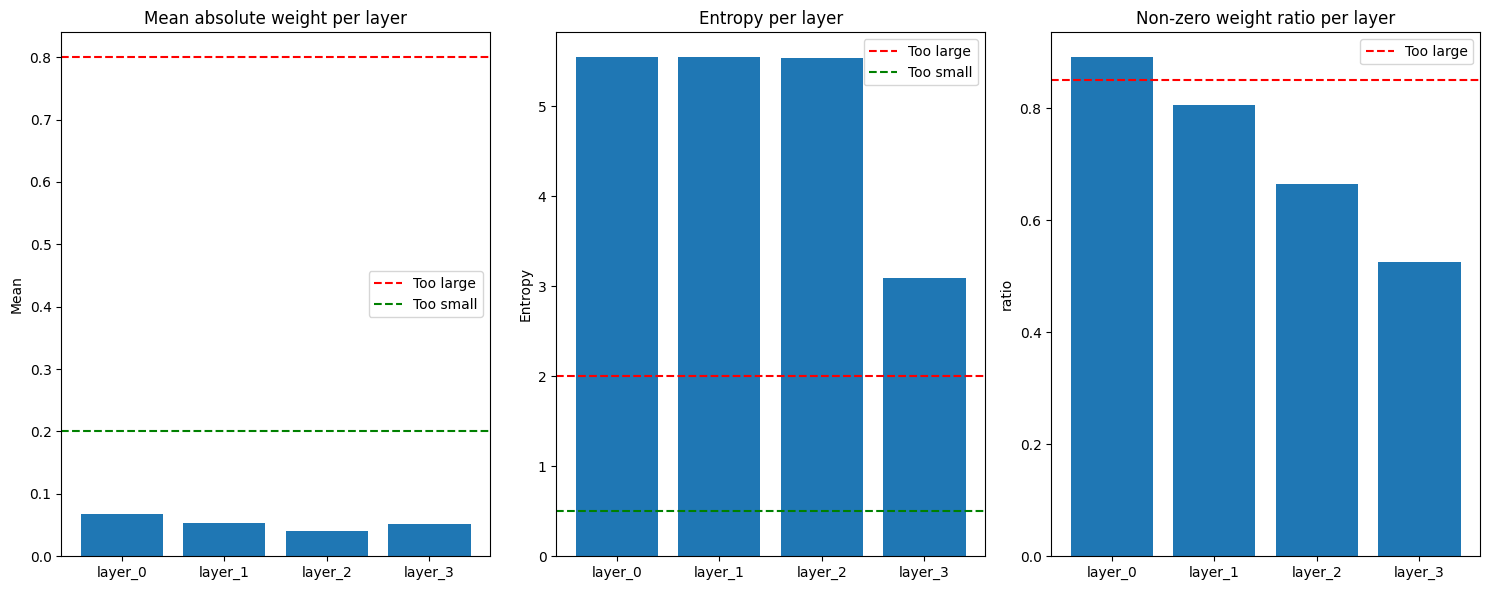

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.9725
Epoch 3/100 Loss:3.0377 Train Acc:0.6304 Train F1:0.6274 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.9505
Epoch 4/100 Loss:2.9168 Train Acc:0.6612 Train F1:0.6588 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.9351
Epoch 5/100 Loss:2.8220 Train Acc:0.6847 Train F1:0.6826 LR:0.001000


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 5/100
  Train: Acc:0.6847  F1:0.6826
  Val:   Acc:0.6159  F1:0.6084  Kappa:0.6017  Balanced Acc:0.6246
  Diff:  F1:0.0743 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0462
平均熵值: 4.8003


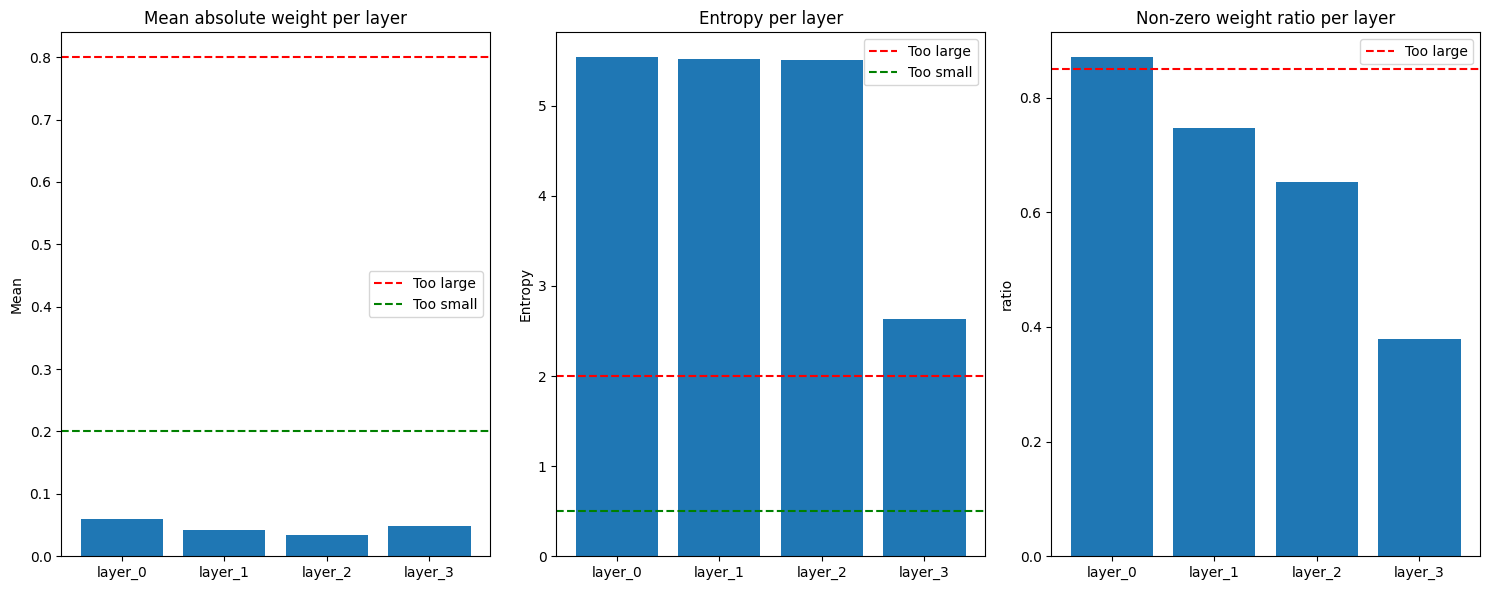

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.9205
Epoch 6/100 Loss:2.7332 Train Acc:0.7093 Train F1:0.7077 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.9029
Epoch 7/100 Loss:2.6575 Train Acc:0.7285 Train F1:0.7272 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.8895
Epoch 8/100 Loss:2.5893 Train Acc:0.7455 Train F1:0.7444 LR:0.001000


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 8/100
  Train: Acc:0.7455  F1:0.7444
  Val:   Acc:0.6356  F1:0.6308  Kappa:0.6220  Balanced Acc:0.6409
  Diff:  F1:0.1136 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0433
平均熵值: 4.6894


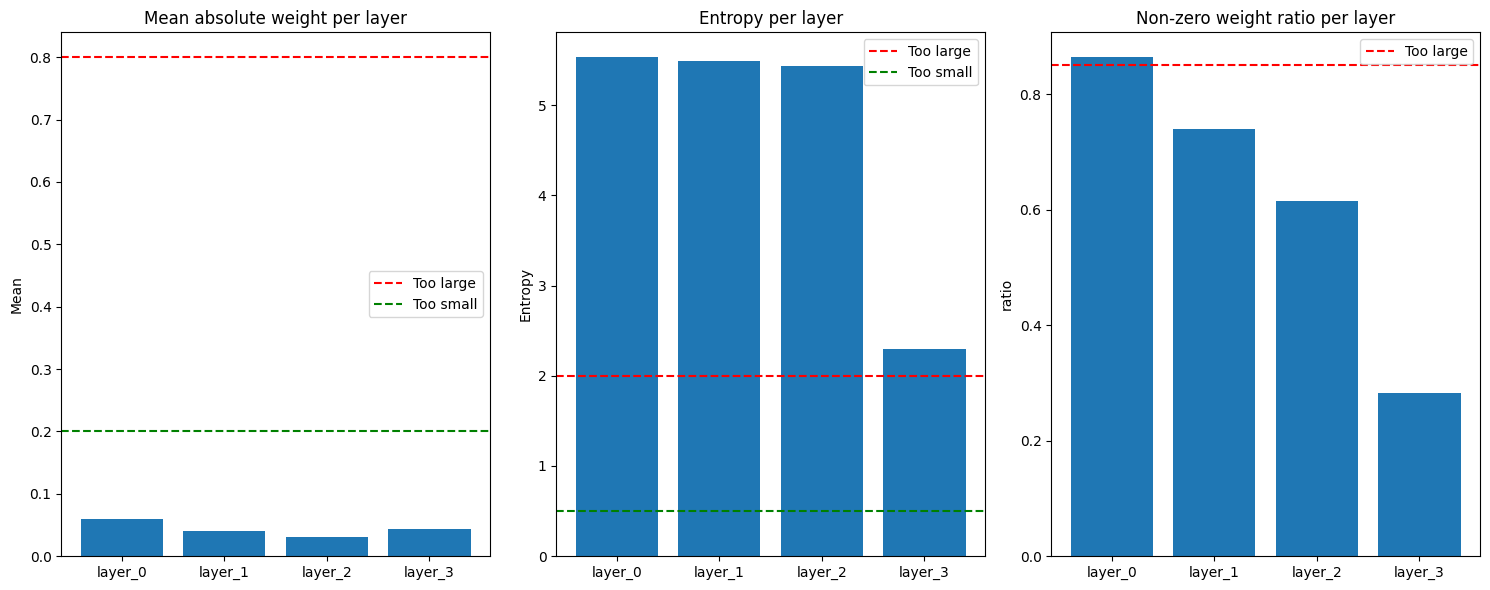

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.8761
Epoch 9/100 Loss:2.5268 Train Acc:0.7627 Train F1:0.7618 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.8612
Epoch 10/100 Loss:2.4701 Train Acc:0.7759 Train F1:0.7751 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.8390
Epoch 11/100 Loss:2.4140 Train Acc:0.7869 Train F1:0.7863 LR:0.001000


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 11/100
  Train: Acc:0.7869  F1:0.7863
  Val:   Acc:0.6248  F1:0.6230  Kappa:0.6108  Balanced Acc:0.6315
  Diff:  F1:0.1632 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0407
平均熵值: 4.5383


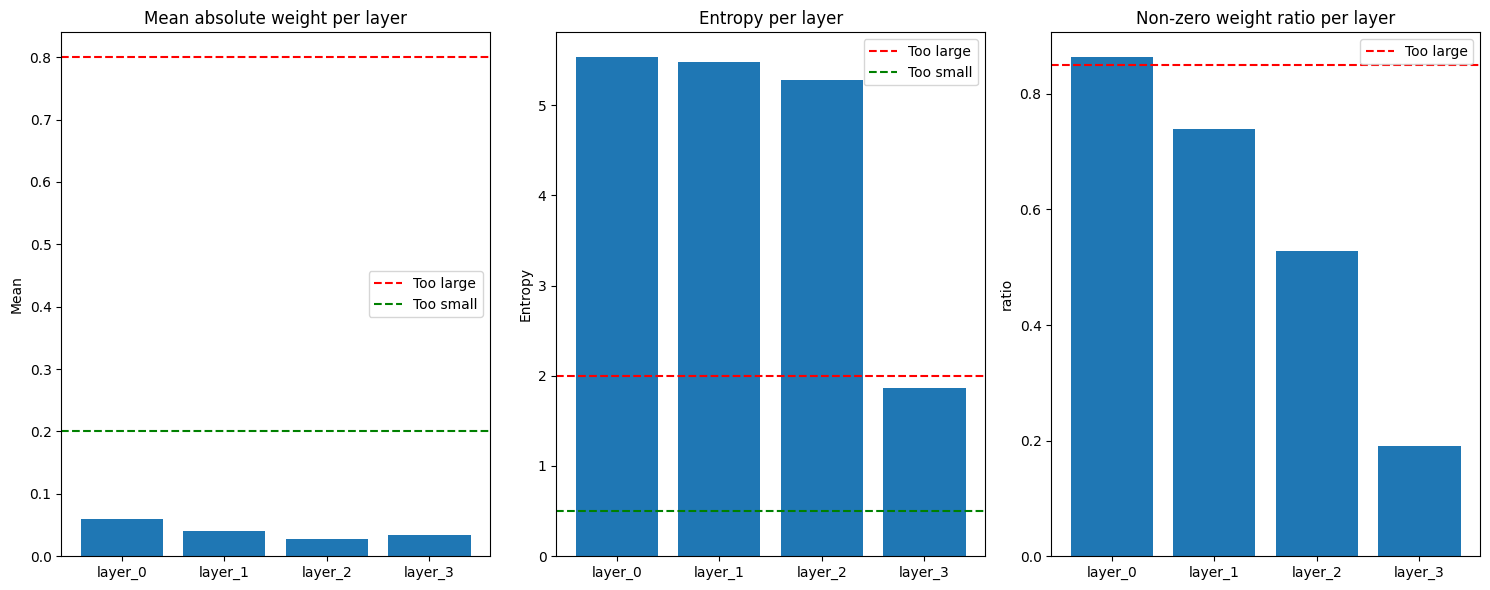

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.8157
Epoch 12/100 Loss:2.3523 Train Acc:0.7995 Train F1:0.7990 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.7871
Epoch 13/100 Loss:2.2928 Train Acc:0.8064 Train F1:0.8059 LR:0.001000


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.7407
Epoch 14/100 Loss:2.2195 Train Acc:0.8163 Train F1:0.8159 LR:0.001000


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 14/100
  Train: Acc:0.8163  F1:0.8159
  Val:   Acc:0.6336  F1:0.6301  Kappa:0.6202  Balanced Acc:0.6454
  Diff:  F1:0.1858 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0370
平均熵值: 4.2314


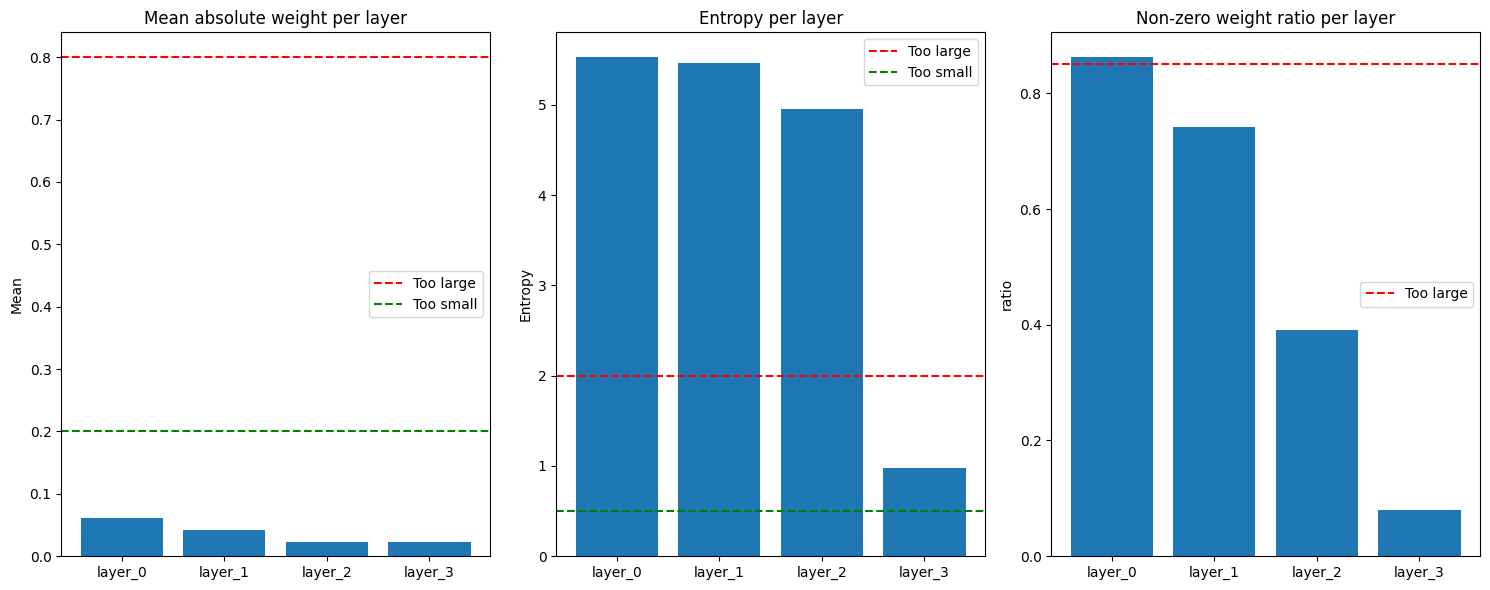

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.6929
Epoch 15/100 Loss:1.9794 Train Acc:0.8822 Train F1:0.8821 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.6369
Epoch 16/100 Loss:1.9073 Train Acc:0.8949 Train F1:0.8947 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.6053
Epoch 17/100 Loss:1.8597 Train Acc:0.9025 Train F1:0.9024 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 17/100
  Train: Acc:0.9025  F1:0.9024
  Val:   Acc:0.6432  F1:0.6405  Kappa:0.6299  Balanced Acc:0.6520
  Diff:  F1:0.2619 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0324
平均熵值: 3.9693


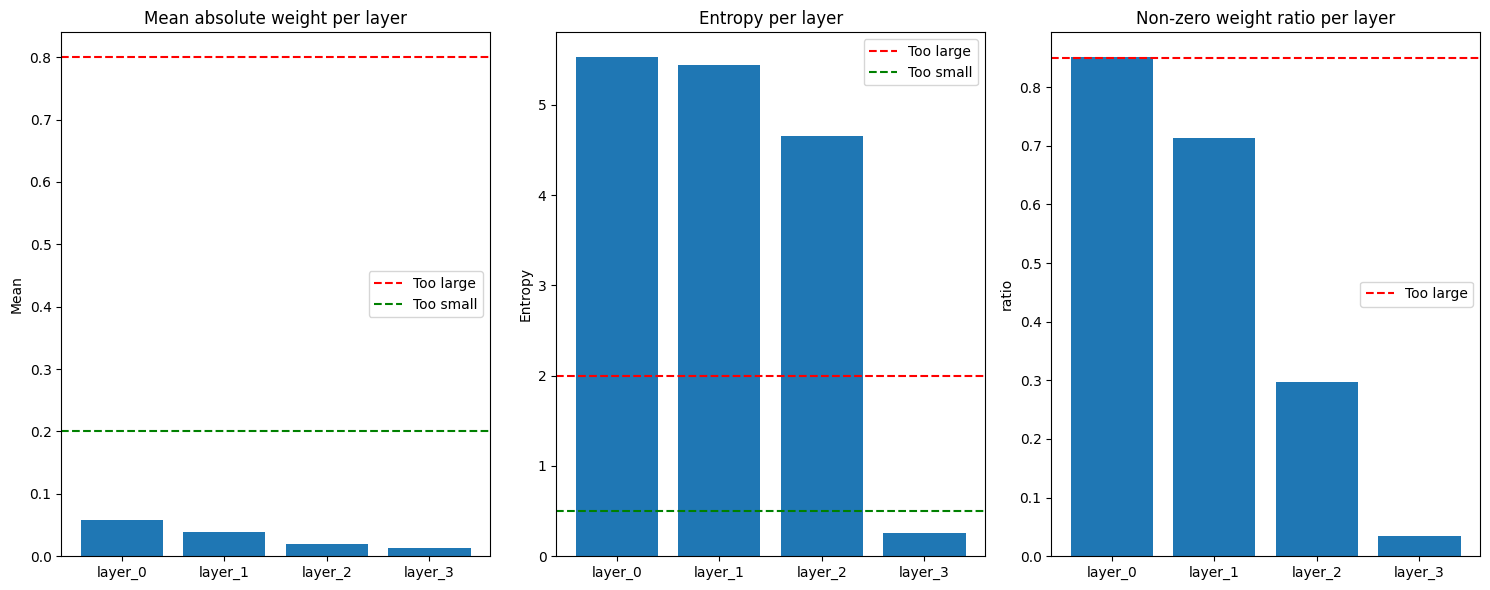

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5880
Epoch 18/100 Loss:1.8303 Train Acc:0.9083 Train F1:0.9082 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5818
Epoch 19/100 Loss:1.8042 Train Acc:0.9173 Train F1:0.9172 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5771
Epoch 20/100 Loss:1.7874 Train Acc:0.9216 Train F1:0.9215 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 20/100
  Train: Acc:0.9216  F1:0.9215
  Val:   Acc:0.6372  F1:0.6366  Kappa:0.6237  Balanced Acc:0.6441
  Diff:  F1:0.2849 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0315
平均熵值: 3.9321


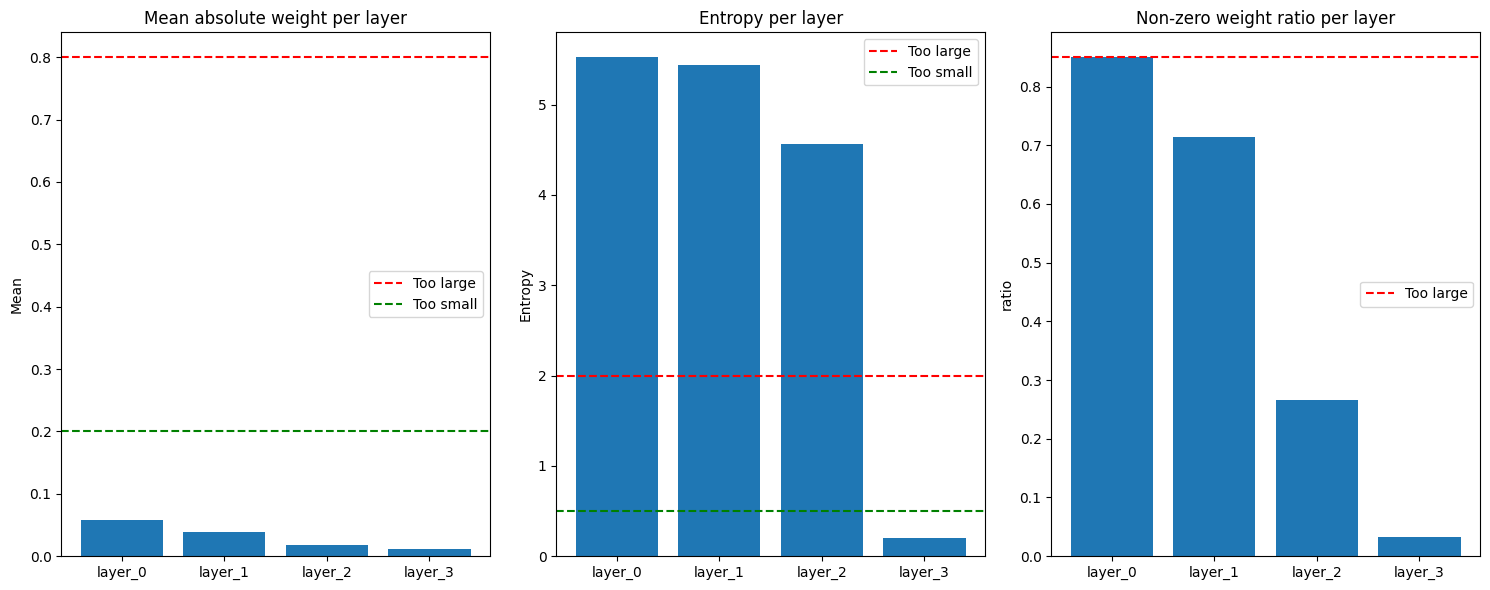

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5731
Epoch 21/100 Loss:1.7773 Train Acc:0.9238 Train F1:0.9238 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5702
Epoch 22/100 Loss:1.7609 Train Acc:0.9290 Train F1:0.9290 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5669
Epoch 23/100 Loss:1.7543 Train Acc:0.9304 Train F1:0.9304 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 23/100
  Train: Acc:0.9304  F1:0.9304
  Val:   Acc:0.6400  F1:0.6379  Kappa:0.6267  Balanced Acc:0.6478
  Diff:  F1:0.2925 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0312
平均熵值: 3.9182


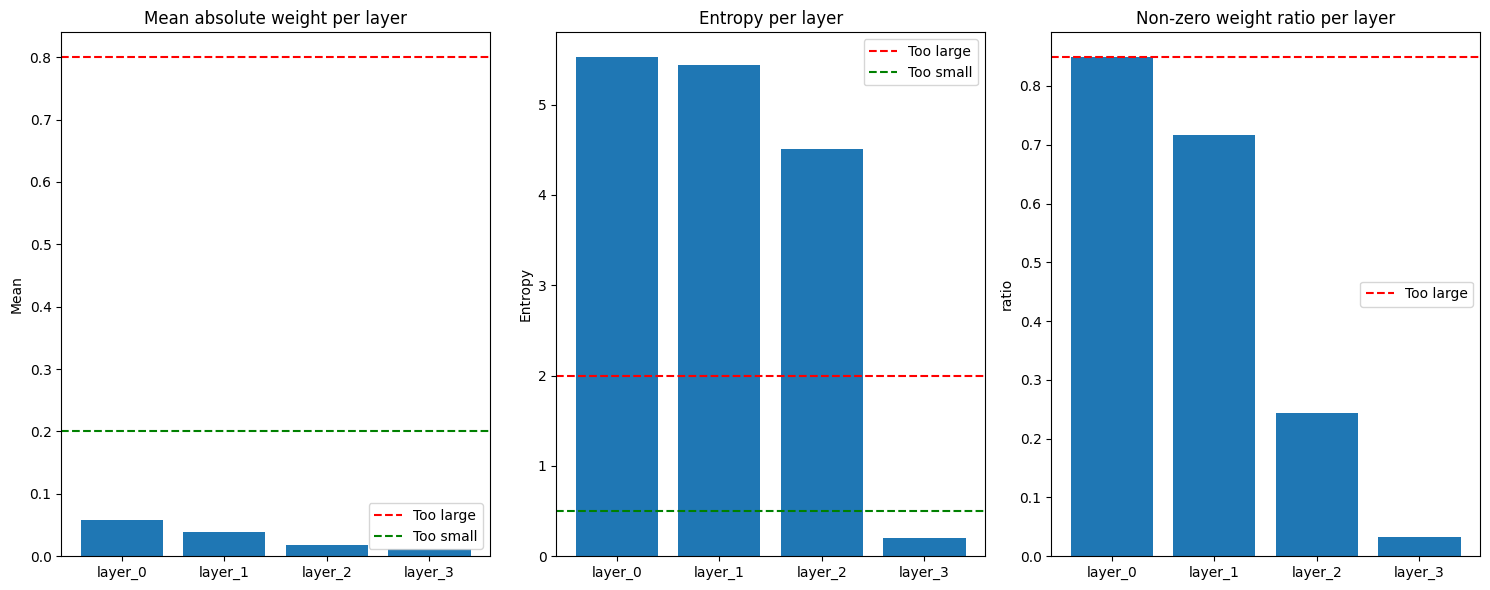

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5676
Epoch 24/100 Loss:1.7464 Train Acc:0.9319 Train F1:0.9318 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5630
Epoch 25/100 Loss:1.7413 Train Acc:0.9332 Train F1:0.9332 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5606
Epoch 26/100 Loss:1.7282 Train Acc:0.9360 Train F1:0.9360 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 26/100
  Train: Acc:0.9360  F1:0.9360
  Val:   Acc:0.6371  F1:0.6348  Kappa:0.6236  Balanced Acc:0.6441
  Diff:  F1:0.3011 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0309
平均熵值: 3.8871


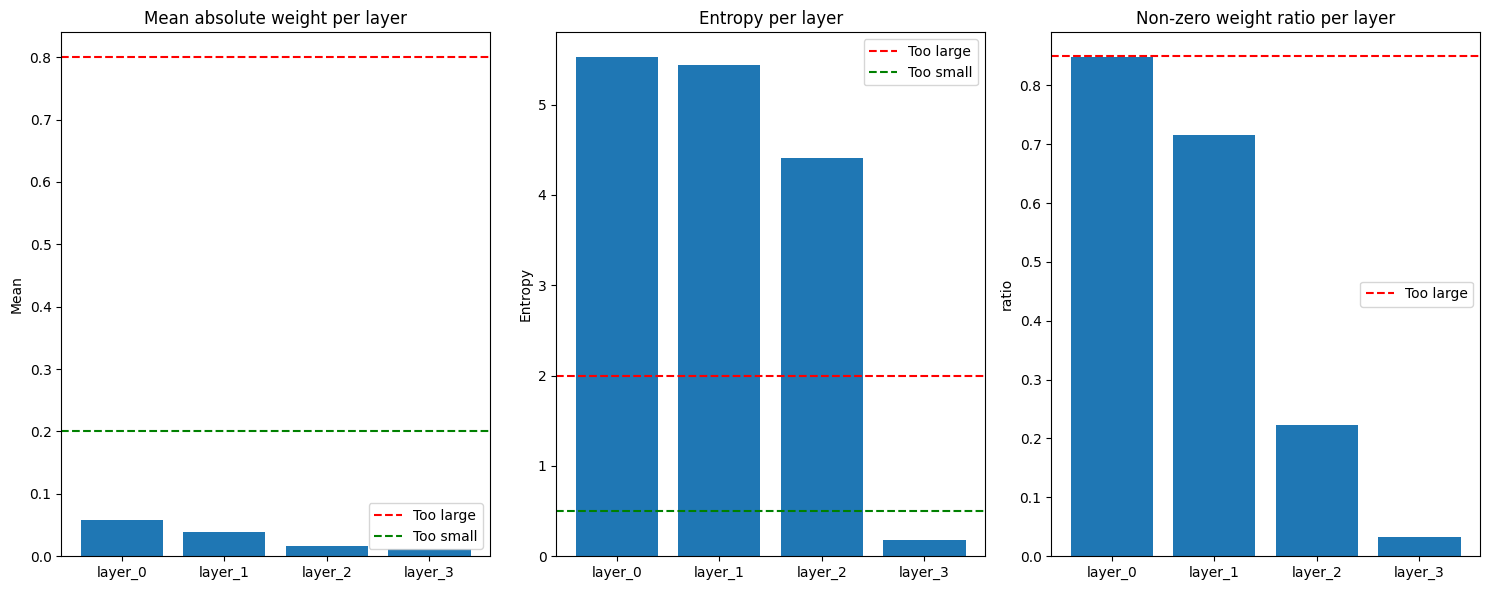

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5551
Epoch 27/100 Loss:1.7256 Train Acc:0.9365 Train F1:0.9364 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5545
Epoch 28/100 Loss:1.7155 Train Acc:0.9393 Train F1:0.9393 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5490
Epoch 29/100 Loss:1.7124 Train Acc:0.9390 Train F1:0.9390 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 29/100
  Train: Acc:0.9390  F1:0.9390
  Val:   Acc:0.6405  F1:0.6380  Kappa:0.6268  Balanced Acc:0.6416
  Diff:  F1:0.3010 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0306
平均熵值: 3.8749


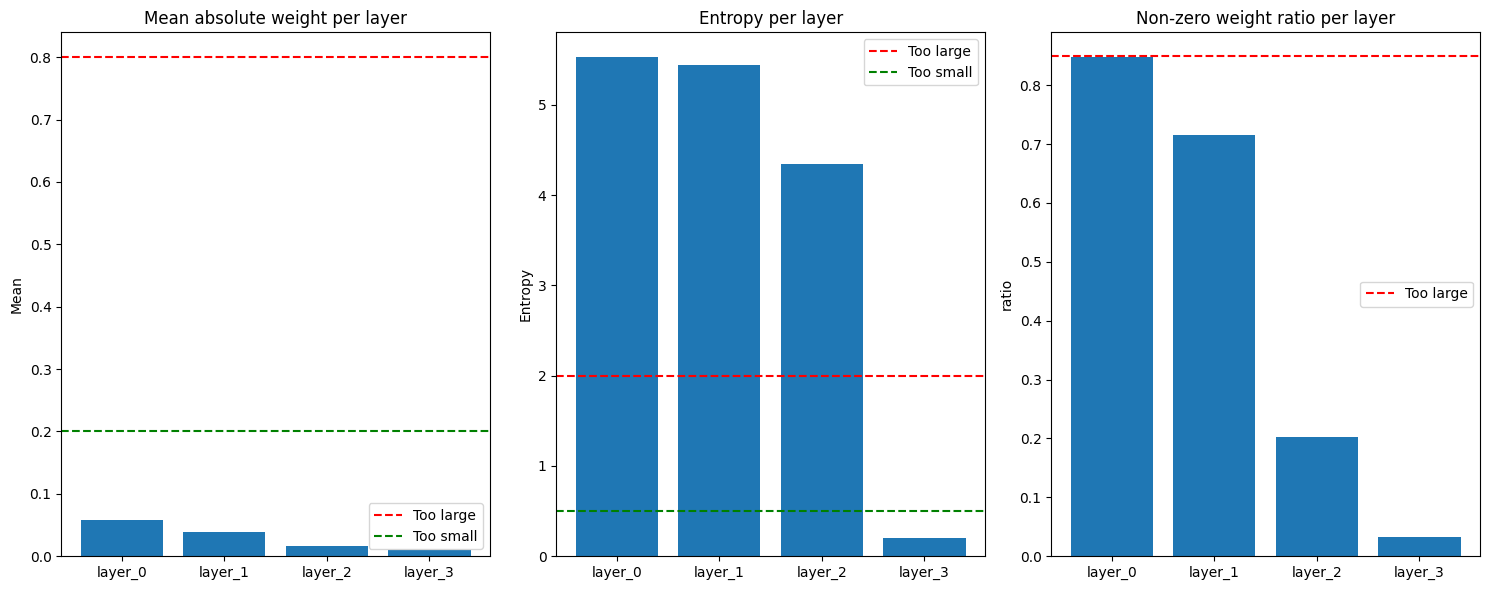

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5502
Epoch 30/100 Loss:1.7039 Train Acc:0.9414 Train F1:0.9413 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5428
Epoch 31/100 Loss:1.7036 Train Acc:0.9402 Train F1:0.9401 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5425
Epoch 32/100 Loss:1.6921 Train Acc:0.9431 Train F1:0.9431 LR:0.000600


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 32/100
  Train: Acc:0.9431  F1:0.9431
  Val:   Acc:0.6339  F1:0.6334  Kappa:0.6204  Balanced Acc:0.6432
  Diff:  F1:0.3096 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0303
平均熵值: 3.8467


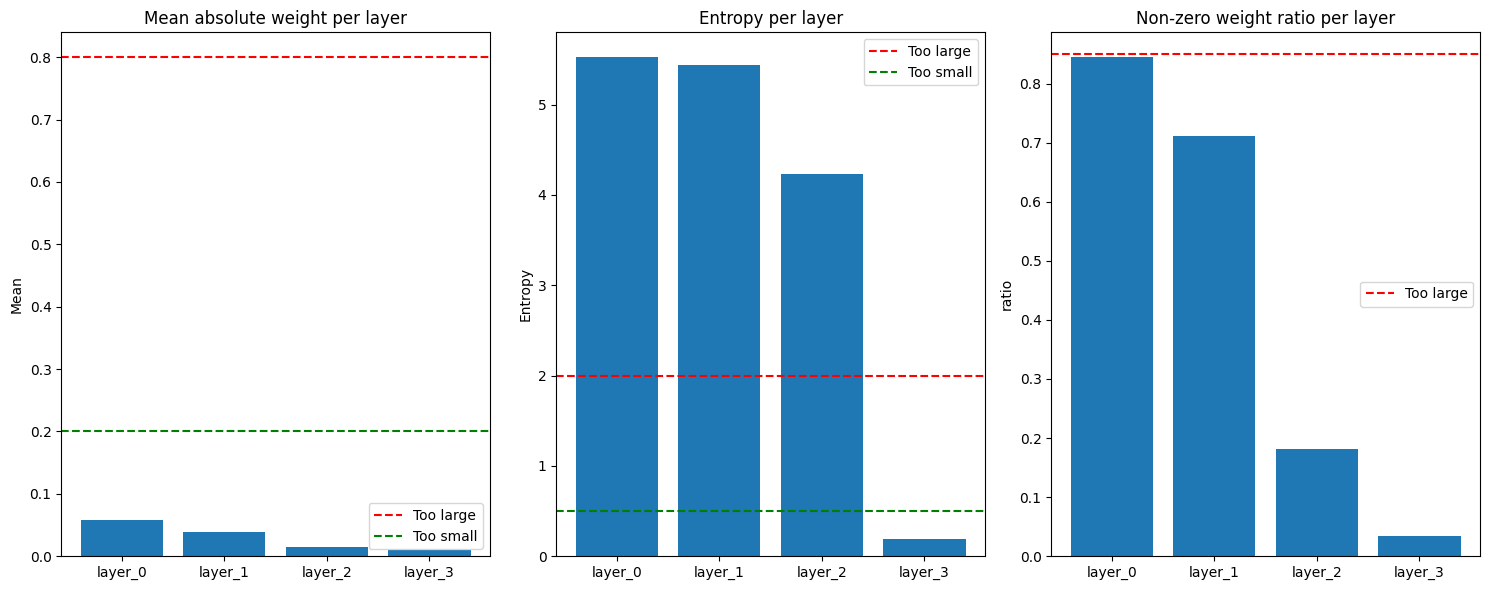

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5390
Epoch 33/100 Loss:1.6905 Train Acc:0.9427 Train F1:0.9426 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5370
Epoch 34/100 Loss:1.6840 Train Acc:0.9437 Train F1:0.9437 LR:0.000600


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.5339
Epoch 35/100 Loss:1.5517 Train Acc:0.9845 Train F1:0.9845 LR:0.000360


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 35/100
  Train: Acc:0.9845  F1:0.9845
  Val:   Acc:0.6529  F1:0.6506  Kappa:0.6400  Balanced Acc:0.6610
  Diff:  F1:0.3339 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0285
平均熵值: 3.7464


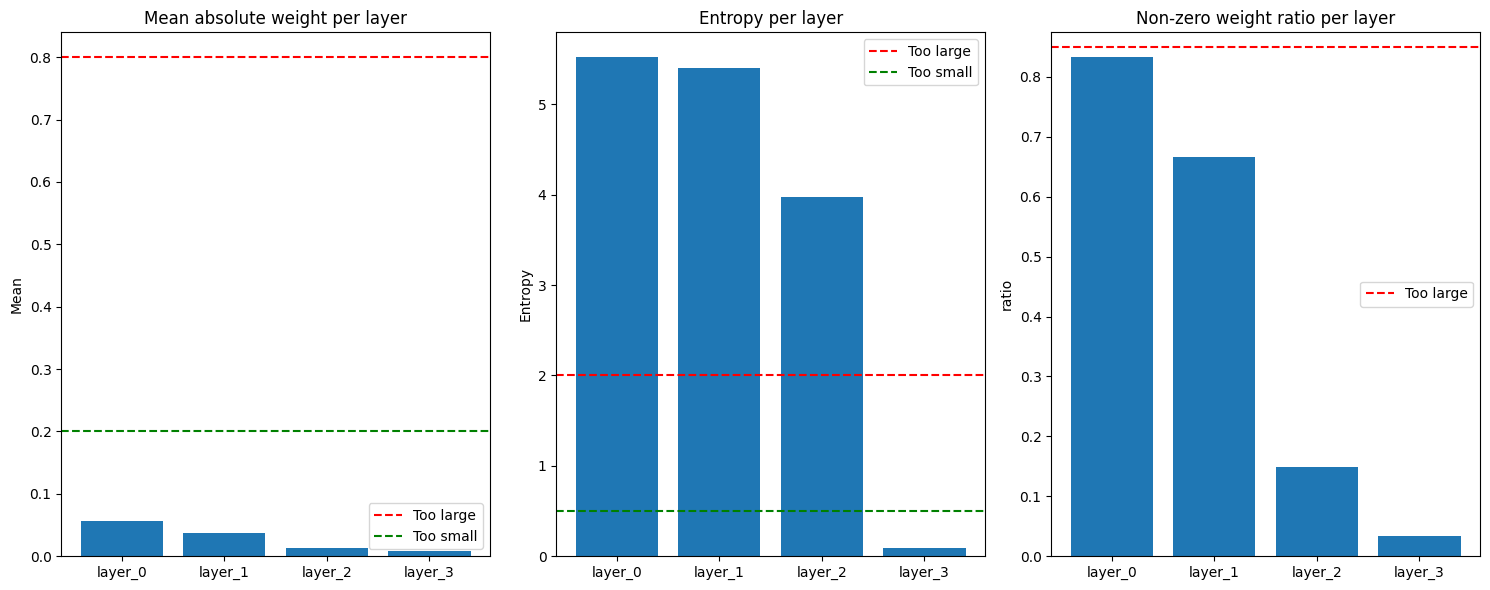

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4988
Epoch 36/100 Loss:1.5448 Train Acc:0.9833 Train F1:0.9833 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4982
Epoch 37/100 Loss:1.5560 Train Acc:0.9782 Train F1:0.9782 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4912
Epoch 38/100 Loss:1.5465 Train Acc:0.9787 Train F1:0.9787 LR:0.000360


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 38/100
  Train: Acc:0.9787  F1:0.9787
  Val:   Acc:0.6417  F1:0.6392  Kappa:0.6285  Balanced Acc:0.6512
  Diff:  F1:0.3395 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0268
平均熵值: 3.7128


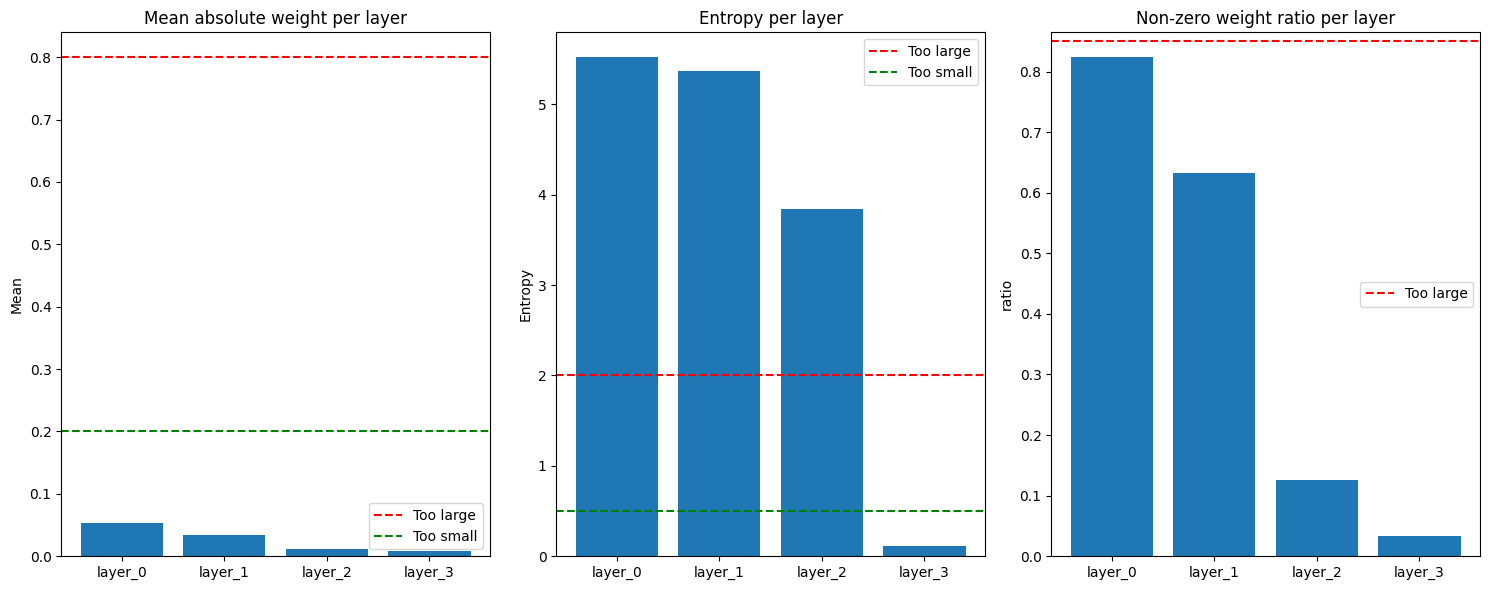

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4854
Epoch 39/100 Loss:1.5415 Train Acc:0.9783 Train F1:0.9783 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4773
Epoch 40/100 Loss:1.5370 Train Acc:0.9777 Train F1:0.9777 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4732
Epoch 41/100 Loss:1.5273 Train Acc:0.9790 Train F1:0.9789 LR:0.000360


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 41/100
  Train: Acc:0.9790  F1:0.9789
  Val:   Acc:0.6389  F1:0.6381  Kappa:0.6255  Balanced Acc:0.6451
  Diff:  F1:0.3409 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0258
平均熵值: 3.6732


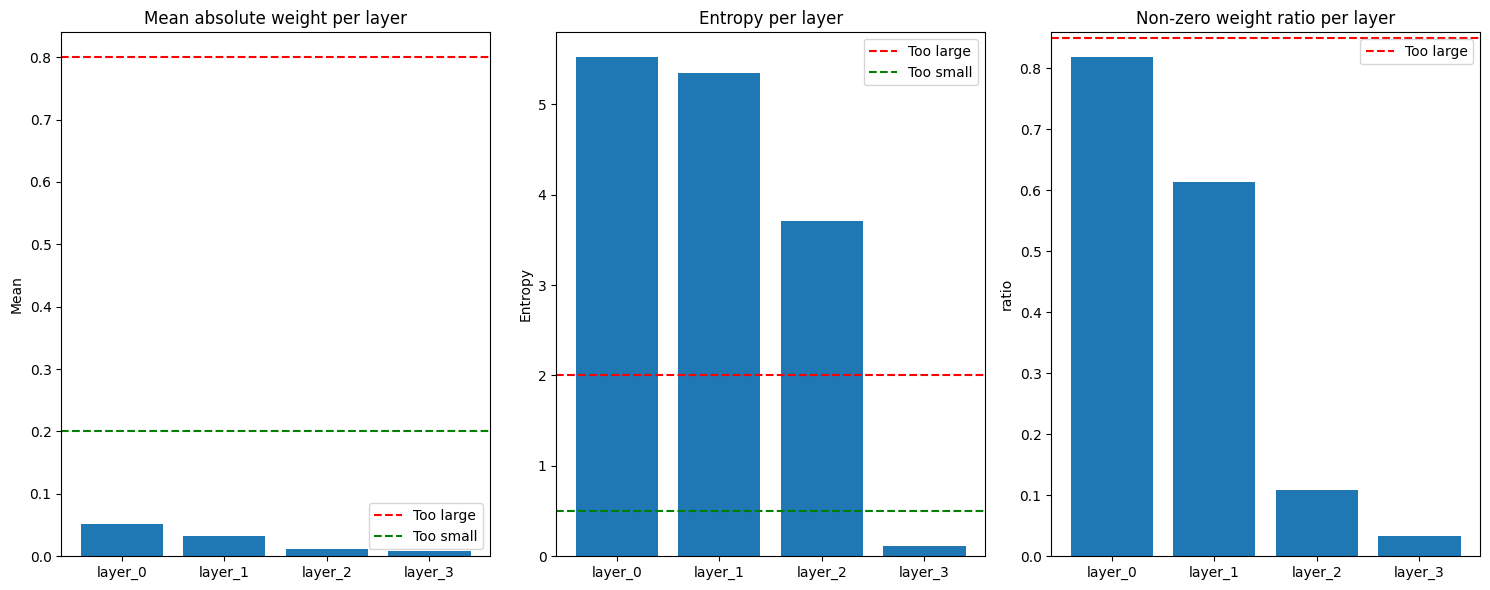

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4695
Epoch 42/100 Loss:1.5234 Train Acc:0.9783 Train F1:0.9783 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4624
Epoch 43/100 Loss:1.5197 Train Acc:0.9775 Train F1:0.9775 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4601
Epoch 44/100 Loss:1.5146 Train Acc:0.9777 Train F1:0.9777 LR:0.000360


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 44/100
  Train: Acc:0.9777  F1:0.9777
  Val:   Acc:0.6474  F1:0.6451  Kappa:0.6340  Balanced Acc:0.6502
  Diff:  F1:0.3325 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0250
平均熵值: 3.6233


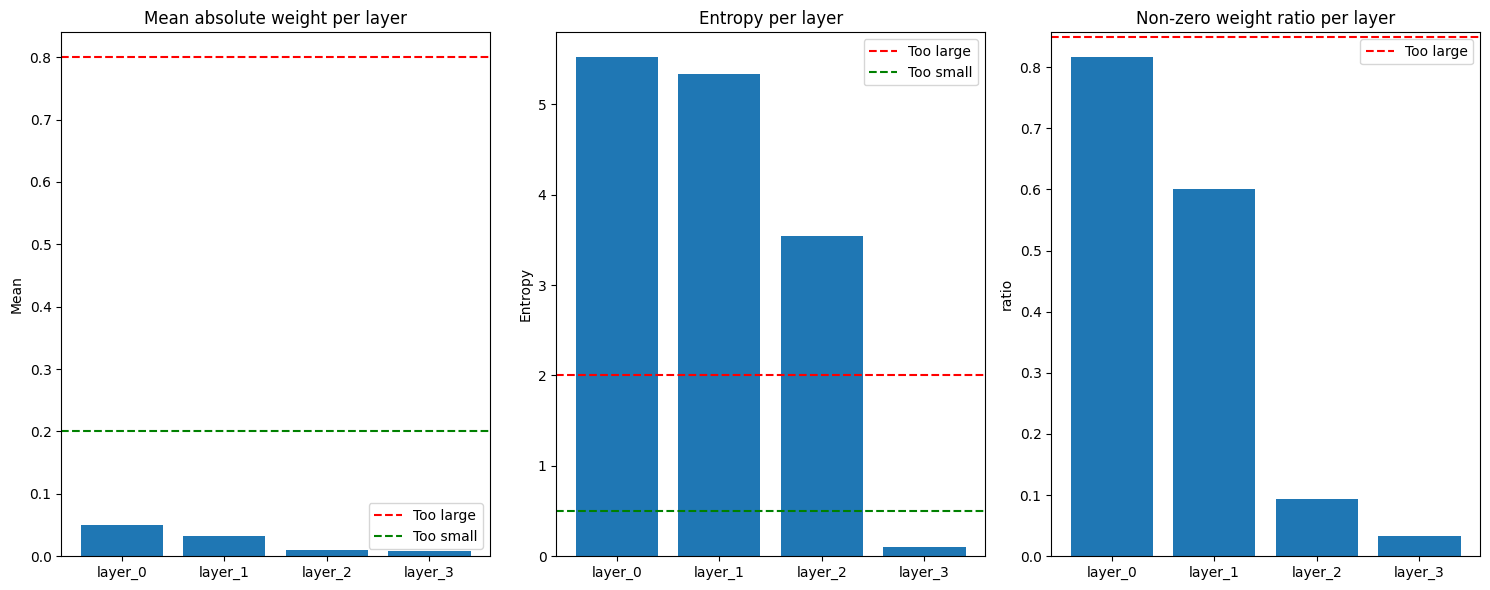

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4496
Epoch 45/100 Loss:1.5072 Train Acc:0.9777 Train F1:0.9777 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4464
Epoch 46/100 Loss:1.5086 Train Acc:0.9757 Train F1:0.9756 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4397
Epoch 47/100 Loss:1.4948 Train Acc:0.9777 Train F1:0.9777 LR:0.000360


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 47/100
  Train: Acc:0.9777  F1:0.9777
  Val:   Acc:0.6448  F1:0.6434  Kappa:0.6315  Balanced Acc:0.6498
  Diff:  F1:0.3343 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0244
平均熵值: 3.5811


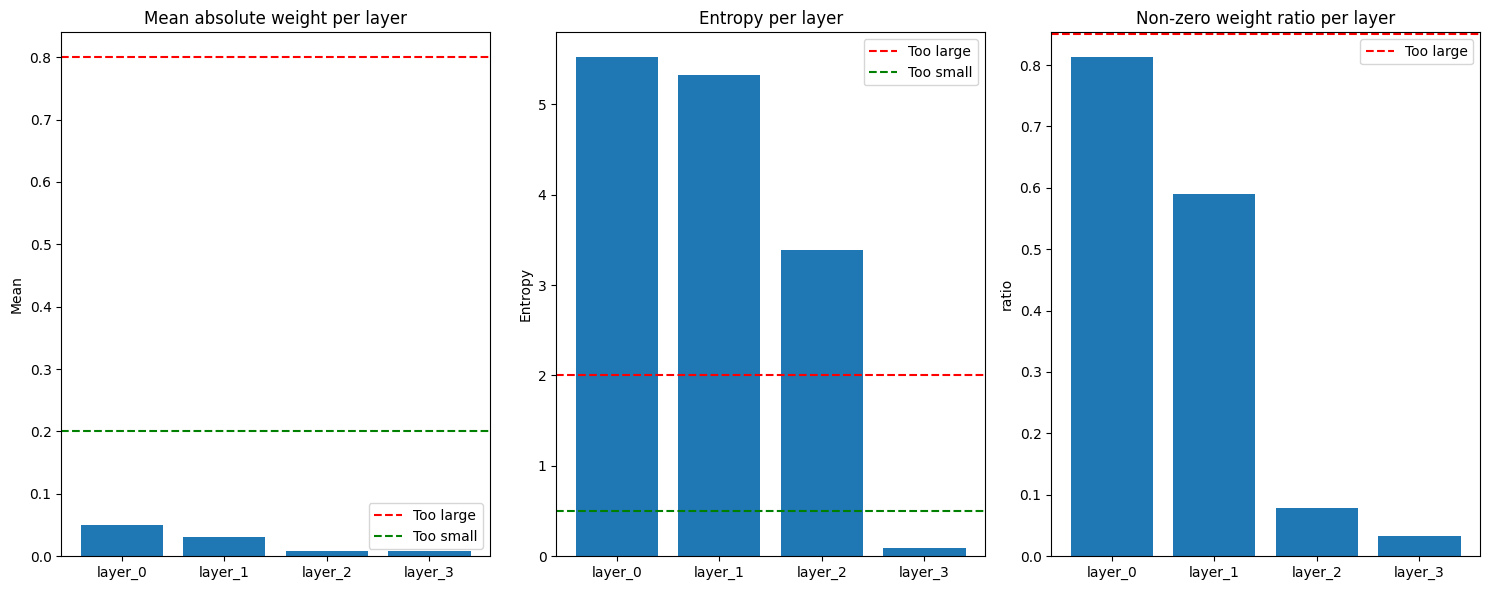

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4327
Epoch 48/100 Loss:1.4875 Train Acc:0.9786 Train F1:0.9786 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4259
Epoch 49/100 Loss:1.4890 Train Acc:0.9758 Train F1:0.9758 LR:0.000360


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.4254
Epoch 50/100 Loss:1.4084 Train Acc:0.9966 Train F1:0.9966 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 50/100
  Train: Acc:0.9966  F1:0.9966
  Val:   Acc:0.6531  F1:0.6515  Kappa:0.6402  Balanced Acc:0.6605
  Diff:  F1:0.3452 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0227
平均熵值: 3.4653


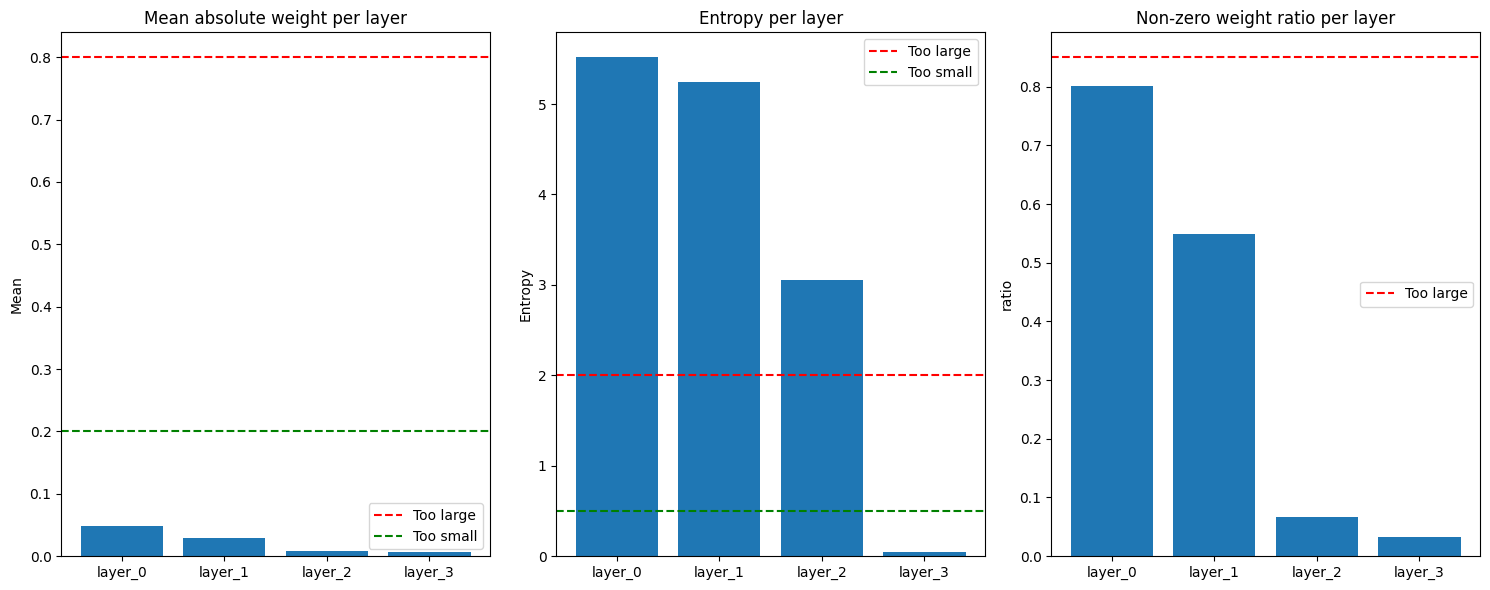

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3863
Epoch 51/100 Loss:1.3997 Train Acc:0.9953 Train F1:0.9953 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3872
Epoch 52/100 Loss:1.4048 Train Acc:0.9922 Train F1:0.9922 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3727
Epoch 53/100 Loss:1.3937 Train Acc:0.9923 Train F1:0.9923 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 53/100
  Train: Acc:0.9923  F1:0.9923
  Val:   Acc:0.6455  F1:0.6444  Kappa:0.6323  Balanced Acc:0.6533
  Diff:  F1:0.3480 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0214
平均熵值: 3.4120


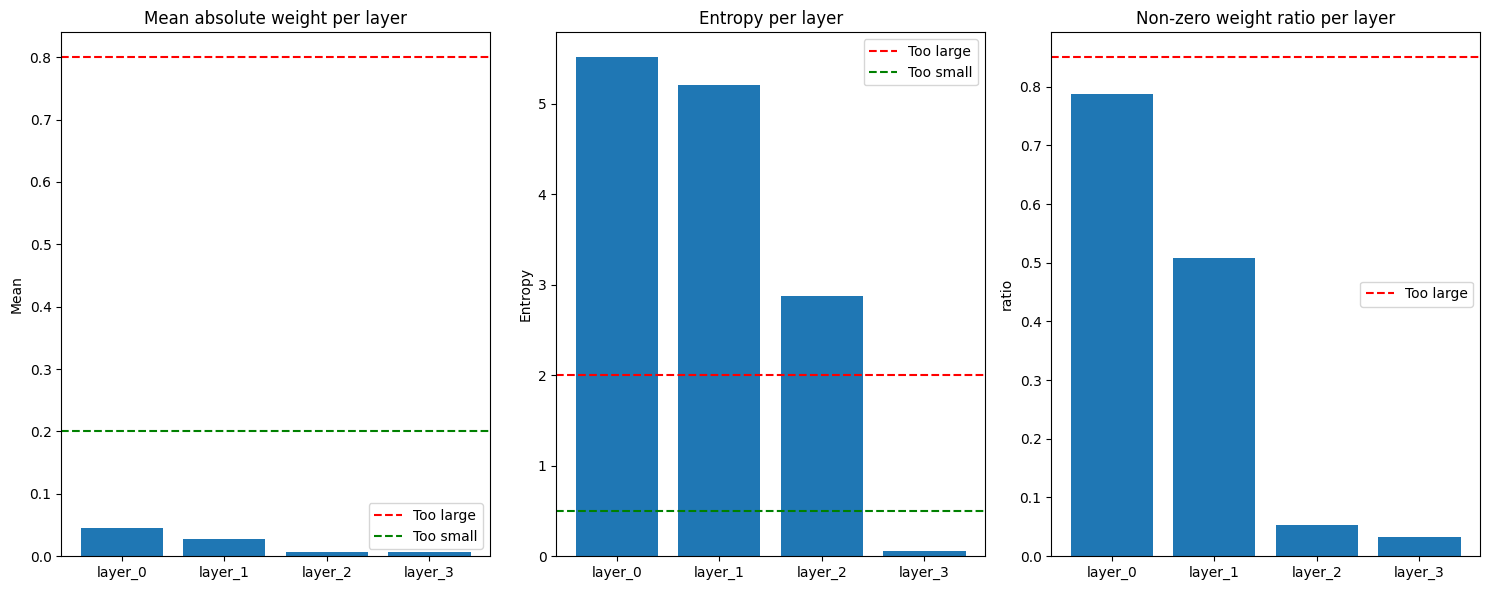

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3650
Epoch 54/100 Loss:1.3843 Train Acc:0.9926 Train F1:0.9926 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3612
Epoch 55/100 Loss:1.3722 Train Acc:0.9936 Train F1:0.9936 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3498
Epoch 56/100 Loss:1.3707 Train Acc:0.9916 Train F1:0.9916 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 56/100
  Train: Acc:0.9916  F1:0.9916
  Val:   Acc:0.6486  F1:0.6466  Kappa:0.6354  Balanced Acc:0.6531
  Diff:  F1:0.3450 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0205
平均熵值: 3.3479


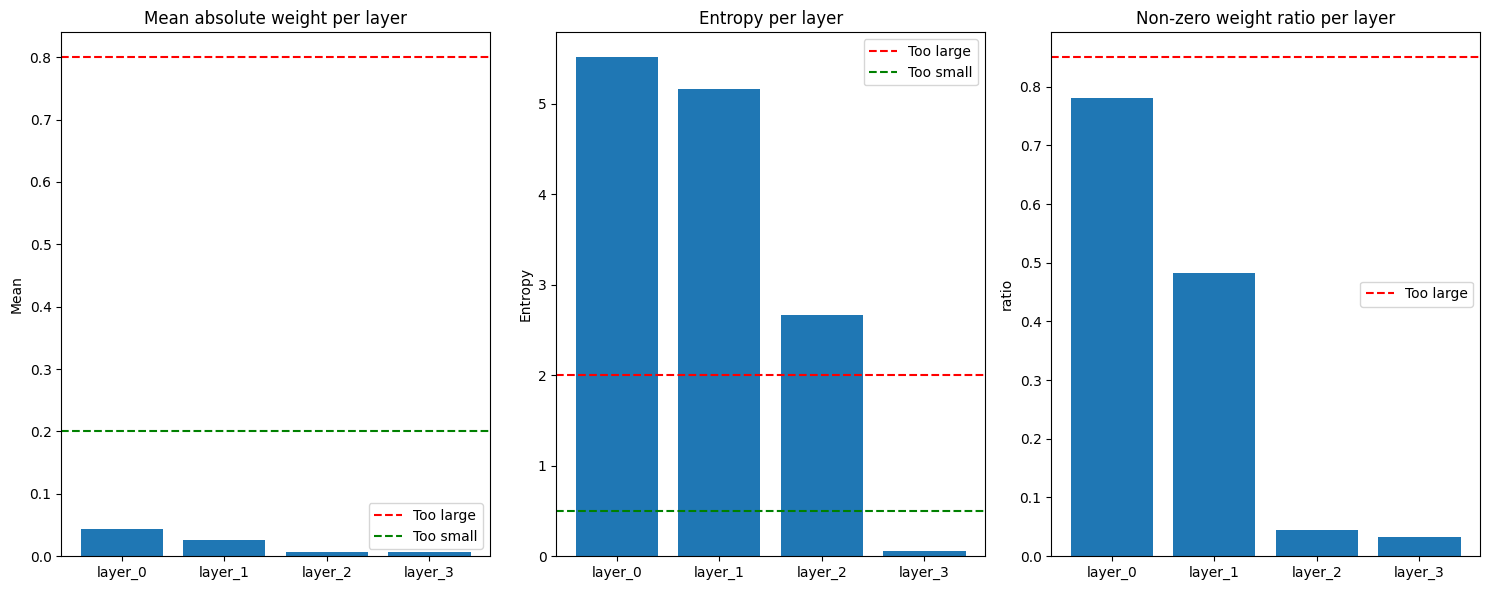

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3394
Epoch 57/100 Loss:1.3613 Train Acc:0.9916 Train F1:0.9916 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3403
Epoch 58/100 Loss:1.3505 Train Acc:0.9930 Train F1:0.9930 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3291
Epoch 59/100 Loss:1.3502 Train Acc:0.9909 Train F1:0.9909 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 59/100
  Train: Acc:0.9909  F1:0.9909
  Val:   Acc:0.6406  F1:0.6383  Kappa:0.6273  Balanced Acc:0.6495
  Diff:  F1:0.3526 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0198
平均熵值: 3.3014


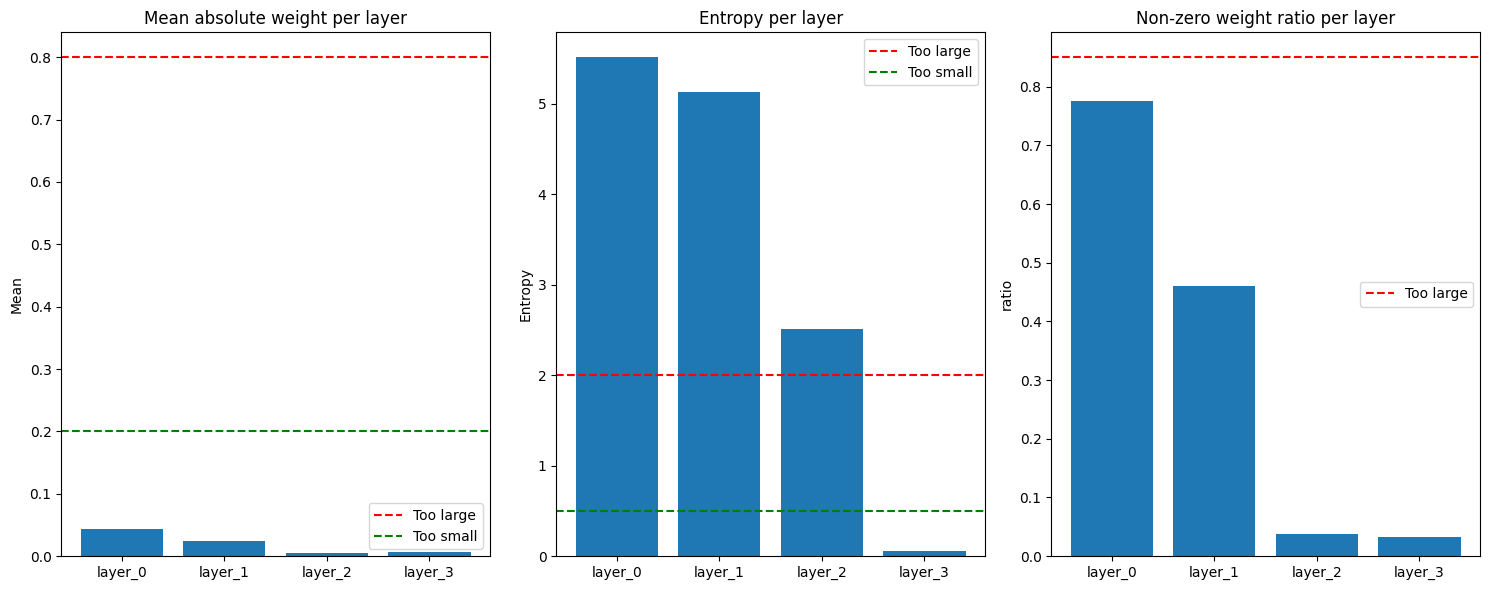

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3208
Epoch 60/100 Loss:1.3408 Train Acc:0.9916 Train F1:0.9916 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3158
Epoch 61/100 Loss:1.3384 Train Acc:0.9901 Train F1:0.9901 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3098
Epoch 62/100 Loss:1.3250 Train Acc:0.9922 Train F1:0.9922 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 62/100
  Train: Acc:0.9922  F1:0.9922
  Val:   Acc:0.6409  F1:0.6401  Kappa:0.6274  Balanced Acc:0.6479
  Diff:  F1:0.3521 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0192
平均熵值: 3.2581


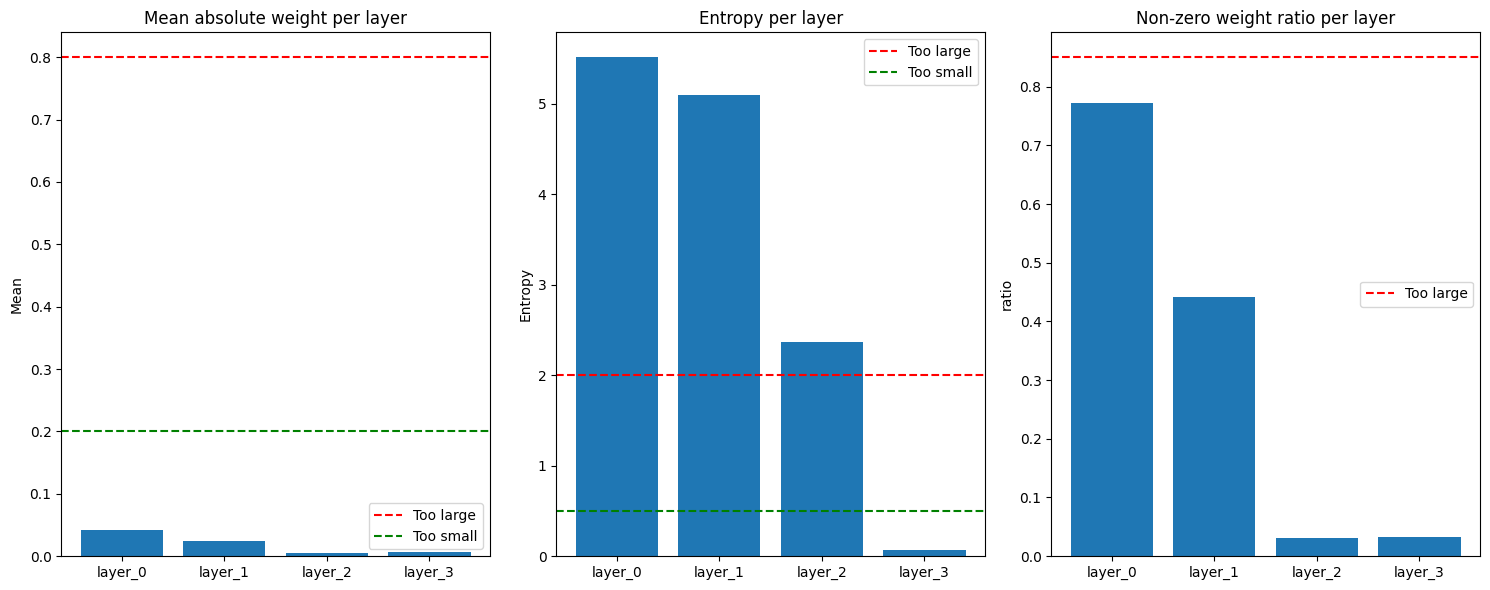

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3034
Epoch 63/100 Loss:1.3290 Train Acc:0.9891 Train F1:0.9891 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2943
Epoch 64/100 Loss:1.3103 Train Acc:0.9922 Train F1:0.9922 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.3003
Epoch 65/100 Loss:1.3152 Train Acc:0.9895 Train F1:0.9895 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 65/100
  Train: Acc:0.9895  F1:0.9895
  Val:   Acc:0.6358  F1:0.6348  Kappa:0.6224  Balanced Acc:0.6448
  Diff:  F1:0.3547 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0188
平均熵值: 3.2117


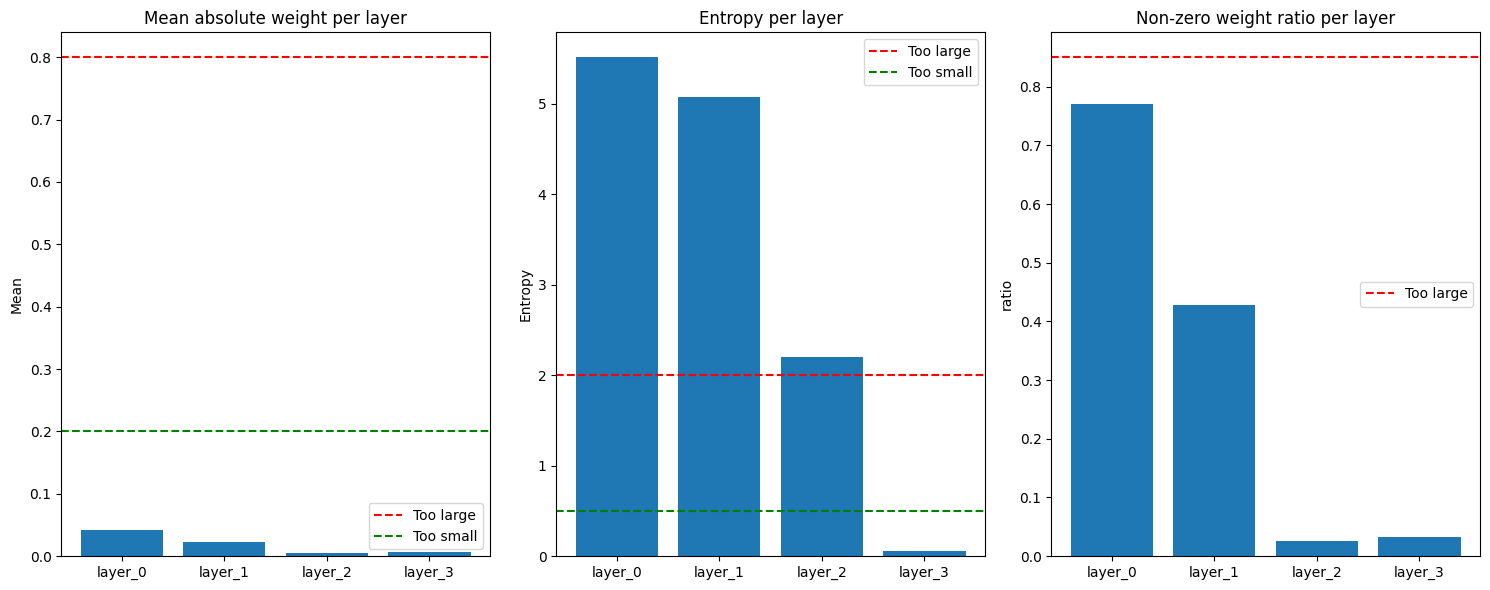

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2849
Epoch 66/100 Loss:1.3027 Train Acc:0.9909 Train F1:0.9909 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2752
Epoch 67/100 Loss:1.2940 Train Acc:0.9911 Train F1:0.9911 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2763
Epoch 68/100 Loss:1.2877 Train Acc:0.9908 Train F1:0.9908 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 68/100
  Train: Acc:0.9908  F1:0.9908
  Val:   Acc:0.6379  F1:0.6361  Kappa:0.6244  Balanced Acc:0.6459
  Diff:  F1:0.3547 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0184
平均熵值: 3.1548


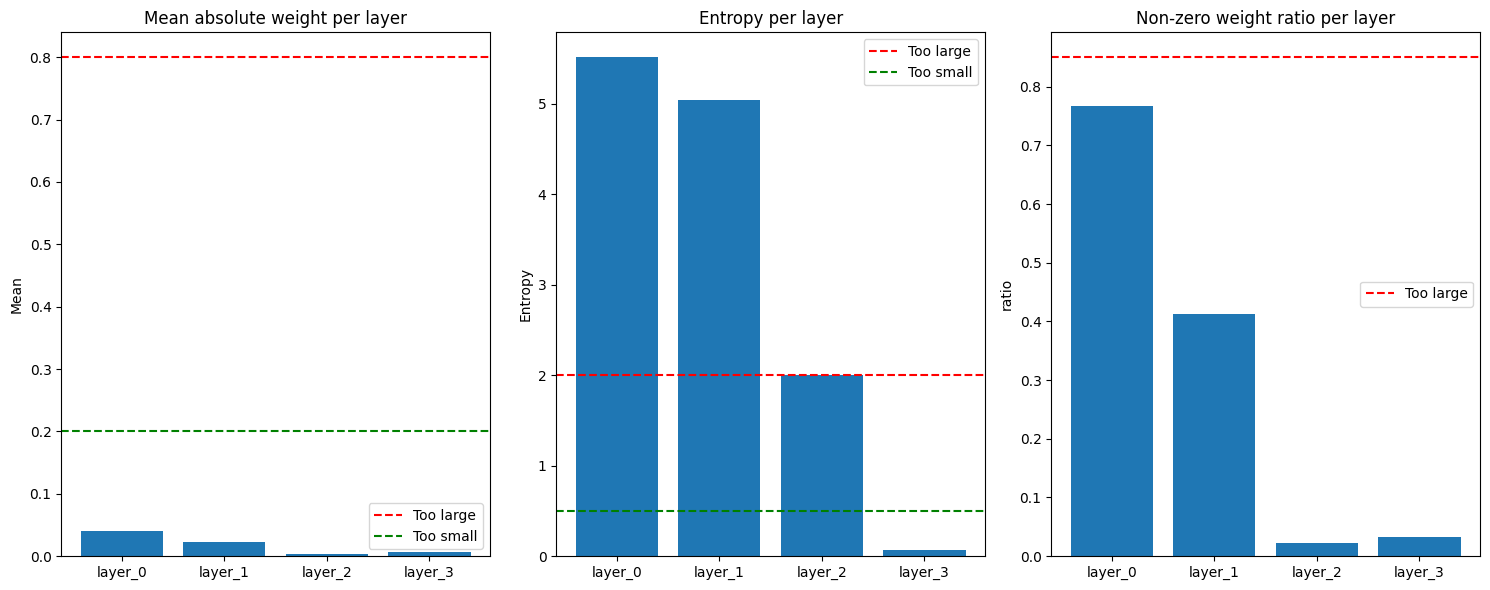

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2621
Epoch 69/100 Loss:1.2838 Train Acc:0.9893 Train F1:0.9893 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2515
Epoch 70/100 Loss:1.2688 Train Acc:0.9908 Train F1:0.9908 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2391
Epoch 71/100 Loss:1.2669 Train Acc:0.9885 Train F1:0.9885 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 71/100
  Train: Acc:0.9885  F1:0.9885
  Val:   Acc:0.6385  F1:0.6370  Kappa:0.6251  Balanced Acc:0.6459
  Diff:  F1:0.3516 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0180
平均熵值: 3.0701


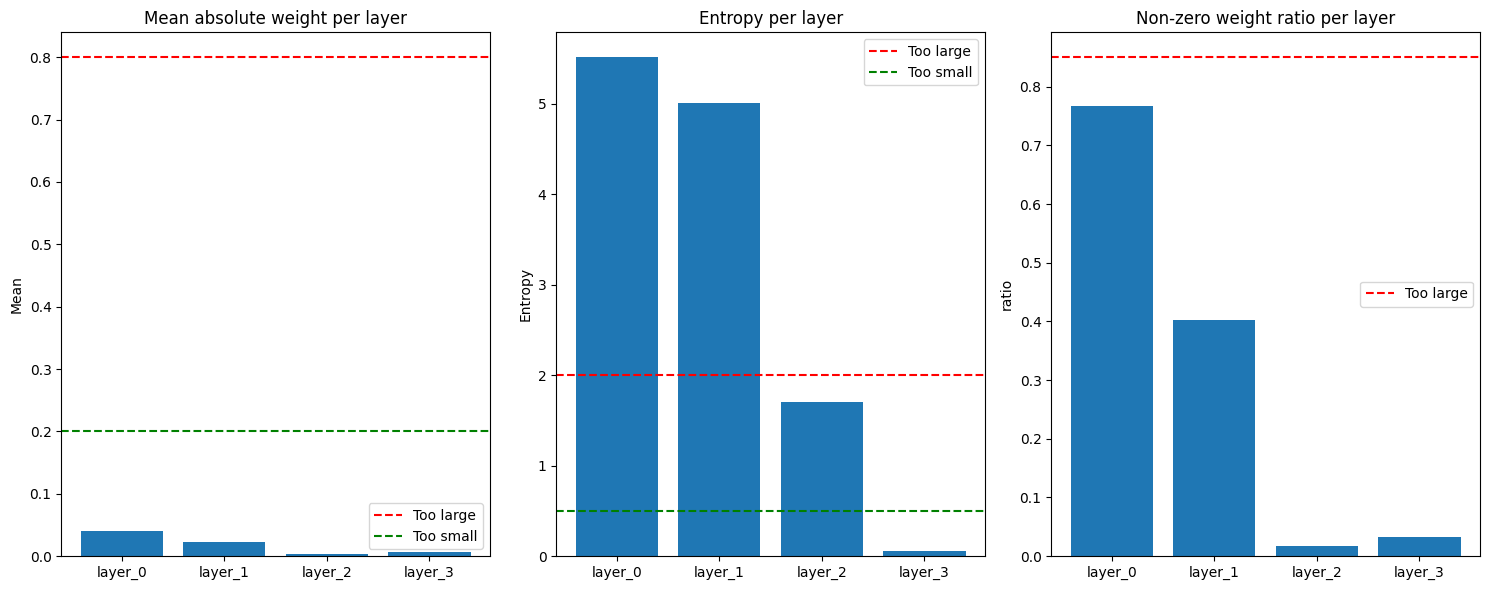

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2282
Epoch 72/100 Loss:1.2467 Train Acc:0.9908 Train F1:0.9908 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2178
Epoch 73/100 Loss:1.2437 Train Acc:0.9888 Train F1:0.9888 LR:0.000216


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2091
Epoch 74/100 Loss:1.2308 Train Acc:0.9890 Train F1:0.9890 LR:0.000216


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 74/100
  Train: Acc:0.9890  F1:0.9890
  Val:   Acc:0.6343  F1:0.6326  Kappa:0.6208  Balanced Acc:0.6426
  Diff:  F1:0.3564 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0178
平均熵值: 3.0193


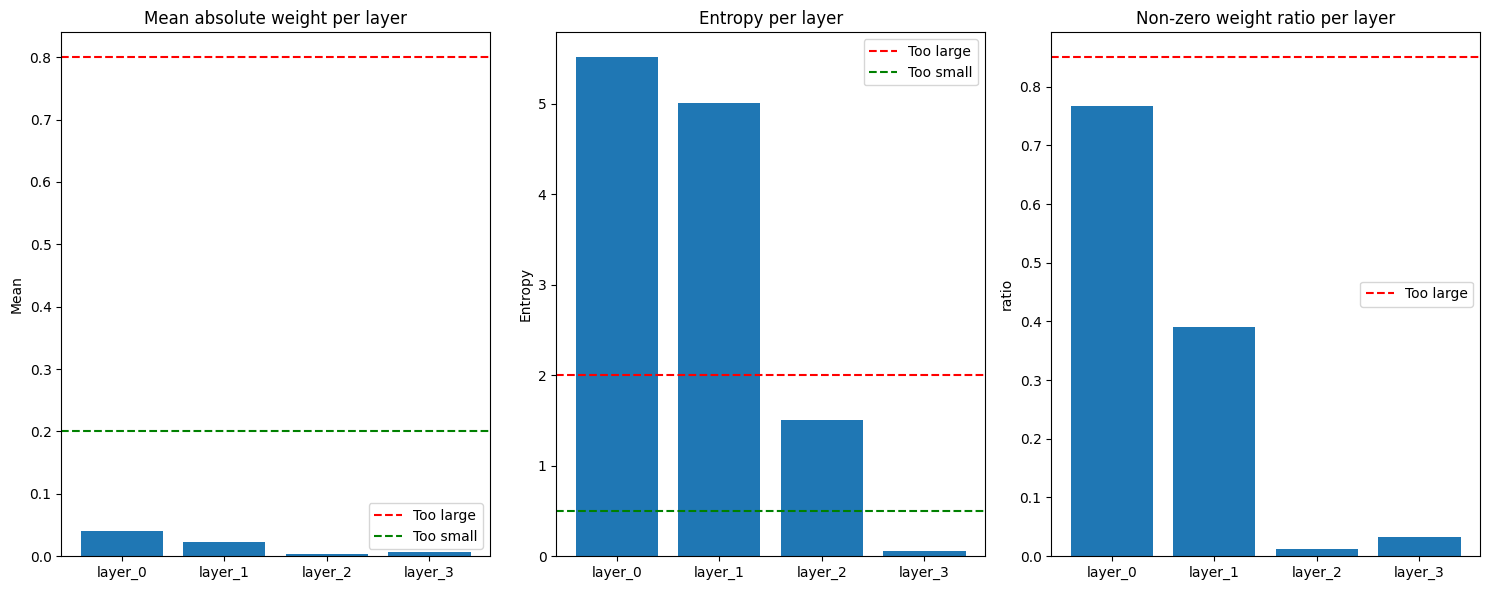

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.2079
Epoch 75/100 Loss:1.1803 Train Acc:0.9984 Train F1:0.9984 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1619
Epoch 76/100 Loss:1.1632 Train Acc:0.9989 Train F1:0.9989 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1649
Epoch 77/100 Loss:1.1656 Train Acc:0.9969 Train F1:0.9969 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 77/100
  Train: Acc:0.9969  F1:0.9969
  Val:   Acc:0.6437  F1:0.6420  Kappa:0.6304  Balanced Acc:0.6507
  Diff:  F1:0.3549 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0164
平均熵值: 2.8597


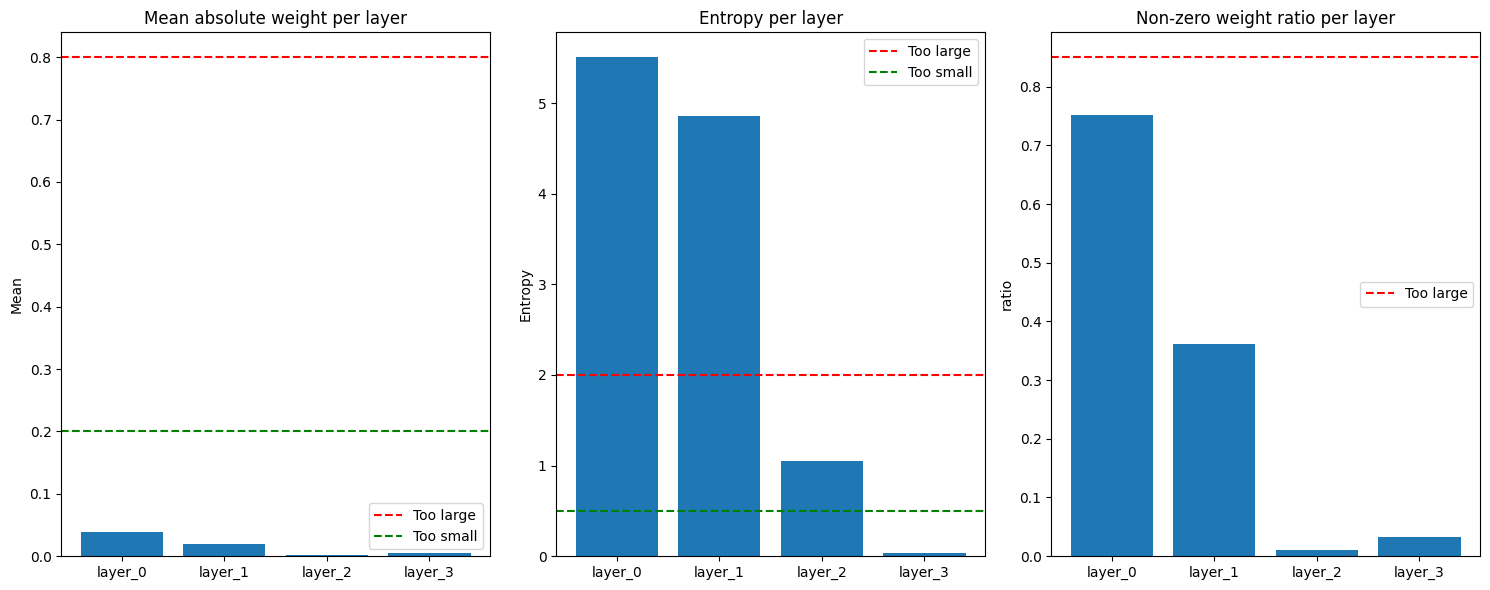

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1440
Epoch 78/100 Loss:1.1585 Train Acc:0.9956 Train F1:0.9956 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1411
Epoch 79/100 Loss:1.1388 Train Acc:0.9990 Train F1:0.9990 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1288
Epoch 80/100 Loss:1.1476 Train Acc:0.9951 Train F1:0.9951 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 80/100
  Train: Acc:0.9951  F1:0.9951
  Val:   Acc:0.6447  F1:0.6433  Kappa:0.6314  Balanced Acc:0.6503
  Diff:  F1:0.3518 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0158
平均熵值: 2.8006


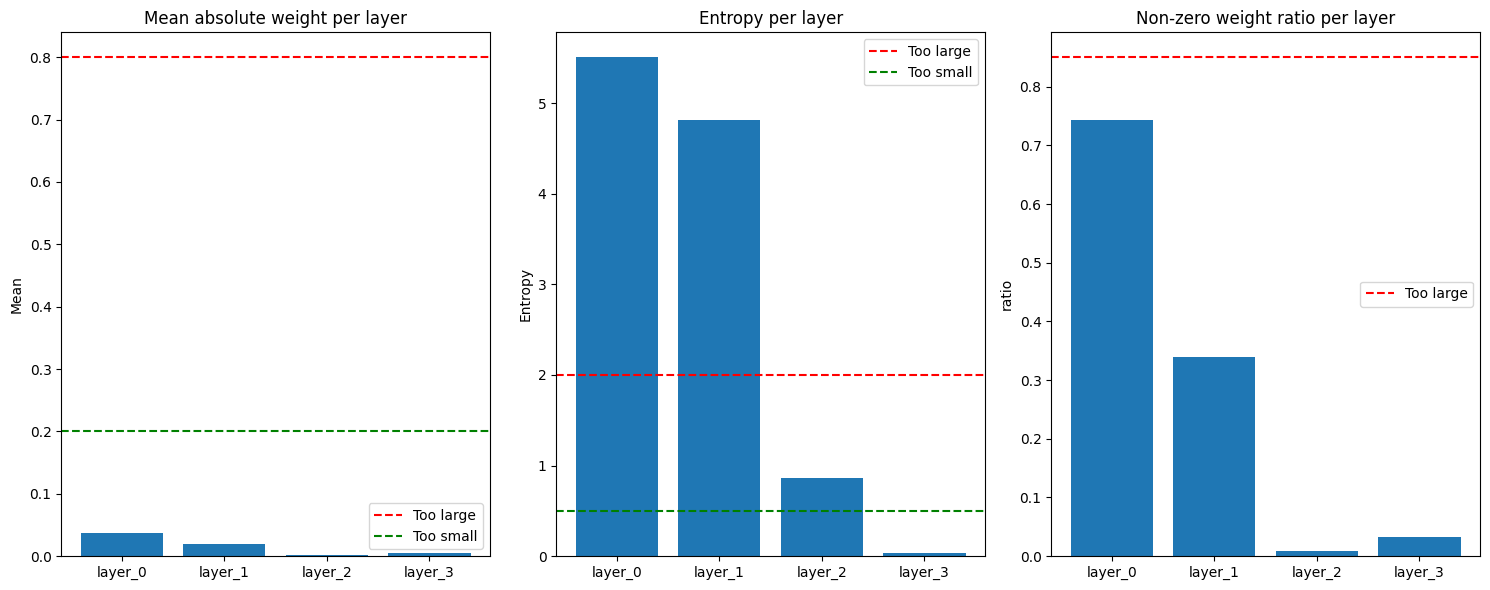

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1204
Epoch 81/100 Loss:1.1254 Train Acc:0.9984 Train F1:0.9984 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1224
Epoch 82/100 Loss:1.1319 Train Acc:0.9953 Train F1:0.9953 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.1190
Epoch 83/100 Loss:1.1110 Train Acc:0.9990 Train F1:0.9990 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 83/100
  Train: Acc:0.9990  F1:0.9990
  Val:   Acc:0.6435  F1:0.6418  Kappa:0.6302  Balanced Acc:0.6503
  Diff:  F1:0.3572 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0152
平均熵值: 2.7460


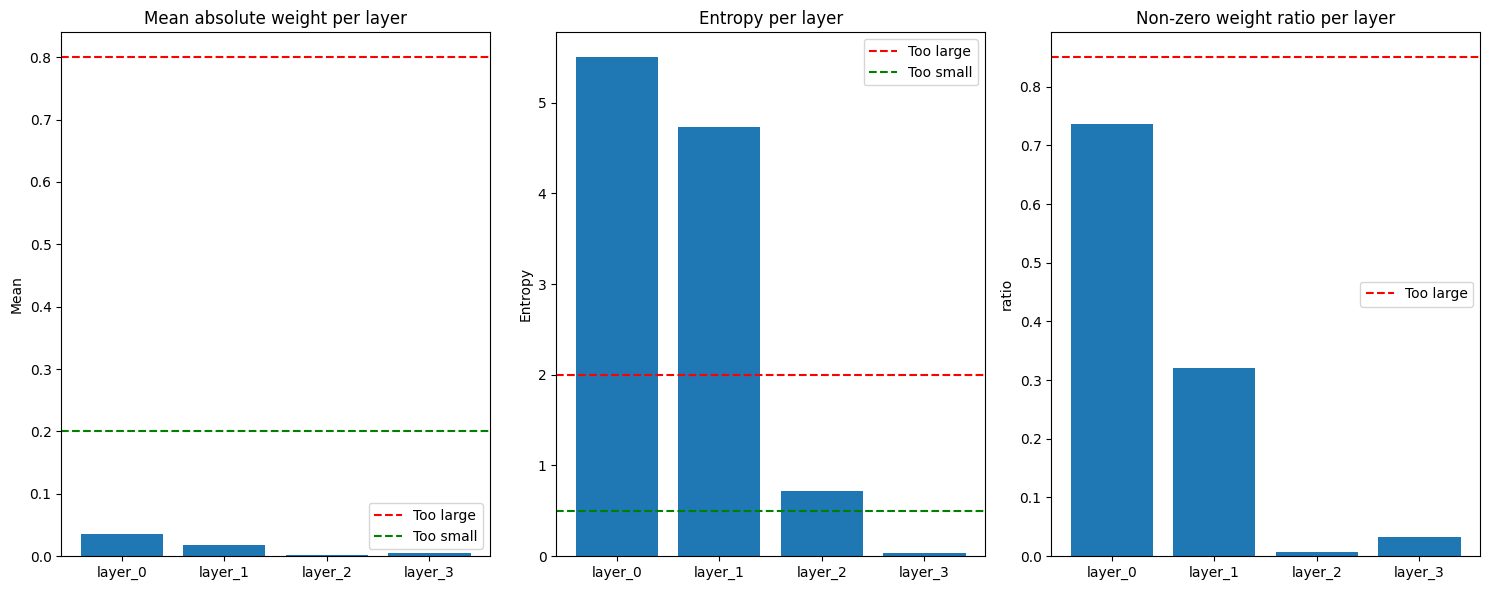

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0986
Epoch 84/100 Loss:1.1254 Train Acc:0.9934 Train F1:0.9934 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0963
Epoch 85/100 Loss:1.0953 Train Acc:0.9994 Train F1:0.9994 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0848
Epoch 86/100 Loss:1.1141 Train Acc:0.9927 Train F1:0.9927 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 86/100
  Train: Acc:0.9927  F1:0.9927
  Val:   Acc:0.6438  F1:0.6420  Kappa:0.6305  Balanced Acc:0.6500
  Diff:  F1:0.3507 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0150
平均熵值: 2.7045


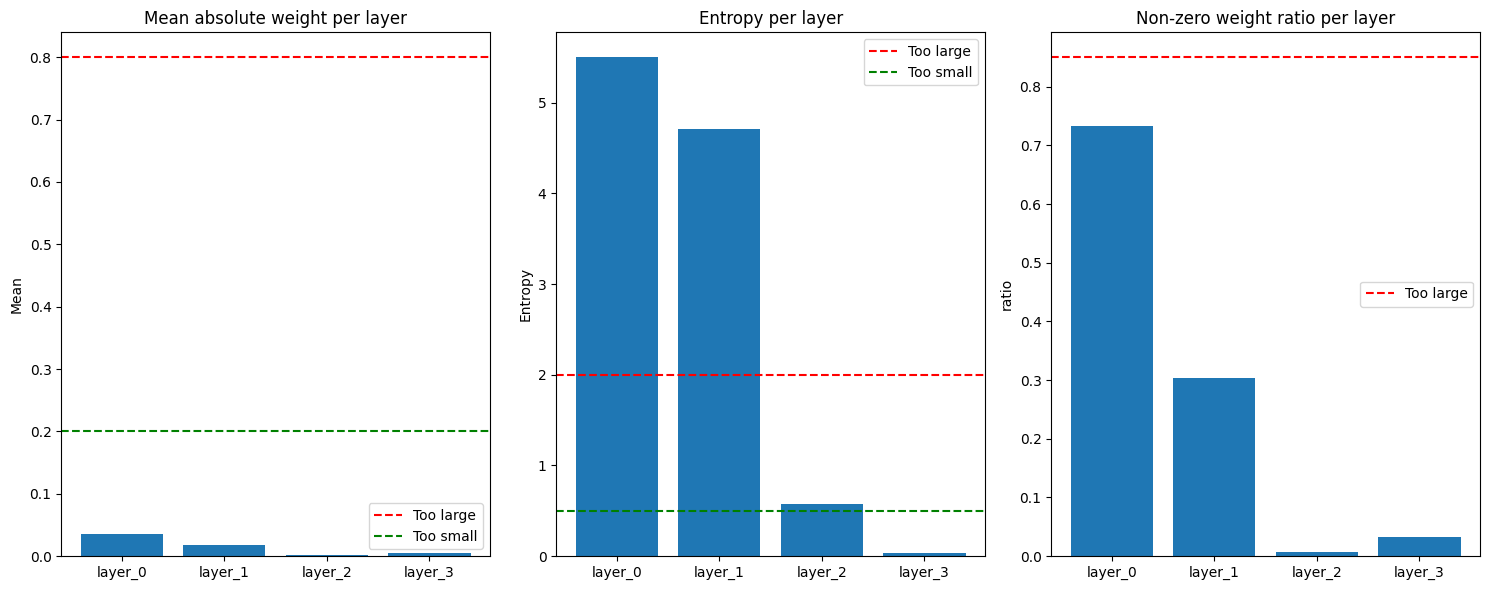

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0820
Epoch 87/100 Loss:1.0844 Train Acc:0.9986 Train F1:0.9986 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0833
Epoch 88/100 Loss:1.0942 Train Acc:0.9947 Train F1:0.9947 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0709
Epoch 89/100 Loss:1.0731 Train Acc:0.9977 Train F1:0.9977 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 89/100
  Train: Acc:0.9977  F1:0.9977
  Val:   Acc:0.6353  F1:0.6322  Kappa:0.6217  Balanced Acc:0.6423
  Diff:  F1:0.3655 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0147
平均熵值: 2.6846


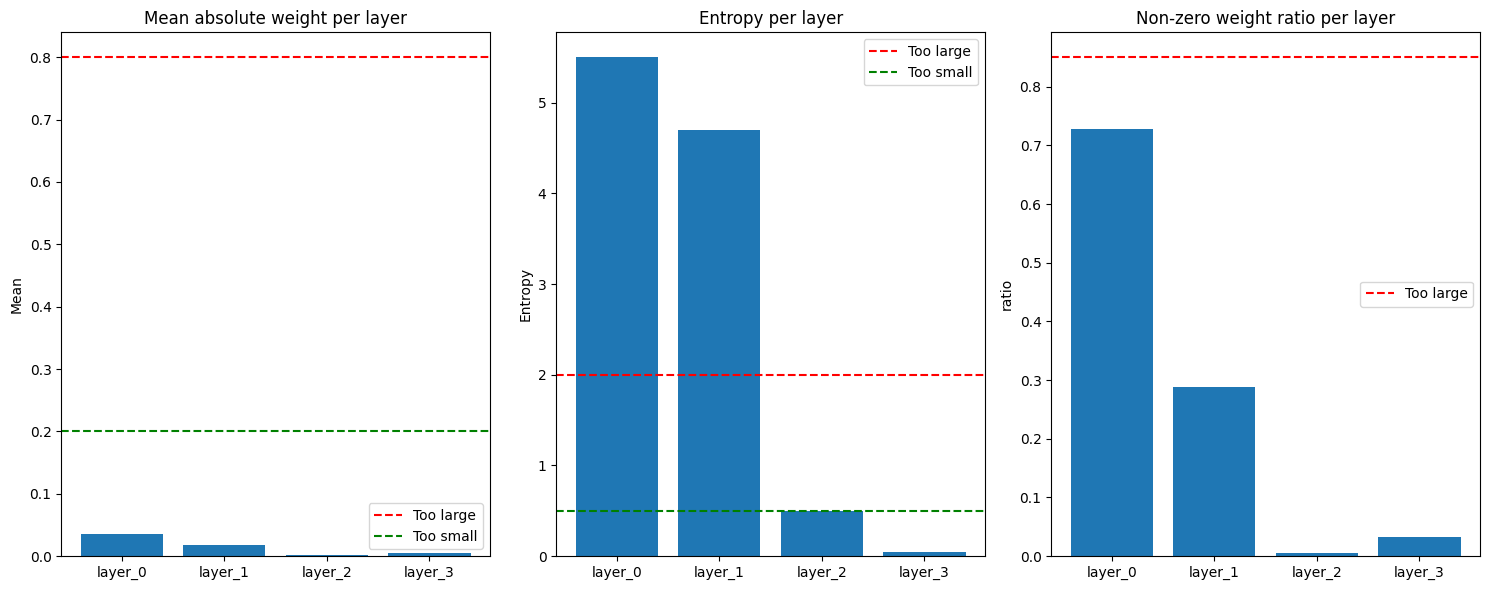

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0740
Epoch 90/100 Loss:1.0802 Train Acc:0.9945 Train F1:0.9945 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0540
Epoch 91/100 Loss:1.0532 Train Acc:0.9986 Train F1:0.9986 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0537
Epoch 92/100 Loss:1.0645 Train Acc:0.9946 Train F1:0.9946 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 92/100
  Train: Acc:0.9946  F1:0.9946
  Val:   Acc:0.6369  F1:0.6345  Kappa:0.6234  Balanced Acc:0.6438
  Diff:  F1:0.3601 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0143
平均熵值: 2.6010


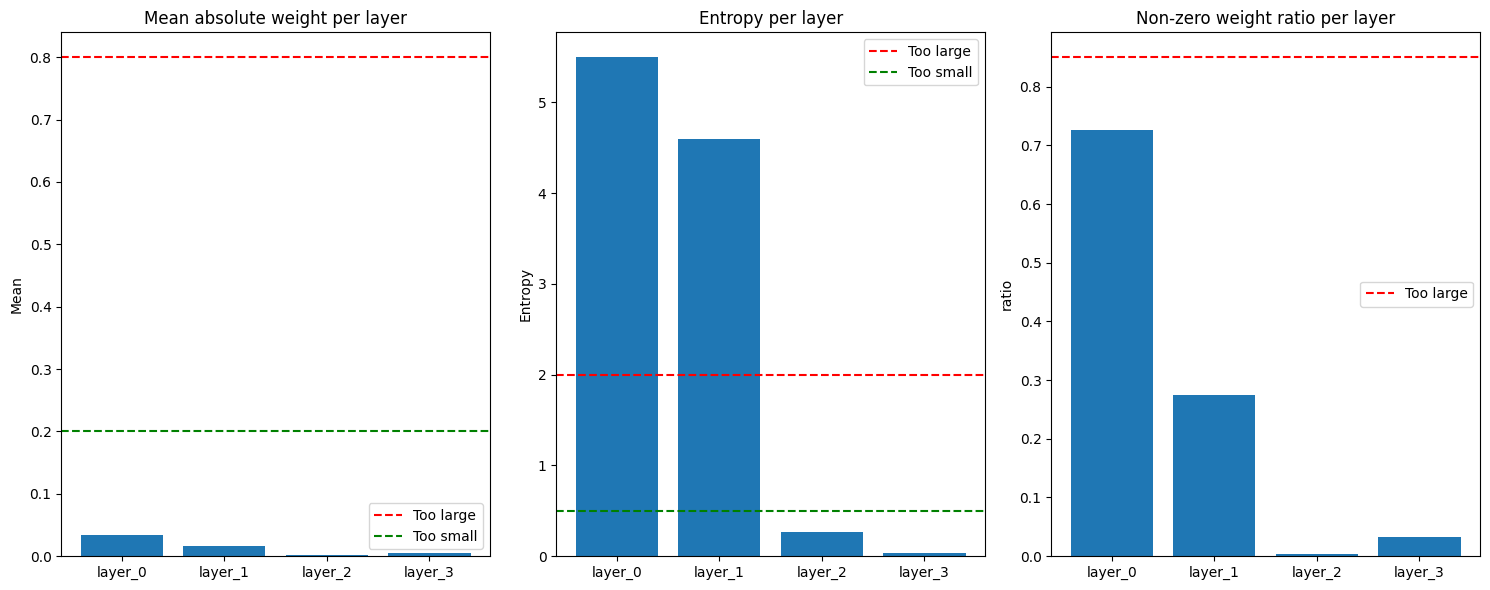

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0405
Epoch 93/100 Loss:1.0563 Train Acc:0.9947 Train F1:0.9947 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0454
Epoch 94/100 Loss:1.0438 Train Acc:0.9969 Train F1:0.9969 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0340
Epoch 95/100 Loss:1.0465 Train Acc:0.9953 Train F1:0.9953 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 95/100
  Train: Acc:0.9953  F1:0.9953
  Val:   Acc:0.6354  F1:0.6329  Kappa:0.6219  Balanced Acc:0.6441
  Diff:  F1:0.3623 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0142
平均熵值: 2.5797


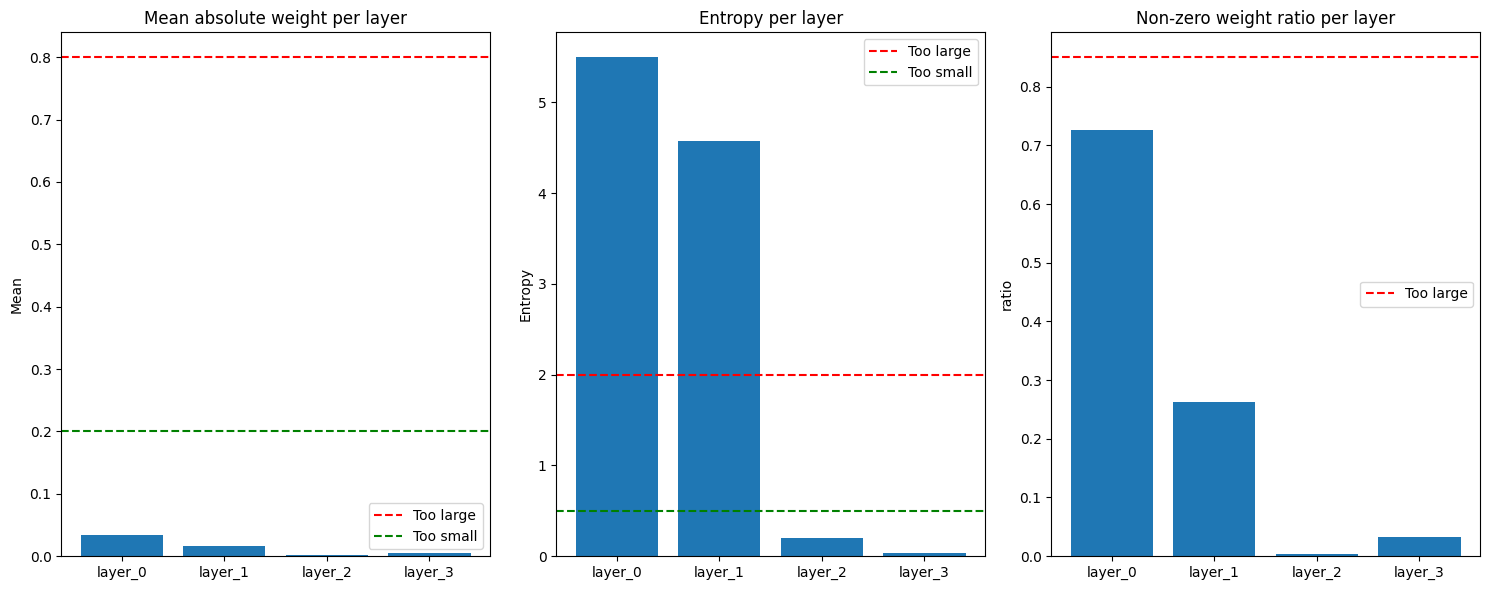

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0320
Epoch 96/100 Loss:1.0360 Train Acc:0.9971 Train F1:0.9971 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0303
Epoch 97/100 Loss:1.0458 Train Acc:0.9945 Train F1:0.9945 LR:0.000130


  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0217
Epoch 98/100 Loss:1.0418 Train Acc:0.9945 Train F1:0.9945 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 98/100
  Train: Acc:0.9945  F1:0.9945
  Val:   Acc:0.6338  F1:0.6325  Kappa:0.6201  Balanced Acc:0.6397
  Diff:  F1:0.3619 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0141
平均熵值: 2.5776


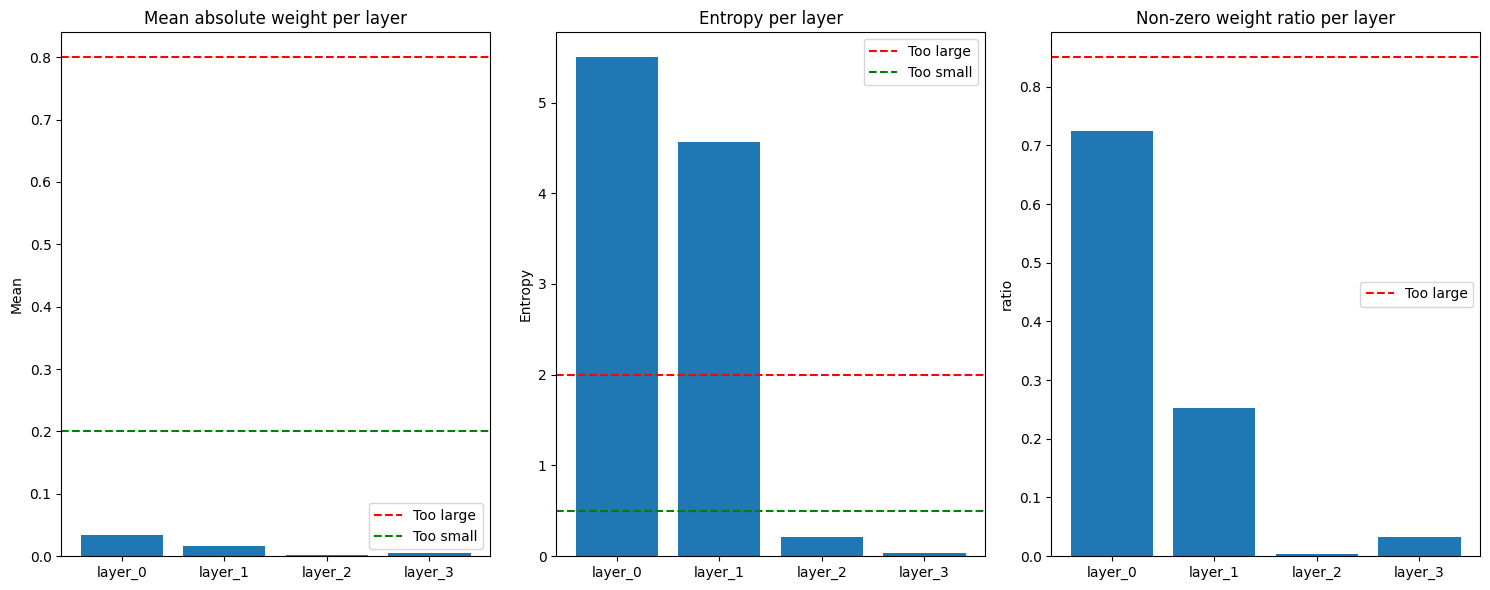

  0%|          | 0/1172 [00:00<?, ?it/s]

  正则化损失: 1.0312
Epoch 99/100 Loss:1.0238 Train Acc:0.9988 Train F1:0.9988 LR:0.000130


  0%|          | 0/3512 [00:00<?, ?it/s]

Epoch 99/100
  Train: Acc:0.9988  F1:0.9988
  Val:   Acc:0.6404  F1:0.6386  Kappa:0.6270  Balanced Acc:0.6472
  Diff:  F1:0.3602 (Training-Validation)

模型复杂度指标:
平均权重绝对值: 0.0137
平均熵值: 2.5289
Training stopped at epoch 99
Training time: 2440.50 seconds
最佳模型 (f1_macro=0.6515): epoch_50_acc_0.6531_f1_0.6515.pth
在测试集上评估最佳模型...


评估中:   0%|          | 0/3512 [00:00<?, ?it/s]

ValueError: Number of classes, 29, does not match size of target_names, 30. Try specifying the labels parameter

In [19]:
# 定义数据目录路径
DATA_DIRS = {
    'train_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/train",
    'test_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/test",
    'val_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val"
}

# 选择30个类别作为子集
SELECTED_CLASSES = select_subset_classes(DATA_DIRS, num_classes=NUM_CLASS, min_samples=1000)

# 载入多分类数据集（只加载选定的类别）
dataset_dict = load_subset_multiclass_data(
    DATA_DIRS, 
    SELECTED_CLASSES,
    apply_pca_flag=APPLY_PCA, 
    n_components=N_PCA, 
    norm=NORM,
    balance_train=BALANCE_TRAIN,  
    target_samples_per_class=TARGET_SAMPLES,
    augmenter=augmenter  # 使用选择的增强器
)

# 保存原始类别和新的映射关系，以便后期分析
class_mapping = {i: original_id for i, original_id in enumerate(dataset_dict['valid_classes'])}
with open(os.path.join(SAVE_PATH, 'class_mapping.json'), 'w') as f:
    json.dump(class_mapping, f, indent=4)

# 保存PCA模型的引用
pca_model = dataset_dict.get('pca_model')

# 创建训练、测试和验证数据集
train_dataset = BrainVoxelDataset(dataset_dict['train_samples'], dataset_dict['train_labels'])
test_dataset = BrainVoxelDataset(dataset_dict['test_samples'], dataset_dict['test_labels'])
val_dataset = BrainVoxelDataset(dataset_dict['val_samples'], dataset_dict['val_labels'])

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 设置计算设备
device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 创建模型
feature_dim = dataset_dict['feature_dim']
model = BrainVoxelKAN(feature_dim, HIDDEN_LAYERS, NUM_CLASS, FIXED_GRID).to(device)

# 打印模型结构
summary(model)

# 计算类别权重并定义损失函数
class_weights = calculate_class_weights(dataset_dict['train_labels'], NUM_CLASS)
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)  # 忽略背景像素

# 定义优化器
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# 临时去除L2正则化
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=0.0)



# 配置学习率调度器
lr_scheduler = None
if USE_LR_SCHEDULER:
    if LR_SCHEDULER_TYPE == 'multistep':
        lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=LR_MILESTONES, gamma=LR_GAMMA)
    elif LR_SCHEDULER_TYPE == 'cosine':
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCH, eta_min=LR * 0.01)
    elif LR_SCHEDULER_TYPE == 'plateau':
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=LR_GAMMA, patience=5, verbose=True)
    
    print(f"Using {LR_SCHEDULER_TYPE} learning rate scheduler")
    if LR_SCHEDULER_TYPE == 'multistep':
        print(f"Milestones: {LR_MILESTONES}, Gamma: {LR_GAMMA}")

# 保存配置到文件
config_dict = {
    'MODEL_NAME': MODEL_NAME,
    'DATASET': DATASET,
    'APPLY_PCA': APPLY_PCA,
    'N_PCA': N_PCA,
    'NORM': NORM,
    'EPOCH': EPOCH,
    'VAL_EPOCH': VAL_EPOCH,
    'LR': LR,
    'WEIGHT_DECAY': WEIGHT_DECAY,
    'BATCH_SIZE': BATCH_SIZE,
    'USE_LR_SCHEDULER': USE_LR_SCHEDULER,
    'LR_SCHEDULER_TYPE': LR_SCHEDULER_TYPE,
    'LR_MILESTONES': LR_MILESTONES,
    'LR_GAMMA': LR_GAMMA,
    'BALANCE_TRAIN': BALANCE_TRAIN,
    'TARGET_SAMPLES': TARGET_SAMPLES,
    'NUM_CLASS': NUM_CLASS,
    'FIXED_GRID': FIXED_GRID,
    'feature_dim': feature_dim,
    'HIDDEN_LAYERS': HIDDEN_LAYERS,  # 添加隐藏层配置
    'USE_KAN_REGULARIZATION': USE_KAN_REGULARIZATION,
    'LAMBDA_L1': LAMBDA_L1,
    'LAMBDA_ENTROPY': LAMBDA_ENTROPY
}

with open(os.path.join(SAVE_PATH, 'config.json'), 'w') as f:
    json.dump(config_dict, f, indent=4)

# 训练模型
training_results = train_brain_voxel_kan_multiclass(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCH,
    val_epoch=VAL_EPOCH,
    save_path=SAVE_PATH,
    lr_scheduler=lr_scheduler
)

# 可视化训练过程
# visualize_training_with_lr(training_results, SAVE_PATH, LR_MILESTONES)


最佳模型 (f1_macro=0.6515): epoch_50_acc_0.6531_f1_0.6515.pth
在测试集上评估最佳模型...


评估中:   0%|          | 0/3512 [00:00<?, ?it/s]

测试集准确率: 0.6520
测试集平衡准确率: 0.6595
测试集宏平均F1: 0.6503
测试集加权F1: 0.6514
测试集Kappa系数: 0.6391

分类报告:
              precision    recall  f1-score   support

           0       0.53      0.43      0.47     46769
           1       0.53      0.42      0.46     44183
           2       0.94      0.93      0.94     41538
           3       0.74      0.64      0.68     40613
           4       0.91      0.89      0.90     37242
           5       0.75      0.71      0.73     34578
           6       0.84      0.83      0.83     34117
           7       0.70      0.66      0.68     33804
           8       0.67      0.59      0.63     33218
           9       0.57      0.54      0.56     32043
          10       0.65      0.65      0.65     31790
          11       0.70      0.66      0.68     31730
          12       0.62      0.56      0.59     30276
          13       0.60      0.61      0.61     30067
          14       0.49      0.59      0.53     29963
          15       0.63      0.55      0.59 

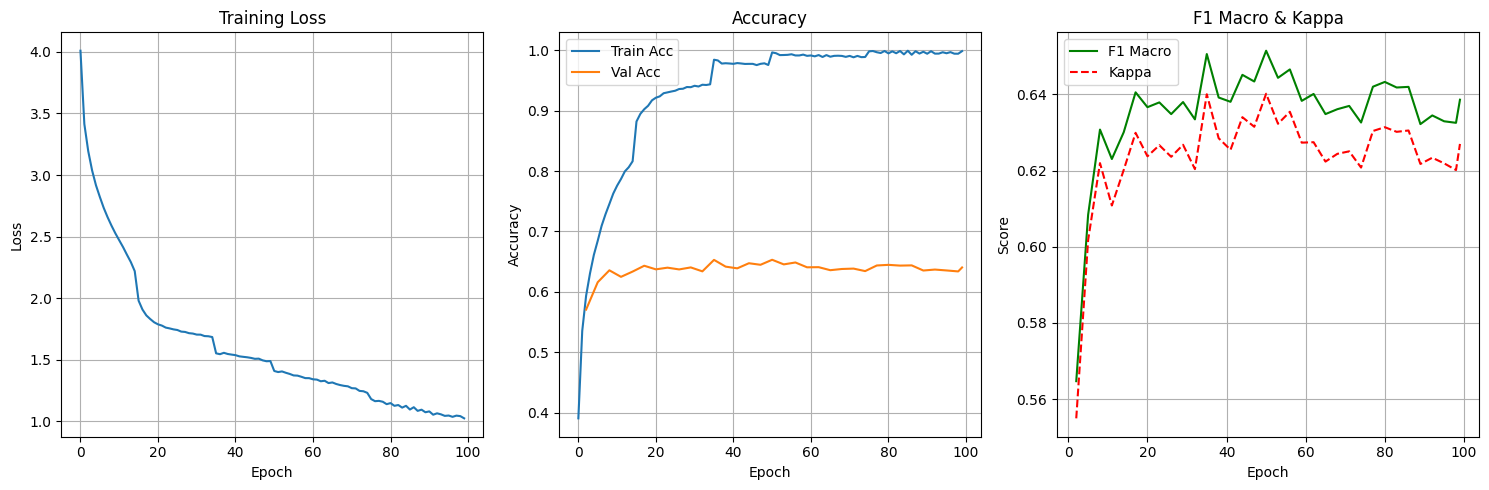

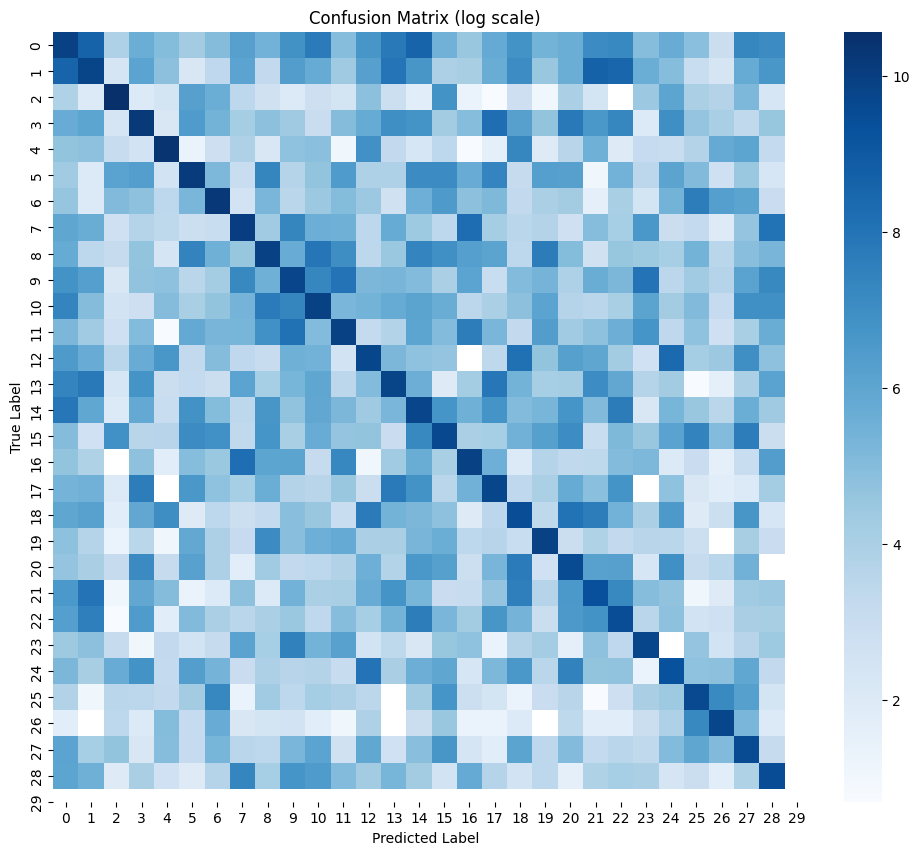

测试报告已保存至: ./Results/BrainVoxel_30Class/BrainVoxel_Subset/test_report_multiclass.txt
表现最好的类别: 2, F1分数: 0.9367
表现最差的类别: 1, F1分数: 0.4647


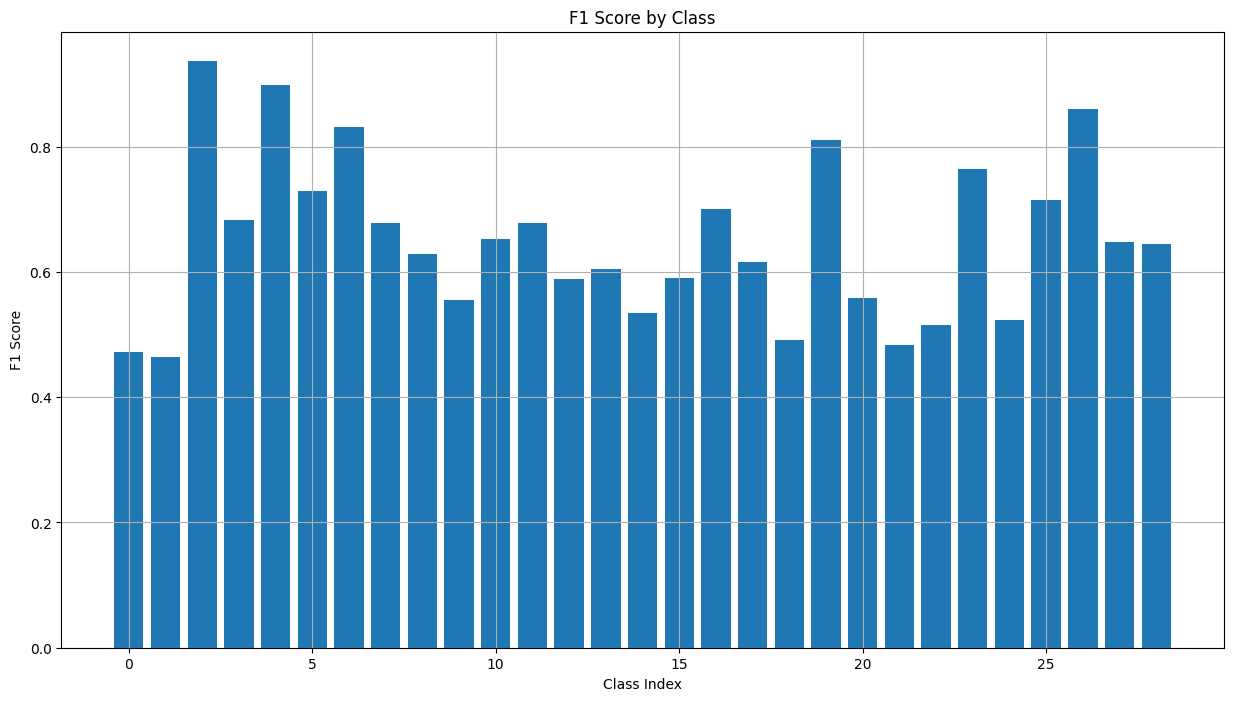

In [22]:

# 获取最佳模型
best_model_path = get_best_model(
    training_results['val_f1_macro_list'],  # 使用宏平均F1作为选择标准
    training_results['val_epoch_list'],
    SAVE_PATH,
    metric='f1_macro'  # 指定使用F1宏平均作为指标
)

# 加载最佳模型
best_model = BrainVoxelKAN(feature_dim, HIDDEN_LAYERS, NUM_CLASS, FIXED_GRID).to(device)
best_model.load_state_dict(torch.load(best_model_path, weights_only=False)['state_dict'])


# 在测试集上评估
print("在测试集上评估最佳模型...")
test_results = evaluate_model_multiclass(best_model, test_loader, device)

# 打印主要评估指标
print(f"测试集准确率: {test_results['accuracy']:.4f}")
print(f"测试集平衡准确率: {test_results['balanced_accuracy']:.4f}")
print(f"测试集宏平均F1: {test_results['f1_macro']:.4f}")
print(f"测试集加权F1: {test_results['f1_weighted']:.4f}")
print(f"测试集Kappa系数: {test_results['kappa']:.4f}")

# 打印分类报告
print("\n分类报告:")
print(test_results['report'])

# 保存训练过程图表
plt.figure(figsize=(15, 5))

# 绘制损失曲线
plt.subplot(1, 3, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 绘制准确率曲线
plt.subplot(1, 3, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 绘制F1和Kappa曲线
plt.subplot(1, 3, 3)
plt.plot(training_results['val_epoch_list'], training_results['val_f1_macro_list'], 'g-', label='F1 Macro')
plt.plot(training_results['val_epoch_list'], training_results['val_kappa_list'], 'r--', label='Kappa')
plt.title('F1 Macro & Kappa')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_curves_multiclass.png'))
plt.show()

# 可视化混淆矩阵 (对于多分类)
plt.figure(figsize=(12, 10))
conf_matrix = test_results['confusion_matrix']
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_matrix_vis = np.log1p(conf_matrix)  # log(1+x)以处理零值
mask = conf_matrix == 0
sns.heatmap(conf_matrix_vis, annot=False, fmt='d', cmap='Blues', 
          xticklabels=range(NUM_CLASS), yticklabels=range(NUM_CLASS),
          mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix_multiclass.png'))
plt.show()

# 保存测试结果
test_report = f"""
# 多分类测试报告

## 训练信息
- 训练时间: {training_results['train_time']:.2f} 秒
- 总训练轮数: {len(training_results['loss_list'])}
- 最佳模型: {os.path.basename(best_model_path)}
- 学习率: {LR}
- 批量大小: {BATCH_SIZE}
- 固定网格大小: {FIXED_GRID}

## 性能指标
- 测试集准确率: {test_results['accuracy']:.4f}
- 测试集平衡准确率: {test_results['balanced_accuracy']:.4f}
- 测试集宏平均F1: {test_results['f1_macro']:.4f}
- 测试集加权F1: {test_results['f1_weighted']:.4f}
- 测试集Kappa系数: {test_results['kappa']:.4f}

## 分类报告
{test_results['report']}
"""

with open(os.path.join(SAVE_PATH, 'test_report_multiclass.txt'), 'w') as f:
    f.write(test_report)

print(f"测试报告已保存至: {os.path.join(SAVE_PATH, 'test_report_multiclass.txt')}")

# 分析类别性能
class_f1 = test_results['class_f1']
class_precision = test_results['class_precision']
class_recall = test_results['class_recall']

# 找出表现最好和最差的类别
best_class = np.argmax(class_f1)
worst_class = np.argmin(class_f1)

print(f"表现最好的类别: {best_class}, F1分数: {class_f1[best_class]:.4f}")
print(f"表现最差的类别: {worst_class}, F1分数: {class_f1[worst_class]:.4f}")

# 绘制每个类别的F1分数分布
plt.figure(figsize=(15, 8))
plt.bar(range(len(class_f1)), class_f1)
plt.xlabel('Class Index')
plt.ylabel('F1 Score')
plt.title('F1 Score by Class')
plt.grid(True)
plt.savefig(os.path.join(SAVE_PATH, 'class_f1_distribution.png'))
plt.show()

In [23]:
summary(model)

Layer (type:depth-idx)                             Param #
BrainVoxelKAN                                      --
├─FastKAN: 1-1                                     --
│    └─ModuleList: 2-1                             --
│    │    └─FastKANLayer: 3-1                      1,135,798
│    │    └─FastKANLayer: 3-2                      852,748
│    │    └─FastKANLayer: 3-3                      852,748
│    │    └─FastKANLayer: 3-4                      100,394
Total params: 2,941,688
Trainable params: 2,941,640
Non-trainable params: 48

In [24]:
print(model)


BrainVoxelKAN(
  (kan): FastKAN(
    (layers): ModuleList(
      (0): FastKANLayer(
        (layernorm): LayerNorm((341,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=4092, out_features=256, bias=False)
        (base_linear): Linear(in_features=341, out_features=256, bias=True)
      )
      (1-2): 2 x FastKANLayer(
        (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=3072, out_features=256, bias=False)
        (base_linear): Linear(in_features=256, out_features=256, bias=True)
      )
      (3): FastKANLayer(
        (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=3072, out_features=30, bias=False)
        (base_linear): Linear(in_features=256, out_features=30, bias=True)
      )
    )
  )
)


In [25]:
def analyze_kan_model(model, data_samples, save_path=None, apply_pca_flag=True, pca_model=None):
    """
    简单分析KAN模型的特征重要性
    
    参数:
        model: 训练好的KAN模型
        data_samples: 数据样本
        save_path: 保存路径，None表示不保存
        apply_pca_flag: 是否应用了PCA
        pca_model: PCA模型，用于反向解释特征重要性
    """
    # 获取模型输入层的权重
    input_weights = model.kan.layers[0].base_linear.weight.data.cpu().numpy()
    
    # 计算特征的平均绝对权重值（简单的重要性度量）
    feature_importance = np.mean(np.abs(input_weights), axis=0)
    
    # 找出前20个最重要的特征
    top_n = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-top_n:][::-1]
    top_importance = feature_importance[top_indices]
    
    # 可视化特征重要性
    plt.figure(figsize=(12, 8))
    
    if apply_pca_flag:
        feature_names = [f"PC {i+1}" for i in top_indices]
        title = f"Top {top_n} Principal Component Importance"
        
        # 如果有PCA模型，可以尝试显示每个PC的原始特征贡献
        if pca_model is not None:
            plt.figure(figsize=(15, 10))
            # 创建一个额外的图显示PC的组成
            for i, pc_idx in enumerate(top_indices[:5]): # 只显示前5个最重要的PC
                if i < 5: # 限制显示数量
                    plt.subplot(5, 1, i+1)
                    pc_components = pca_model.components_[pc_idx]
                    plt.bar(range(len(pc_components)), pc_components)
                    plt.title(f"PC {pc_idx+1} Component Composition")
                    plt.xlabel('Original Feature Index')
                    plt.ylabel('Weight')
            plt.tight_layout()
            if save_path:
                base_path, ext = os.path.splitext(save_path)
                pc_comp_path = f"{base_path}_pc_composition{ext}"
                plt.savefig(pc_comp_path)
                print(f"保存PC组成图到：{pc_comp_path}")
            plt.figure(figsize=(12, 8)) # 恢复原始图形
    else:
        feature_names = [f"Feature {i+1}" for i in top_indices]
        title = f"Top {top_n} Feature Importance"
    
    plt.barh(range(top_n), top_importance, align='center')
    plt.yticks(range(top_n), feature_names)
    plt.xlabel('Mean Absolute Weight')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
    # 保存特征重要性数据
    importance_data = {
        'feature_index': np.arange(len(feature_importance)),
        'importance': feature_importance,
        'is_pca': apply_pca_flag,
        'pca_model': pca_model if apply_pca_flag else None
    }
    
    return importance_data



在训练集上进行全面评估...


训练集评估:   0%|          | 0/1172 [00:00<?, ?it/s]

训练集准确率: 0.9992
训练集平衡准确率: 0.9992
训练集宏平均F1: 0.9992
训练集加权F1: 0.9992
训练集Kappa系数: 0.9991

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000
           1       1.00      1.00      1.00     10000
           2       1.00      1.00      1.00     10000
           3       1.00      1.00      1.00     10000
           4       1.00      1.00      1.00     10000
           5       1.00      1.00      1.00     10000
           6       1.00      1.00      1.00     10000
           7       0.99      1.00      1.00     10000
           8       1.00      1.00      1.00     10000
           9       1.00      1.00      1.00     10000
          10       1.00      1.00      1.00     10000
          11       1.00      1.00      1.00     10000
          12       1.00      1.00      1.00     10000
          13       1.00      1.00      1.00     10000
          14       1.00      1.00      1.00     10000
          15       1.00      1.00      1.00 

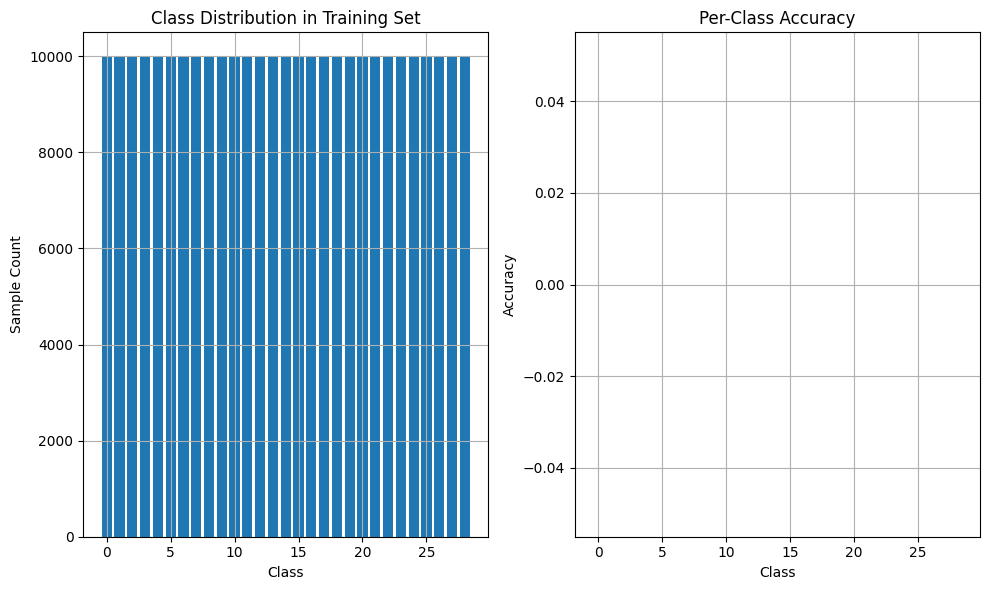

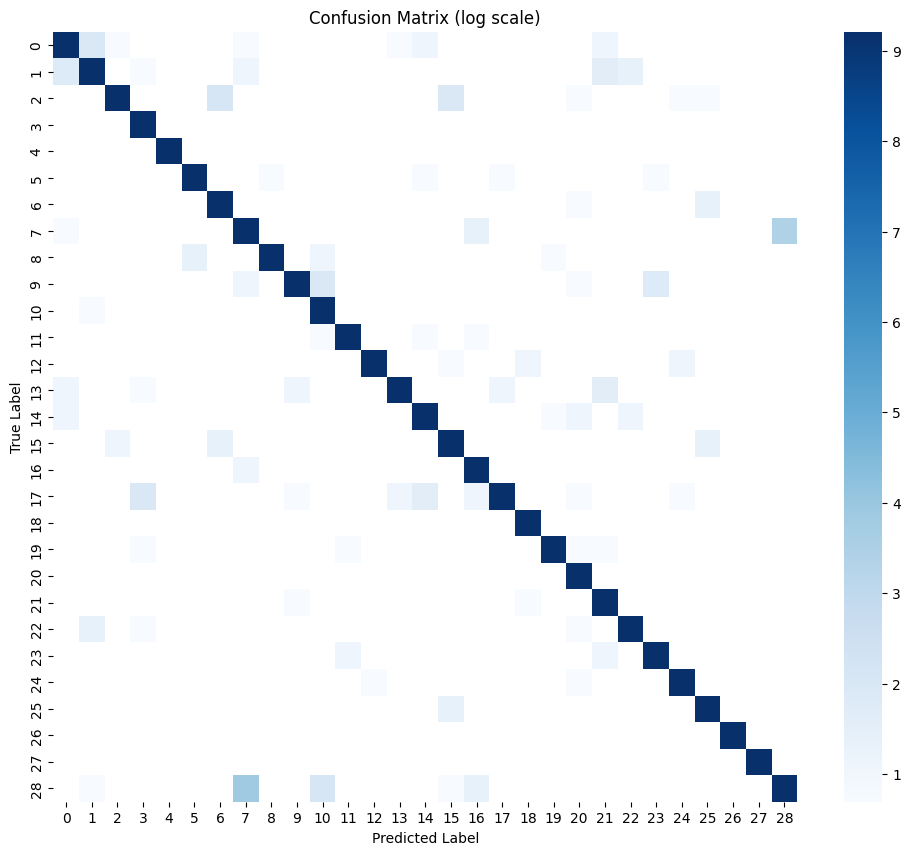

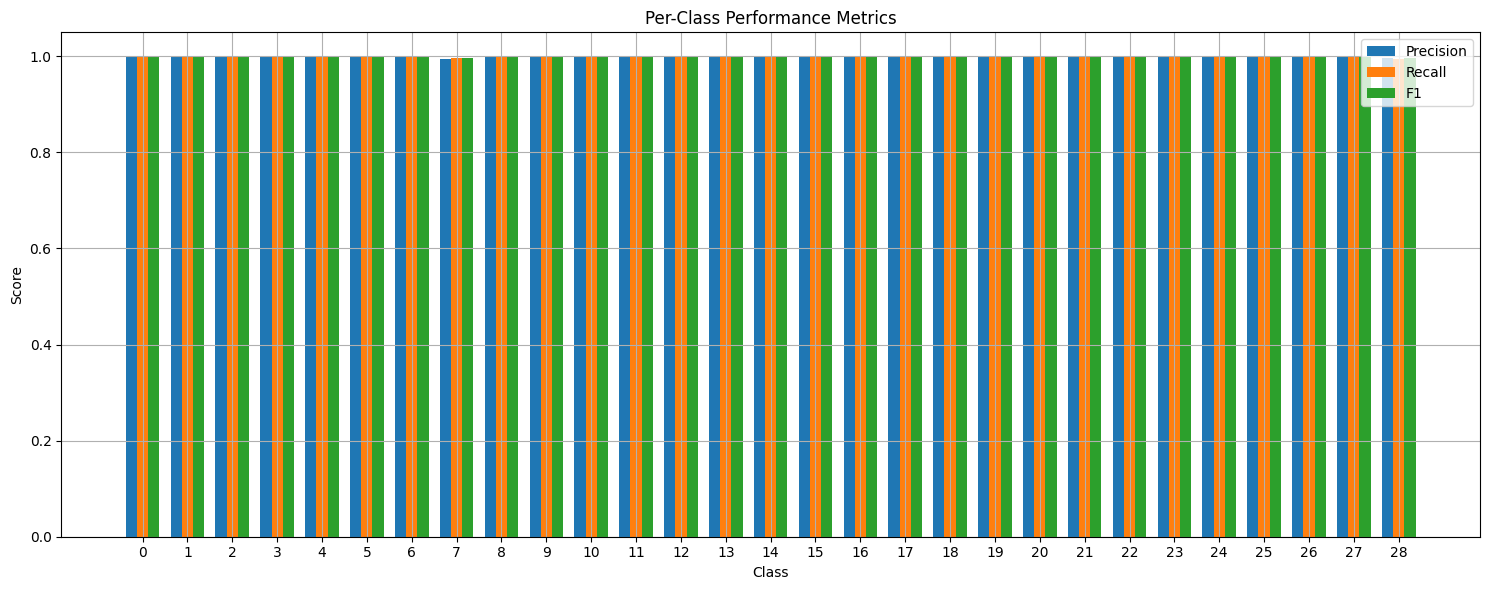

训练集全面评估报告已保存至: ./Results/BrainVoxel_30Class/BrainVoxel_Subset/training_set_complete_report_multiclass.txt


In [26]:
# 在训练集上进行全面评估
print("在训练集上进行全面评估...")
model.eval()
train_preds = []
train_targets = []
train_probs_all = []  # 所有类别的概率

# 使用train_loader直接评估
with torch.no_grad():
    for data, target in tqdm(train_loader, desc="训练集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        train_preds.extend(preds[valid_mask].cpu().numpy())
        train_targets.extend(target[valid_mask].cpu().numpy())
        train_probs_all.extend(probs[valid_mask].cpu().numpy())  # 保存所有类别的概率

# 计算各种评估指标
train_accuracy = accuracy_score(train_targets, train_preds)
train_balanced_acc = balanced_accuracy_score(train_targets, train_preds)
train_f1_macro = f1_score(train_targets, train_preds, average='macro')
train_f1_weighted = f1_score(train_targets, train_preds, average='weighted')
train_kappa = cohen_kappa_score(train_targets, train_preds)

train_report = classification_report(train_targets, train_preds)
train_conf_matrix = confusion_matrix(train_targets, train_preds)

# 打印主要评估指标
print(f"训练集准确率: {train_accuracy:.4f}")
print(f"训练集平衡准确率: {train_balanced_acc:.4f}")
print(f"训练集宏平均F1: {train_f1_macro:.4f}")
print(f"训练集加权F1: {train_f1_weighted:.4f}")
print(f"训练集Kappa系数: {train_kappa:.4f}")

print("\n分类报告:")
print(train_report)
print("\n混淆矩阵:")
print(train_conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(train_targets)
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Training Set')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(train_targets):
        mask = train_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(np.array(train_preds)[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_set_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(train_conf_matrix)  # log(1+x)以处理零值
mask = train_conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'training_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
class_precision = precision_score(train_targets, train_preds, average=None, zero_division=0)
class_recall = recall_score(train_targets, train_preds, average=None, zero_division=0)
class_f1 = f1_score(train_targets, train_preds, average=None, zero_division=0)

# 可视化类别性能
plt.figure(figsize=(15, 6))
# 只选择有实际样本的类别
valid_classes = np.where(class_counts > 0)[0]
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision[valid_classes], width, label='Precision')
plt.bar(x, class_recall[valid_classes], width, label='Recall')
plt.bar(x + width, class_f1[valid_classes], width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_set_class_performance.png'))
plt.show()

# 保存训练集评估报告
train_report_complete = f"""
# 训练集多分类全面评估报告

## 性能指标
- 准确率: {train_accuracy:.4f}
- 平衡准确率: {train_balanced_acc:.4f}
- 宏平均F1: {train_f1_macro:.4f}
- 加权F1: {train_f1_weighted:.4f}
- Kappa系数: {train_kappa:.4f}

## 样本分布
- 总样本数: {len(train_targets)}
- 类别数量: {len(np.unique(train_targets))}
- 样本最多的类别: {np.argmax(class_counts)} ({np.max(class_counts)} 个样本)
- 样本最少的类别: {np.argmin(class_counts[class_counts > 0])} ({np.min(class_counts[class_counts > 0])} 个样本)

## 类别性能分析
"""

# 添加类别性能表格
train_report_complete += """
| 类别 | 样本数 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|--------|
"""

for cls in valid_classes:
    train_report_complete += f"| {cls} | {class_counts[cls]} | {class_precision[cls]:.4f} | {class_recall[cls]:.4f} | {class_f1[cls]:.4f} |\n"

train_report_complete += f"""
## 分类报告
{train_report}

## 性能分析
- 表现最好的类别: {valid_classes[np.argmax(class_f1[valid_classes])]} (F1分数: {np.max(class_f1[valid_classes]):.4f})
- 表现最差的类别: {valid_classes[np.argmin(class_f1[valid_classes])]} (F1分数: {np.min(class_f1[valid_classes]):.4f})
- 类别间性能差异: {np.max(class_f1[valid_classes]) - np.min(class_f1[valid_classes]):.4f}
"""

with open(os.path.join(SAVE_PATH, 'training_set_complete_report_multiclass.txt'), 'w') as f:
    f.write(train_report_complete)

print(f"训练集全面评估报告已保存至: {os.path.join(SAVE_PATH, 'training_set_complete_report_multiclass.txt')}")

在测试集上进行多分类全面评估...


测试集评估:   0%|          | 0/3512 [00:00<?, ?it/s]

测试集准确率: 0.6389
测试集平衡准确率: 0.6458
测试集宏平均F1: 0.6371
测试集加权F1: 0.6387
测试集Kappa系数: 0.6254
测试集样本总数: 847642

类别分布:
类别 0: 46769 个样本
类别 1: 44183 个样本
类别 2: 41538 个样本
类别 3: 40613 个样本
类别 4: 37242 个样本
类别 5: 34578 个样本
类别 6: 34117 个样本
类别 7: 33804 个样本
类别 8: 33218 个样本
类别 9: 32043 个样本
类别 10: 31790 个样本
类别 11: 31730 个样本
类别 12: 30276 个样本
类别 13: 30067 个样本
类别 14: 29963 个样本
类别 15: 28617 个样本
类别 16: 28284 个样本
类别 17: 26043 个样本
类别 18: 25461 个样本
类别 19: 23180 个样本
类别 20: 22370 个样本
类别 21: 22230 个样本
类别 22: 22130 个样本
类别 23: 21104 个样本
类别 24: 20685 个样本
类别 25: 19749 个样本
类别 26: 19024 个样本
类别 27: 18452 个样本
类别 28: 18382 个样本

分类报告:
              precision    recall  f1-score   support

           0       0.52      0.41      0.46     46769
           1       0.51      0.40      0.45     44183
           2       0.95      0.91      0.93     41538
           3       0.70      0.65      0.68     40613
           4       0.91      0.87      0.89     37242
           5       0.74      0.70      0.72     34578
           6       0.85 

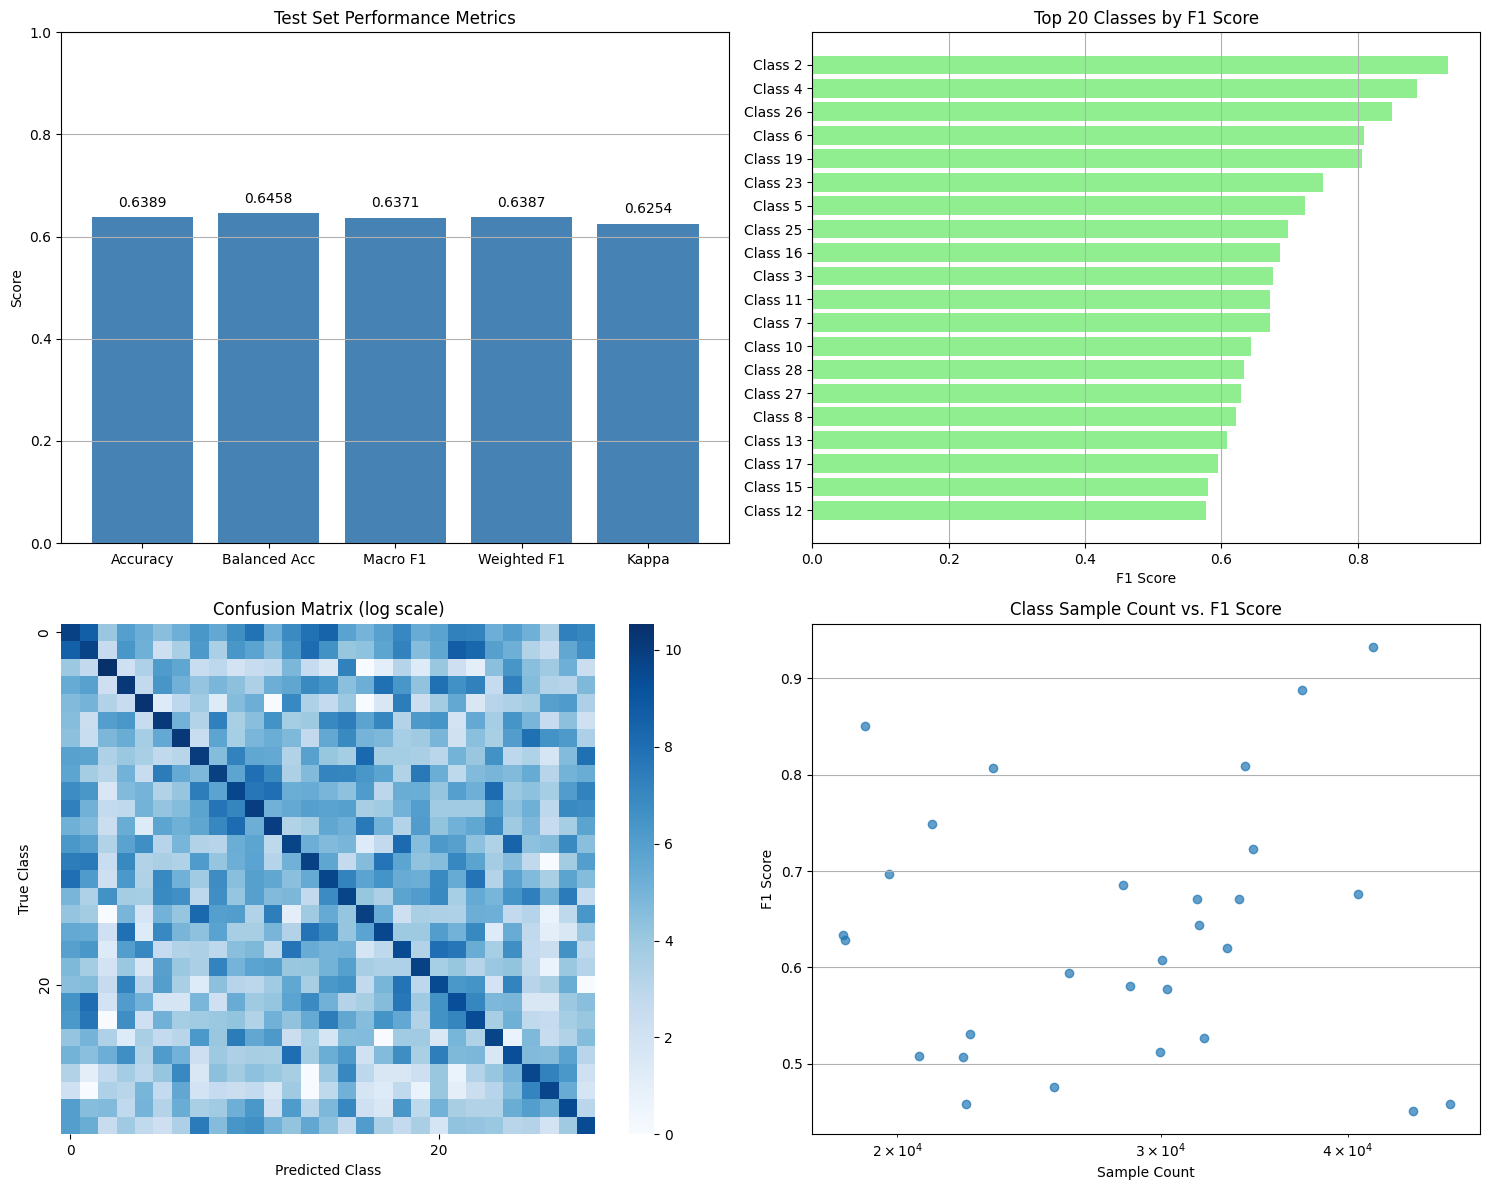

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 30 and the array at index 1 has size 29

In [28]:
# 在测试集上进行全面评估
print("在测试集上进行多分类全面评估...")
model.eval()
test_preds = []
test_probs = []
test_targets = []

# 使用test_loader直接评估
with torch.no_grad():
    for data, target in tqdm(test_loader, desc="测试集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只收集有效标签（忽略-1）
        valid_mask = target != -1
        test_preds.extend(preds[valid_mask].cpu().numpy())
        test_probs.extend(probs[valid_mask].cpu().numpy())  # 保存所有类别的概率
        test_targets.extend(target[valid_mask].cpu().numpy())

# 计算多分类评估指标
test_accuracy = accuracy_score(test_targets, test_preds)
test_balanced_acc = balanced_accuracy_score(test_targets, test_preds)
test_f1_macro = f1_score(test_targets, test_preds, average='macro')
test_f1_weighted = f1_score(test_targets, test_preds, average='weighted')
test_kappa = cohen_kappa_score(test_targets, test_preds)

# 为每个类别计算指标
test_class_precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
test_class_recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
test_class_f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

# 生成分类报告 - 标签名称使用Class 0, Class 1等
class_names = [f"Class {i}" for i in range(NUM_CLASS)]
test_report = classification_report(test_targets, test_preds)
test_conf_matrix = confusion_matrix(test_targets, test_preds)

# 打印主要评估指标
print(f"测试集准确率: {test_accuracy:.4f}")
print(f"测试集平衡准确率: {test_balanced_acc:.4f}")
print(f"测试集宏平均F1: {test_f1_macro:.4f}")
print(f"测试集加权F1: {test_f1_weighted:.4f}")
print(f"测试集Kappa系数: {test_kappa:.4f}")
print(f"测试集样本总数: {len(test_targets)}")

# 统计各类别的样本数
print("\n类别分布:")
unique_classes, class_counts = np.unique(test_targets, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"类别 {cls}: {count} 个样本")

print("\n分类报告:")
print(test_report)

# 创建更适合多分类的可视化
plt.figure(figsize=(15, 12))

# 1. 准确率和F1分数
plt.subplot(2, 2, 1)
metrics = ['Accuracy', 'Balanced Acc', 'Macro F1', 'Weighted F1', 'Kappa']
values = [test_accuracy, test_balanced_acc, test_f1_macro, test_f1_weighted, test_kappa]
plt.bar(metrics, values, color='steelblue')
plt.ylabel('Score')
plt.title('Test Set Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')

# 2. 类别F1分数分布 - 只显示前20个类别，避免过于拥挤
plt.subplot(2, 2, 2)
top_k = 20  # 显示前20个类别
sorted_idx = np.argsort(test_class_f1)[-top_k:]  # 获取F1分数最高的top_k个类别
plt.barh([f"Class {i}" for i in sorted_idx], test_class_f1[sorted_idx], color='lightgreen')
plt.xlabel('F1 Score')
plt.title(f'Top {top_k} Classes by F1 Score')
plt.grid(axis='x')

# 3. 混淆矩阵热图 - 采用对数变换来更好地可视化
plt.subplot(2, 2, 3)
conf_matrix_log = np.log1p(test_conf_matrix)  # log(1+x) 处理
sns.heatmap(conf_matrix_log, cmap='Blues', fmt='', xticklabels=20, yticklabels=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (log scale)')

# 4. 类别样本数量与F1分数关系
plt.subplot(2, 2, 4)
class_indices = np.arange(len(test_class_f1))
plt.scatter(np.bincount(test_targets, minlength=NUM_CLASS)[class_indices], 
            test_class_f1, alpha=0.7)
plt.xlabel('Sample Count')
plt.ylabel('F1 Score')
plt.title('Class Sample Count vs. F1 Score')
plt.grid(True)
plt.xscale('log')  # 对样本数使用对数刻度，更好地可视化

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'test_set_multiclass_performance.png'))
plt.show()

# 保存测试集评估报告
test_report_complete = f"""
# 测试集多分类评估报告 (102类)

## 整体性能指标
- 准确率: {test_accuracy:.4f}
- 平衡准确率: {test_balanced_acc:.4f}
- 宏平均F1分数: {test_f1_macro:.4f}
- 加权F1分数: {test_f1_weighted:.4f}
- Kappa系数: {test_kappa:.4f}

## 样本分布
- 总样本数: {len(test_targets)}
- 类别数: {len(unique_classes)}
- 最大类样本数: {max(class_counts)}
- 最小类样本数: {min(class_counts)}
- 类别不平衡比例: {max(class_counts)/min(class_counts):.2f}

## 表现最好的10个类别 (按F1分数)
"""

# 添加表现最好的10个类别
best_classes = np.argsort(test_class_f1)[-10:][::-1]
test_report_complete += """
| 类别ID | 精确率 | 召回率 | F1分数 | 样本数 |
|--------|--------|--------|--------|--------|
"""
for class_id in best_classes:
    if class_id < len(test_class_precision):  # 确保索引有效
        precision = test_class_precision[class_id]
        recall = test_class_recall[class_id]
        f1 = test_class_f1[class_id]
        sample_count = np.sum(test_targets == class_id)
        test_report_complete += f"| {class_id} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {sample_count} |\n"

test_report_complete += """
## 表现最差的10个类别 (按F1分数)
"""

# 添加表现最差的10个类别
worst_classes = np.argsort(test_class_f1)[:10]
test_report_complete += """
| 类别ID | 精确率 | 召回率 | F1分数 | 样本数 |
|--------|--------|--------|--------|--------|
"""
for class_id in worst_classes:
    if class_id < len(test_class_precision):  # 确保索引有效
        precision = test_class_precision[class_id]
        recall = test_class_recall[class_id]
        f1 = test_class_f1[class_id]
        sample_count = np.sum(test_targets == class_id)
        test_report_complete += f"| {class_id} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {sample_count} |\n"

# 分析样本数量与性能的关系
sample_counts = np.bincount(test_targets, minlength=NUM_CLASS)
correlation = np.corrcoef(sample_counts, test_class_f1)[0, 1]
test_report_complete += f"""
## 样本数量对性能的影响
- 样本数量与F1分数的相关系数: {correlation:.4f}
- 最多样本的类别: 类别 {np.argmax(sample_counts)}, {max(sample_counts)} 个样本, F1分数: {test_class_f1[np.argmax(sample_counts)]:.4f}
- 最少样本的类别: 类别 {np.argmin(sample_counts[sample_counts > 0])}, {min(sample_counts[sample_counts > 0])} 个样本, F1分数: {test_class_f1[np.argmin(sample_counts[sample_counts > 0])]:.4f}

## 小样本类别分析
"""

# 分析小样本类别
small_sample_threshold = 10
small_sample_classes = [i for i, count in enumerate(sample_counts) if 0 < count < small_sample_threshold]
test_report_complete += f"- 样本数少于{small_sample_threshold}的类别: {len(small_sample_classes)}个\n"
if small_sample_classes:
    small_sample_f1 = [test_class_f1[i] for i in small_sample_classes]
    test_report_complete += f"- 小样本类别的平均F1分数: {np.mean(small_sample_f1):.4f}\n"
    test_report_complete += f"- 其他类别的平均F1分数: {np.mean([test_class_f1[i] for i in range(NUM_CLASS) if i not in small_sample_classes and i < len(test_class_f1)]):.4f}\n"

test_report_complete += """
## 完整分类报告
"""
test_report_complete += test_report

with open(os.path.join(SAVE_PATH, 'test_set_multiclass_report.txt'), 'w') as f:
    f.write(test_report_complete)

print(f"测试集多分类评估报告已保存至: {os.path.join(SAVE_PATH, 'test_set_multiclass_report.txt')}")

在验证集上进行全面评估...


验证集评估:   0%|          | 0/3512 [00:00<?, ?it/s]

验证集准确率: 0.6404
验证集平衡准确率: 0.6472
验证集宏平均F1: 0.6386
验证集加权F1: 0.6402
验证集Kappa系数: 0.6270

分类报告:
              precision    recall  f1-score   support

           0       0.52      0.41      0.46     46770
           1       0.52      0.40      0.45     44185
           2       0.95      0.91      0.93     41539
           3       0.70      0.65      0.68     40615
           4       0.91      0.87      0.89     37244
           5       0.74      0.70      0.72     34580
           6       0.85      0.78      0.81     34119
           7       0.67      0.67      0.67     33806
           8       0.66      0.60      0.63     33220
           9       0.57      0.50      0.53     32045
          10       0.63      0.66      0.65     31792
          11       0.69      0.65      0.67     31731
          12       0.61      0.55      0.58     30276
          13       0.60      0.63      0.61     30069
          14       0.51      0.53      0.52     29963
          15       0.58      0.60      0.59 

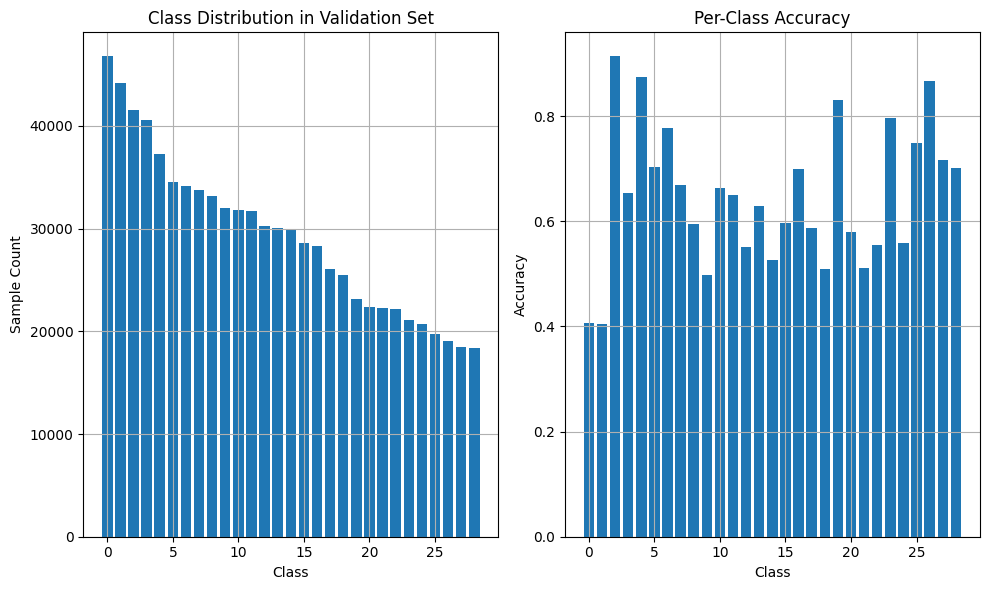

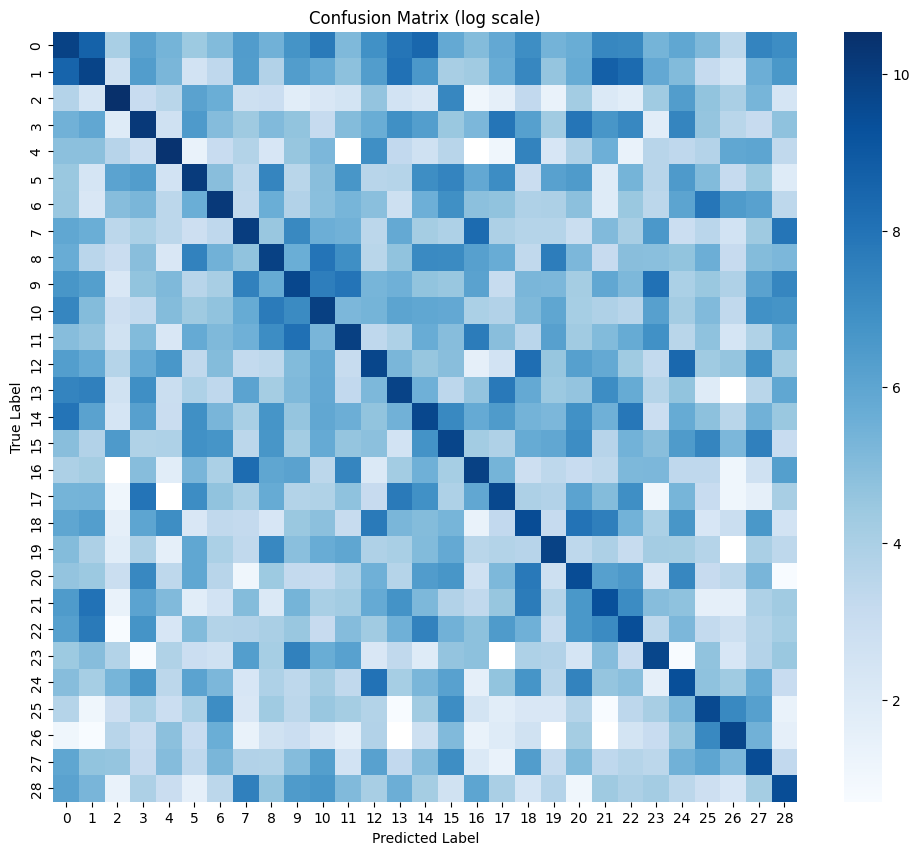

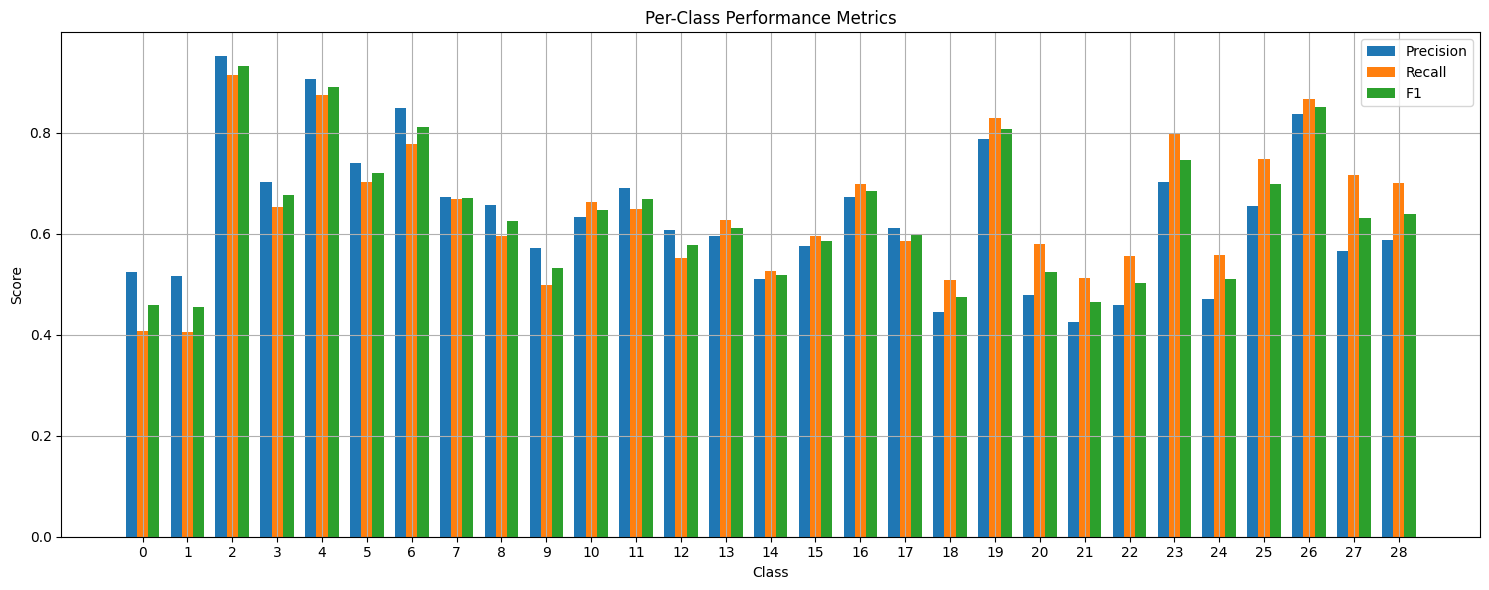

验证集全面评估报告已保存至: ./Results/BrainVoxel_30Class/BrainVoxel_Subset/validation_complete_report_multiclass.txt


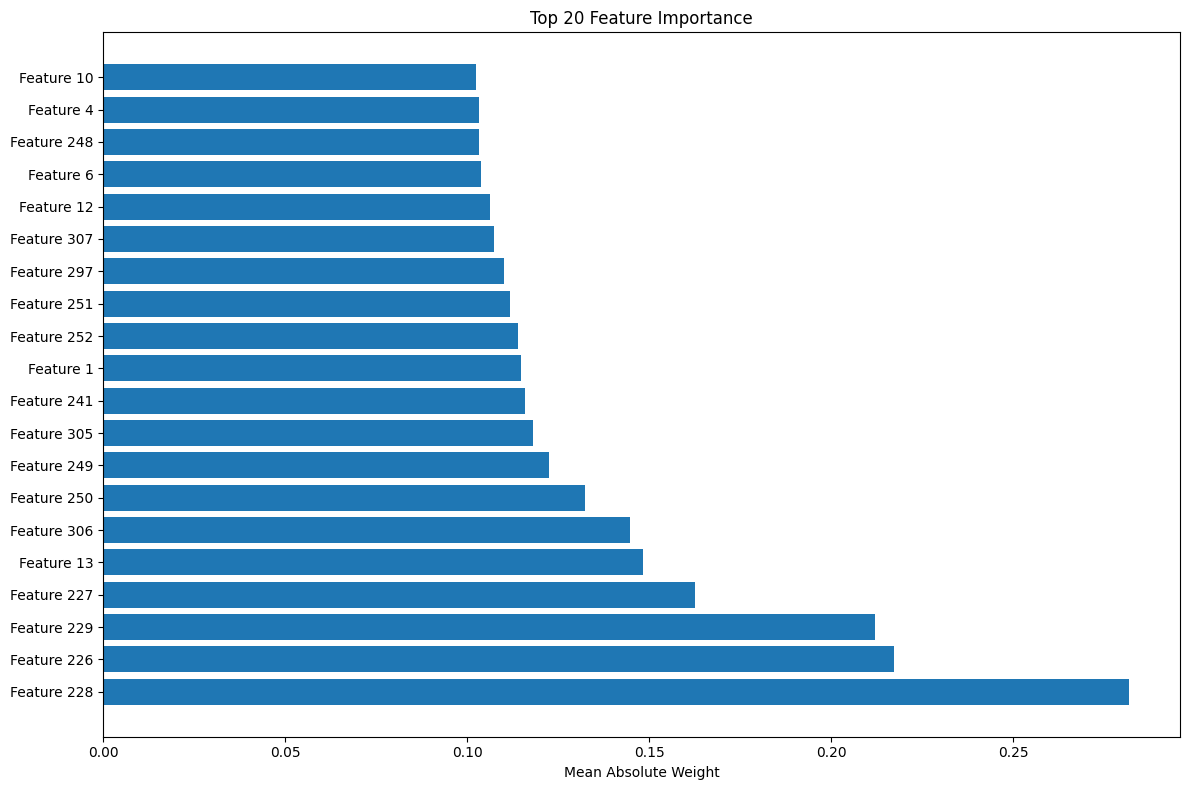

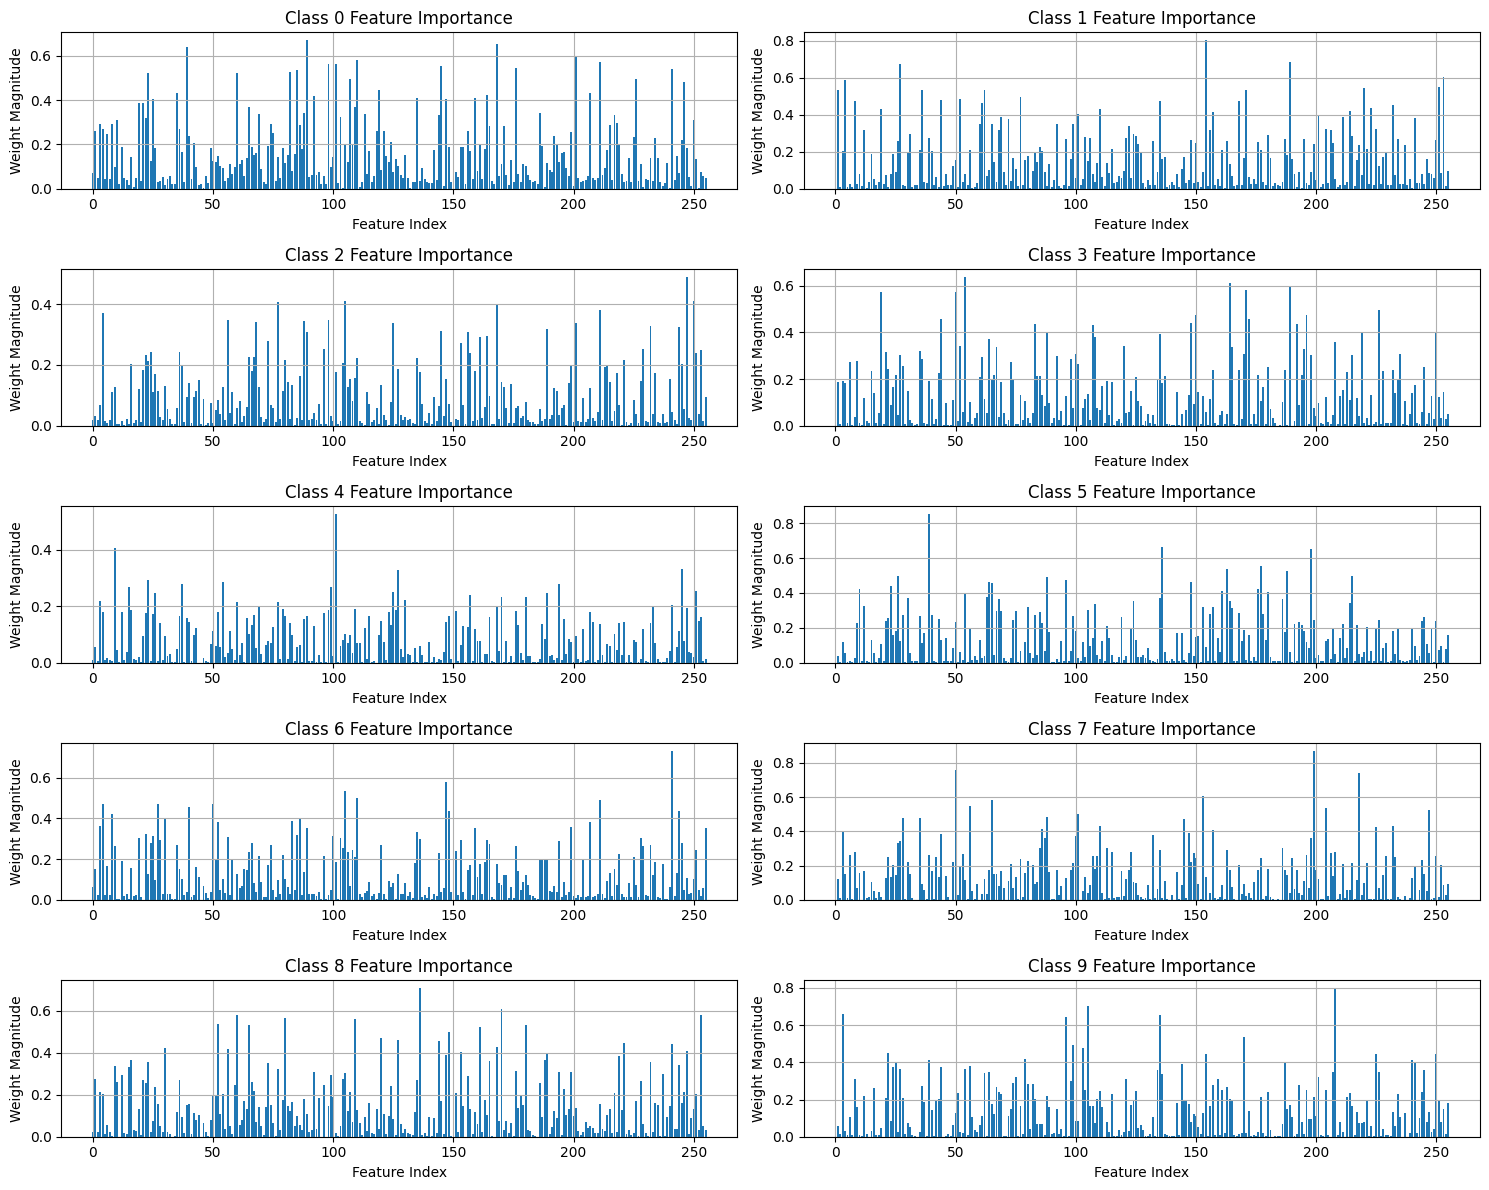

每个类别的特征重要性分析已完成并保存


In [29]:
# 在验证集上进行全面评估
print("在验证集上进行全面评估...")
model.eval()
all_preds = []
all_probs_all = []  # 存储所有类别的概率
all_targets = []

# 使用val_loader直接评估
with torch.no_grad():
    for data, target in tqdm(val_loader, desc="验证集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        all_preds.extend(preds[valid_mask].cpu().numpy())
        all_probs_all.extend(probs[valid_mask].cpu().numpy())
        all_targets.extend(target[valid_mask].cpu().numpy())

# 转换为numpy数组
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs_all = np.array(all_probs_all)

# 计算各种评估指标
accuracy = accuracy_score(all_targets, all_preds)
balanced_acc = balanced_accuracy_score(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average='macro')
f1_weighted = f1_score(all_targets, all_preds, average='weighted')
kappa = cohen_kappa_score(all_targets, all_preds)

report = classification_report(all_targets, all_preds)
conf_matrix = confusion_matrix(all_targets, all_preds)

# 打印主要评估指标
print(f"验证集准确率: {accuracy:.4f}")
print(f"验证集平衡准确率: {balanced_acc:.4f}")
print(f"验证集宏平均F1: {f1_macro:.4f}")
print(f"验证集加权F1: {f1_weighted:.4f}")
print(f"验证集Kappa系数: {kappa:.4f}")

print("\n分类报告:")
print(report)
print("\n混淆矩阵:")
print(conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(all_targets.astype(int))
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Validation Set')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(all_targets):
        mask = all_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(all_preds[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'validation_set_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(conf_matrix)  # log(1+x)以处理零值
mask = conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'validation_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
valid_classes = np.unique(all_targets).astype(int)
class_precision = precision_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)
class_recall = recall_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)
class_f1 = f1_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)
val_class_f1 = class_f1.copy()  # 保存验证集的class_f1结果

# 可视化类别性能
plt.figure(figsize=(15, 6))
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision, width, label='Precision')
plt.bar(x, class_recall, width, label='Recall')
plt.bar(x + width, class_f1, width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'validation_set_class_performance.png'))
plt.show()

# 保存验证集评估报告
validation_report_complete = f"""
# 验证集多分类全面评估报告

## 性能指标
- 准确率: {accuracy:.4f}
- 平衡准确率: {balanced_acc:.4f}
- 宏平均F1: {f1_macro:.4f}
- 加权F1: {f1_weighted:.4f}
- Kappa系数: {kappa:.4f}

## 样本分布
- 总样本数: {len(all_targets)}
- 类别数量: {len(valid_classes)}
"""

# 添加各类别的样本数
validation_report_complete += """
## 类别分布

| 类别 | 样本数 | 所占比例 |
|------|--------|----------|
"""

for cls in valid_classes:
    count = np.sum(all_targets == cls)
    percentage = count / len(all_targets) * 100
    validation_report_complete += f"| {cls} | {count} | {percentage:.2f}% |\n"

# 添加类别性能表格
validation_report_complete += """
## 类别性能分析

| 类别 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|
"""

for i, cls in enumerate(valid_classes):
    validation_report_complete += f"| {cls} | {class_precision[i]:.4f} | {class_recall[i]:.4f} | {class_f1[i]:.4f} |\n"

# 添加分类报告
validation_report_complete += f"""
## 详细分类报告
{report}

## 性能分析
- 表现最好的类别: {valid_classes[np.argmax(class_f1)]} (F1分数: {np.max(class_f1):.4f})
- 表现最差的类别: {valid_classes[np.argmin(class_f1)]} (F1分数: {np.min(class_f1):.4f})
- 类别间性能差异: {np.max(class_f1) - np.min(class_f1):.4f}
"""

with open(os.path.join(SAVE_PATH, 'validation_complete_report_multiclass.txt'), 'w') as f:
    f.write(validation_report_complete)

print(f"验证集全面评估报告已保存至: {os.path.join(SAVE_PATH, 'validation_complete_report_multiclass.txt')}")

# 特征重要性分析
feature_importance = analyze_kan_model(
    best_model,
    dataset_dict['val_samples'],
    os.path.join(SAVE_PATH, 'feature_importance_validation_multiclass.png'),
    apply_pca_flag=APPLY_PCA 
)

# 保存特征重要性数据
np.save(os.path.join(SAVE_PATH, 'feature_importance_validation_multiclass.npy'), feature_importance)

# 分析每个类别的特征重要性（如果可能）
if hasattr(model, 'kan') and hasattr(model.kan, 'layers'):
    try:
        # 尝试获取最后一层权重
        final_layer_weights = model.kan.layers[-1].base_linear.weight.data.cpu().numpy()
        
        # 可视化前10个类别的特征重要性
        plt.figure(figsize=(15, 12))
        num_classes_to_show = min(10, final_layer_weights.shape[0])
        
        for i in range(num_classes_to_show):
            plt.subplot(5, 2, i+1)
            class_weights = np.abs(final_layer_weights[i])
            plt.bar(range(len(class_weights)), class_weights)
            plt.title(f'Class {i} Feature Importance')
            plt.xlabel('Feature Index')
            plt.ylabel('Weight Magnitude')
            plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_PATH, 'class_specific_feature_importance.png'))
        plt.show()
        
        print("每个类别的特征重要性分析已完成并保存")
    except Exception as e:
        print(f"无法分析每个类别的特征重要性: {e}")

在merged全数据集上进行评估...
找到 101 个有效标签


加载merged数据集:   0%|          | 0/101 [00:00<?, ?it/s]

merged数据集评估:   0%|          | 0/26545 [00:00<?, ?it/s]

/opt/conda/envs/kan_1d/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/kan_1d/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/kan_1d/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


merged数据集准确率: 0.0032
merged数据集平衡准确率: 0.0116
merged数据集宏平均F1: 0.0017
merged数据集加权F1: 0.0011
merged数据集Kappa系数: -0.0030

分类报告:
              precision    recall  f1-score   support

           0       0.00      0.01      0.00     16143
           1       0.00      0.00      0.00     16483
           2       0.00      0.00      0.00    186213
           3       0.00      0.01      0.00    170589
           4       0.00      0.00      0.00     68810
           5       0.01      0.01      0.01    115903
           6       0.01      0.03      0.01     45423
           7       0.00      0.00      0.00     17788
           8       0.00      0.00      0.00      4902
           9       0.00      0.00      0.00     95124
          10       0.01      0.03      0.01     92263
          11       0.00      0.00      0.00     37210
          12       0.00      0.01      0.00     28341
          13       0.00      0.00      0.00     14030
          14       0.00      0.00      0.00      9441
          15 

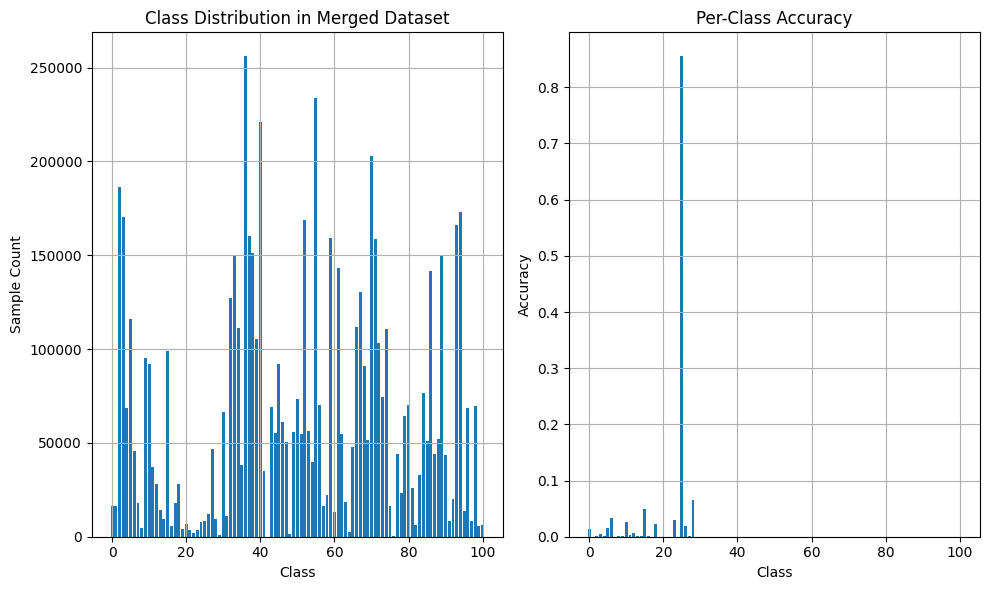

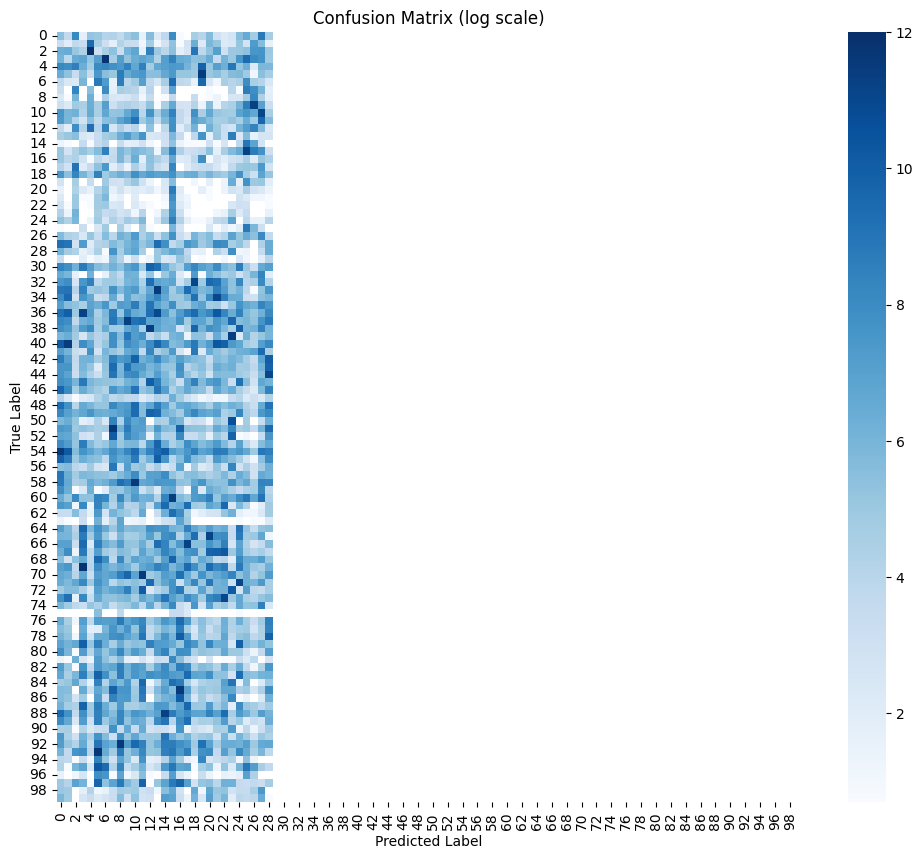

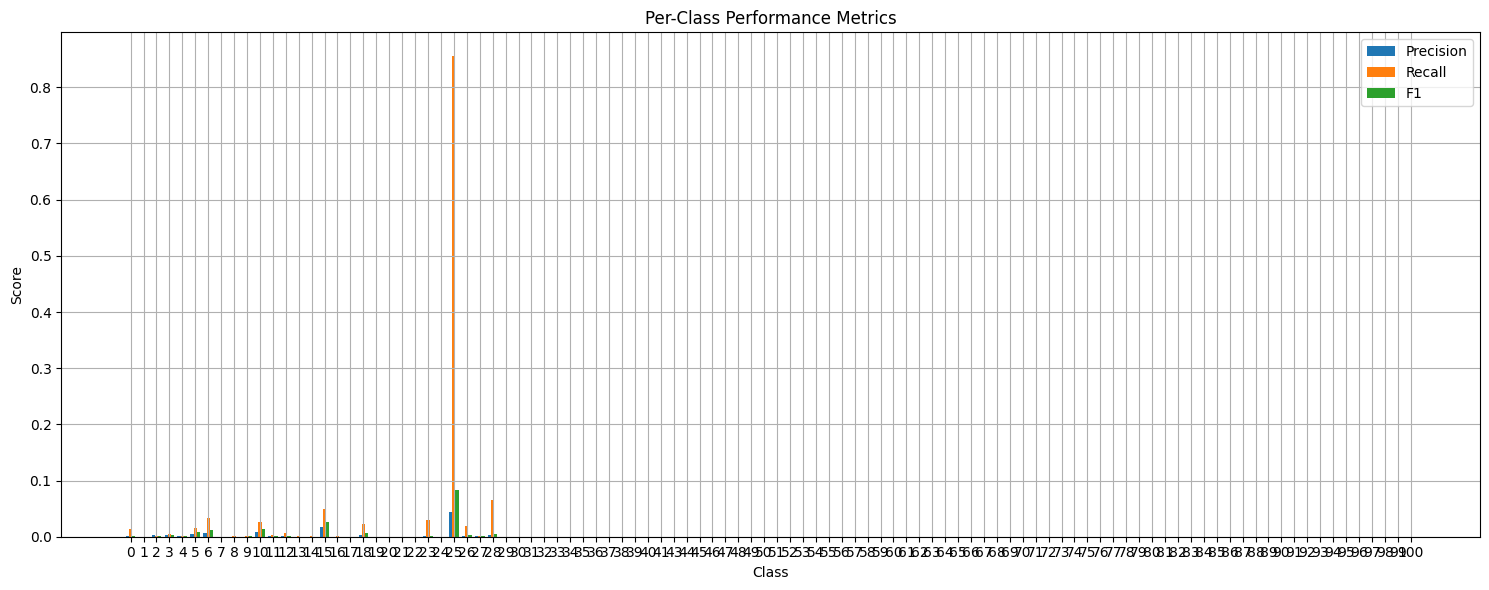

表现最好的类别: 25, F1分数: 0.0837
表现最差的类别: 19, F1分数: 0.0000
Merged数据集评估报告已保存至: ./Results/BrainVoxel_30Class/BrainVoxel_Subset/merged_dataset_complete_report_multiclass.txt


In [30]:
# 在merged全数据集上进行评估
print("在merged全数据集上进行评估...")

# 定义merged数据文件夹
merged_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/merged"

# 创建一个用于merged数据的采样器
merged_sampler = BrainVoxelSampler(merged_dir)

# 加载所有的标签数据
all_samples = []
all_labels = []

# 获取所有有效标签
valid_labels = merged_sampler.valid_labels
print(f"找到 {len(valid_labels)} 个有效标签")

# 加载每个标签的数据
for label_id in tqdm(valid_labels, desc="加载merged数据集"):
    file_path = merged_sampler.get_file_path(label_id)
    if file_path:
        samples = np.load(file_path)
        labels = np.ones(len(samples)) * label_id  # 使用实际标签ID
        all_samples.append(samples)
        all_labels.append(labels)

# 合并所有样本
all_samples = np.vstack(all_samples)
all_labels = np.concatenate(all_labels)

# 应用PCA（如果需要）
if APPLY_PCA and pca_model is not None:
    # 使用已训练的PCA模型
    print(f"使用训练好的PCA模型转换merged数据...")
    all_samples = pca_model.transform(all_samples)
    if NORM:
        # 应用标准化
        all_samples = (all_samples - np.min(all_samples, axis=0)) / (np.max(all_samples, axis=0) - np.min(all_samples, axis=0) + 1e-10)

# 创建数据集和加载器
merged_dataset = BrainVoxelDataset(all_samples, all_labels)
merged_loader = DataLoader(merged_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 模型评估
model.eval()
merged_preds = []
merged_probs_all = []  # 所有类别的概率
merged_targets = []

with torch.no_grad():
    for data, target in tqdm(merged_loader, desc="merged数据集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        merged_preds.extend(preds[valid_mask].cpu().numpy())
        merged_probs_all.extend(probs[valid_mask].cpu().numpy())
        merged_targets.extend(target[valid_mask].cpu().numpy())

# 转换为numpy数组
merged_preds = np.array(merged_preds)
merged_targets = np.array(merged_targets)
merged_probs_all = np.array(merged_probs_all)

# 计算评估指标
merged_accuracy = accuracy_score(merged_targets, merged_preds)
merged_balanced_acc = balanced_accuracy_score(merged_targets, merged_preds)
merged_f1_macro = f1_score(merged_targets, merged_preds, average='macro')
merged_f1_weighted = f1_score(merged_targets, merged_preds, average='weighted')
merged_kappa = cohen_kappa_score(merged_targets, merged_preds)

# 生成分类报告
merged_report = classification_report(merged_targets, merged_preds)
merged_conf_matrix = confusion_matrix(merged_targets, merged_preds)

# 打印评估结果
print(f"merged数据集准确率: {merged_accuracy:.4f}")
print(f"merged数据集平衡准确率: {merged_balanced_acc:.4f}")
print(f"merged数据集宏平均F1: {merged_f1_macro:.4f}")
print(f"merged数据集加权F1: {merged_f1_weighted:.4f}")
print(f"merged数据集Kappa系数: {merged_kappa:.4f}")

print("\n分类报告:")
print(merged_report)
print("\n混淆矩阵:")
print(merged_conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(merged_targets.astype(int))
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Merged Dataset')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(merged_targets):
        mask = merged_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(merged_preds[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'merged_dataset_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(merged_conf_matrix)  # log(1+x)以处理零值
mask = merged_conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'merged_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
valid_classes = np.unique(merged_targets).astype(int)
class_precision = precision_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)
class_recall = recall_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)
class_f1 = f1_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)
merged_class_f1 = class_f1.copy()  
# 可视化类别性能
plt.figure(figsize=(15, 6))
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision, width, label='Precision')
plt.bar(x, class_recall, width, label='Recall')
plt.bar(x + width, class_f1, width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'merged_dataset_class_performance.png'))
plt.show()

# 找出表现最好和最差的类别
best_class = valid_classes[np.argmax(class_f1)]
worst_class = valid_classes[np.argmin(class_f1)]
best_f1 = np.max(class_f1)
worst_f1 = np.min(class_f1)

print(f"表现最好的类别: {best_class}, F1分数: {best_f1:.4f}")
print(f"表现最差的类别: {worst_class}, F1分数: {worst_f1:.4f}")

# 保存评估报告
merged_report_complete = f"""
# Merged数据集多分类全面评估报告

## 性能指标
- 准确率: {merged_accuracy:.4f}
- 平衡准确率: {merged_balanced_acc:.4f}
- 宏平均F1: {merged_f1_macro:.4f}
- 加权F1: {merged_f1_weighted:.4f}
- Kappa系数: {merged_kappa:.4f}

## 样本分布
- 总样本数: {len(merged_targets)}
- 类别数量: {len(valid_classes)}
- 样本最多的类别: {np.argmax(class_counts)} ({np.max(class_counts)} 个样本)
- 样本最少的类别: {np.argmin(class_counts[class_counts > 0])} ({np.min(class_counts[class_counts > 0])} 个样本)
"""

# 添加各类别的样本数
merged_report_complete += """
## 类别分布

| 类别 | 样本数 | 所占比例 | 准确率 |
|------|--------|----------|--------|
"""

for cls in valid_classes:
    count = np.sum(merged_targets == cls)
    percentage = count / len(merged_targets) * 100
    idx = np.where(valid_classes == cls)[0][0]
    acc = class_accuracy[cls] if cls < len(class_accuracy) else 0
    merged_report_complete += f"| {cls} | {count} | {percentage:.2f}% | {acc:.4f} |\n"

# 添加类别性能表格
merged_report_complete += """
## 类别性能分析

| 类别 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|
"""

for i, cls in enumerate(valid_classes):
    merged_report_complete += f"| {cls} | {class_precision[i]:.4f} | {class_recall[i]:.4f} | {class_f1[i]:.4f} |\n"

merged_report_complete += f"""
## 详细分类报告
{merged_report}

## 性能分析
- 表现最好的类别: {best_class} (F1分数: {best_f1:.4f})
- 表现最差的类别: {worst_class} (F1分数: {worst_f1:.4f})
- 类别间性能差异: {best_f1 - worst_f1:.4f}
"""

with open(os.path.join(SAVE_PATH, 'merged_dataset_complete_report_multiclass.txt'), 'w') as f:
    f.write(merged_report_complete)

print(f"Merged数据集评估报告已保存至: {os.path.join(SAVE_PATH, 'merged_dataset_complete_report_multiclass.txt')}")

评估中:   0%|          | 0/1172 [00:00<?, ?it/s]

评估中:   0%|          | 0/3512 [00:00<?, ?it/s]

/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_757489/3924428829.py:86: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) D

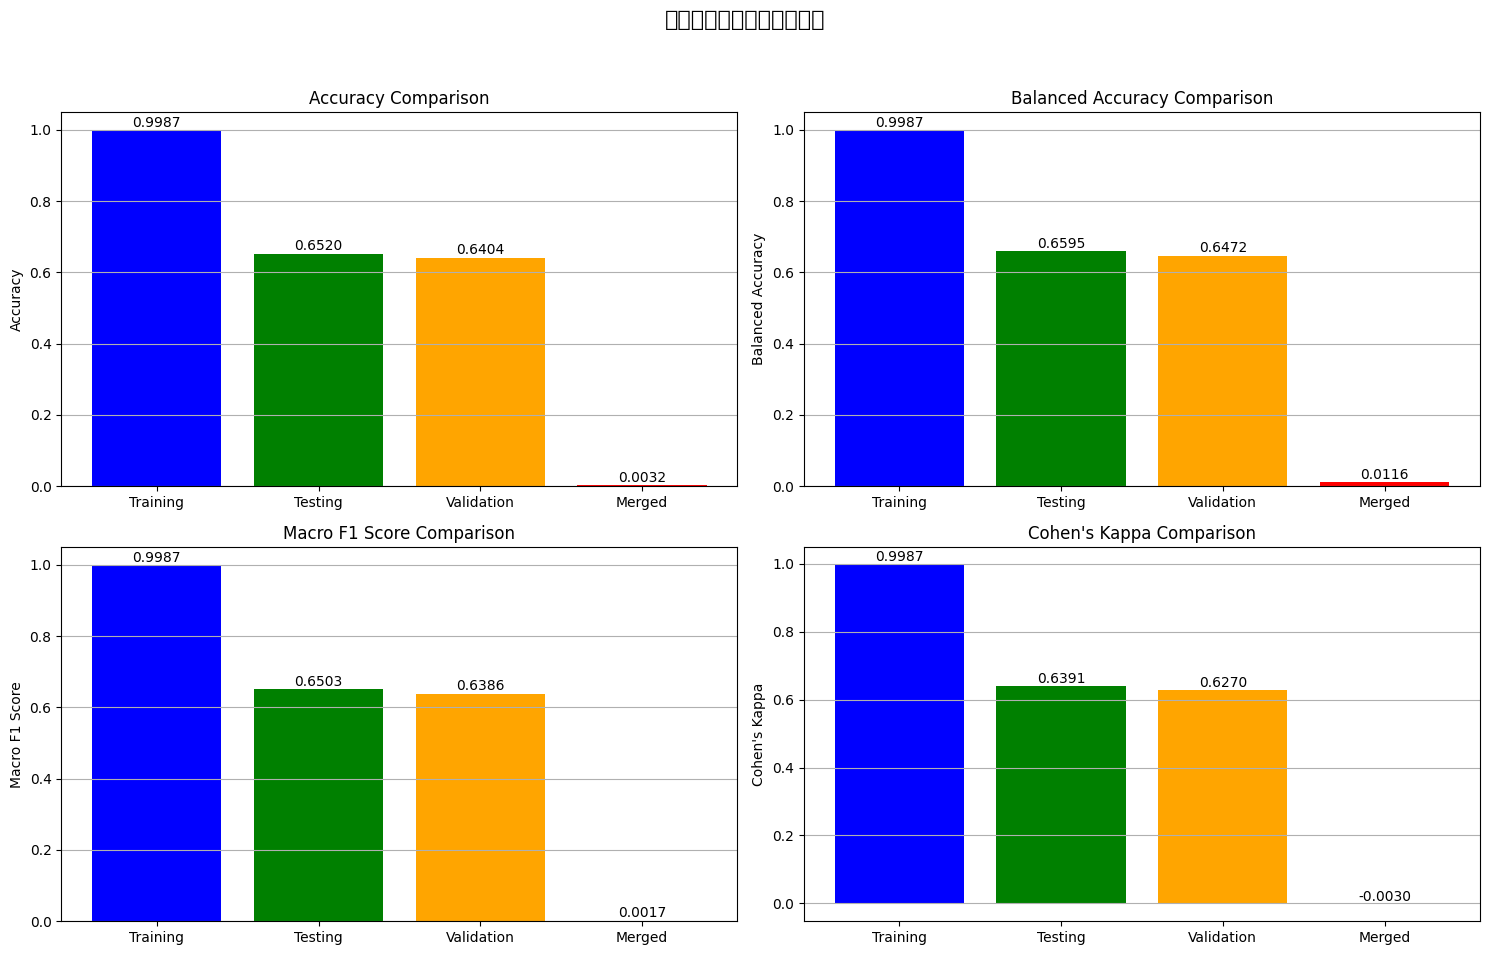

/tmp/ipykernel_757489/3924428829.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  | Merged    | {len(merged_results['targets'])} | {len(np.unique(merged_results['targets']))} | {np.max(np.bincount(merged_results['targets']))} | {np.min(np.bincount(merged_results['targets'] + 1)[1:])} | {np.max(np.bincount(merged_results['targets']))/np.min(np.bincount(merged_results['targets'] + 1)[1:]):.2f} |


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 30 and the array at index 1 has size 29

In [31]:
# 绘制四个数据集的多分类性能对比
train_results = evaluate_model_multiclass(best_model, train_loader, device)
test_results = evaluate_model_multiclass(best_model, test_loader, device)

# 使用之前验证集计算的结果创建结构一致的字典
val_results = {
    'accuracy': accuracy, 
    'balanced_accuracy': balanced_acc,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'kappa': kappa,
    'targets': all_targets,
    'class_f1': val_class_f1
}

# 使用之前merged数据集计算的结果创建结构一致的字典
merged_results = {
    'accuracy': merged_accuracy, 
    'balanced_accuracy': merged_balanced_acc,
    'f1_macro': merged_f1_macro,
    'f1_weighted': merged_f1_weighted,
    'kappa': merged_kappa,
    'targets': merged_targets,
    'class_f1': merged_class_f1  # 注意：这里应使用merged数据集的class_f1
}

plt.figure(figsize=(15, 10))
plt.suptitle(f"不同数据集多分类性能对比", fontsize=16)

# 准确率对比
plt.subplot(2, 2, 1)
datasets = ['Training', 'Testing', 'Validation', 'Merged']
accuracies = [train_results['accuracy'], test_results['accuracy'], val_results['accuracy'], merged_results['accuracy']]
plt.bar(datasets, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.grid(axis='y')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# 平衡准确率对比
plt.subplot(2, 2, 2)
balanced_accs = [
    train_results['balanced_accuracy'], 
    test_results['balanced_accuracy'], 
    val_results['balanced_accuracy'],
    merged_results['balanced_accuracy']
]
plt.bar(datasets, balanced_accs, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Balanced Accuracy')
plt.title('Balanced Accuracy Comparison')
plt.grid(axis='y')
for i, v in enumerate(balanced_accs):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# F1宏平均对比
plt.subplot(2, 2, 3)
f1_macros = [
    train_results['f1_macro'], 
    test_results['f1_macro'], 
    val_results['f1_macro'],
    merged_results['f1_macro']
]
plt.bar(datasets, f1_macros, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Macro F1 Score')
plt.title('Macro F1 Score Comparison')
plt.grid(axis='y')
for i, v in enumerate(f1_macros):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# Kappa系数对比
plt.subplot(2, 2, 4)
kappas = [
    train_results['kappa'],
    test_results['kappa'],
    val_results['kappa'],
    merged_results['kappa']
]
plt.bar(datasets, kappas, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Cohen\'s Kappa')
plt.title('Cohen\'s Kappa Comparison')
plt.grid(axis='y')
for i, v in enumerate(kappas):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(SAVE_PATH, 'multi_dataset_comparison.png'))
plt.show()

# 创建一个汇总的多分类比较报告
comparison_report = f"""
# 多分类性能对比报告 (102类)

## 性能指标汇总

| 指标                | 训练集     | 测试集     | 验证集     | Merged数据集 |
|---------------------|------------|------------|------------|--------------|
| 准确率              | {train_results['accuracy']:.4f} | {test_results['accuracy']:.4f} | {val_results['accuracy']:.4f} | {merged_results['accuracy']:.4f} |
| 平衡准确率          | {train_results['balanced_accuracy']:.4f} | {test_results['balanced_accuracy']:.4f} | {val_results['balanced_accuracy']:.4f} | {merged_results['balanced_accuracy']:.4f} |
| 宏平均F1分数        | {train_results['f1_macro']:.4f} | {test_results['f1_macro']:.4f} | {val_results['f1_macro']:.4f} | {merged_results['f1_macro']:.4f} |
| 加权F1分数          | {train_results['f1_weighted']:.4f} | {test_results['f1_weighted']:.4f} | {val_results['f1_weighted']:.4f} | {merged_results['f1_weighted']:.4f} |
| Cohen's Kappa系数   | {train_results['kappa']:.4f} | {test_results['kappa']:.4f} | {val_results['kappa']:.4f} | {merged_results['kappa']:.4f} |

## 样本分布

| 集合      | 总样本数  | 类别数 | 最大类样本数 | 最小类样本数 | 最大/最小比例 |
|-----------|-----------|--------|--------------|--------------|--------------|
| 训练集    | {len(train_results['targets'])} | {len(np.unique(train_results['targets']))} | {np.max(np.bincount(train_results['targets']))} | {np.min(np.bincount(train_results['targets'] + 1)[1:])} | {np.max(np.bincount(train_results['targets']))/np.min(np.bincount(train_results['targets'] + 1)[1:]):.2f} |
| 测试集    | {len(test_results['targets'])} | {len(np.unique(test_results['targets']))} | {np.max(np.bincount(test_results['targets']))} | {np.min(np.bincount(test_results['targets'] + 1)[1:])} | {np.max(np.bincount(test_results['targets']))/np.min(np.bincount(test_results['targets'] + 1)[1:]):.2f} |
| 验证集    | {len(val_results['targets'])} | {len(np.unique(val_results['targets']))} | {np.max(np.bincount(val_results['targets']))} | {np.min(np.bincount(val_results['targets'] + 1)[1:])} | {np.max(np.bincount(val_results['targets']))/np.min(np.bincount(val_results['targets'] + 1)[1:]):.2f} |
| Merged    | {len(merged_results['targets'])} | {len(np.unique(merged_results['targets']))} | {np.max(np.bincount(merged_results['targets']))} | {np.min(np.bincount(merged_results['targets'] + 1)[1:])} | {np.max(np.bincount(merged_results['targets']))/np.min(np.bincount(merged_results['targets'] + 1)[1:]):.2f} |

## 类别性能分析

### 表现最好的5个类别 (按F1分数)
"""

# 添加表现最好的5个类别的信息
best_classes = np.argsort(test_results['class_f1'])[-5:][::-1]
comparison_report += """
| 类别ID | 训练集F1 | 测试集F1 | 验证集F1 | 样本数量 |
|--------|----------|----------|----------|----------|
"""
for class_id in best_classes:
    train_f1 = train_results['class_f1'][class_id]
    test_f1 = test_results['class_f1'][class_id]
    val_f1 = val_results['class_f1'][class_id]
    sample_count = np.sum(train_results['targets'] == class_id) + np.sum(test_results['targets'] == class_id) + np.sum(val_results['targets'] == class_id)
    comparison_report += f"| {class_id} | {train_f1:.4f} | {test_f1:.4f} | {val_f1:.4f} | {sample_count} |\n"

comparison_report += """
### 表现最差的5个类别 (按F1分数)
"""

# 添加表现最差的5个类别的信息
worst_classes = np.argsort(test_results['class_f1'])[:5]
comparison_report += """
| 类别ID | 训练集F1 | 测试集F1 | 验证集F1 | 样本数量 |
|--------|----------|----------|----------|----------|
"""
for class_id in worst_classes:
    train_f1 = train_results['class_f1'][class_id]
    test_f1 = test_results['class_f1'][class_id]
    val_f1 = val_results['class_f1'][class_id]
    sample_count = np.sum(train_results['targets'] == class_id) + np.sum(test_results['targets'] == class_id) + np.sum(val_results['targets'] == class_id)
    comparison_report += f"| {class_id} | {train_f1:.4f} | {test_f1:.4f} | {val_f1:.4f} | {sample_count} |\n"

comparison_report += """
## 性能差异分析

| 比较          | 准确率差异 | 平衡准确率差异 | 宏平均F1差异 | Kappa差异 |
|---------------|------------|----------------|--------------|-----------|
"""
comparison_report += f"| 训练集vs测试集 | {train_results['accuracy']-test_results['accuracy']:.4f} | {train_results['balanced_accuracy']-test_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-test_results['f1_macro']:.4f} | {train_results['kappa']-test_results['kappa']:.4f} |\n"
comparison_report += f"| 训练集vs验证集 | {train_results['accuracy']-val_results['accuracy']:.4f} | {train_results['balanced_accuracy']-val_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-val_results['f1_macro']:.4f} | {train_results['kappa']-val_results['kappa']:.4f} |\n"
comparison_report += f"| 训练集vsMerged | {train_results['accuracy']-merged_results['accuracy']:.4f} | {train_results['balanced_accuracy']-merged_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-merged_results['f1_macro']:.4f} | {train_results['kappa']-merged_results['kappa']:.4f} |\n"
comparison_report += f"| 测试集vs验证集 | {test_results['accuracy']-val_results['accuracy']:.4f} | {test_results['balanced_accuracy']-val_results['balanced_accuracy']:.4f} | {test_results['f1_macro']-val_results['f1_macro']:.4f} | {test_results['kappa']-val_results['kappa']:.4f} |\n"

comparison_report += """
## 分析结论

### 总体性能
"""
comparison_report += f"- 训练集性能: 准确率 {train_results['accuracy']:.4f}, 平衡准确率 {train_results['balanced_accuracy']:.4f}, 宏平均F1 {train_results['f1_macro']:.4f}\n"
comparison_report += f"- 测试集性能: 准确率 {test_results['accuracy']:.4f}, 平衡准确率 {test_results['balanced_accuracy']:.4f}, 宏平均F1 {test_results['f1_macro']:.4f}\n"
comparison_report += f"- 验证集性能: 准确率 {val_results['accuracy']:.4f}, 平衡准确率 {val_results['balanced_accuracy']:.4f}, 宏平均F1 {val_results['f1_macro']:.4f}\n"
comparison_report += f"- Merged集性能: 准确率 {merged_results['accuracy']:.4f}, 平衡准确率 {merged_results['balanced_accuracy']:.4f}, 宏平均F1 {merged_results['f1_macro']:.4f}\n"

comparison_report += """
### 泛化能力评估
"""
comparison_report += f"- 训练集与验证集的性能差异: {abs(train_results['accuracy']-val_results['accuracy']):.4f} (准确率), {abs(train_results['f1_macro']-val_results['f1_macro']):.4f} (宏平均F1)\n"
comparison_report += f"- 训练集与测试集的性能差异: {abs(train_results['accuracy']-test_results['accuracy']):.4f} (准确率), {abs(train_results['f1_macro']-test_results['f1_macro']):.4f} (宏平均F1)\n"
comparison_report += f"- 验证集与测试集的性能差异: {abs(val_results['accuracy']-test_results['accuracy']):.4f} (准确率), {abs(val_results['f1_macro']-test_results['f1_macro']):.4f} (宏平均F1)\n"

comparison_report += """
### 数据集划分评估
"""
consistency = "高" if abs(train_results['accuracy']-test_results['accuracy']) < 0.05 and abs(train_results['accuracy']-val_results['accuracy']) < 0.05 else "中等" if abs(train_results['accuracy']-test_results['accuracy']) < 0.1 and abs(train_results['accuracy']-val_results['accuracy']) < 0.1 else "低"
comparison_report += f"- 训练/测试/验证集的性能一致性: {consistency}\n"
comparison_report += f"- 各数据集类别分布: 训练集({len(np.unique(train_results['targets']))}类), 测试集({len(np.unique(test_results['targets']))}类), 验证集({len(np.unique(val_results['targets']))}类)\n"

# 补充评估类别不平衡的影响
comparison_report += """
### 类别不平衡影响分析
"""
# 计算类别样本数与性能的相关性
train_class_counts = []
for i in range(NUM_CLASS):
    train_class_counts.append(np.sum(train_results['targets'] == i))
train_class_counts = np.array(train_class_counts)

correlation = np.corrcoef(train_class_counts, test_results['class_f1'])[0, 1]
comparison_report += f"- 类别样本数量与测试集F1分数的相关系数: {correlation:.4f}\n"

# 分析小样本类别的表现
small_sample_classes = []
for i in range(NUM_CLASS):
    if train_class_counts[i] < 10:  # 定义小样本类别为小于10个样本
        small_sample_classes.append(i)

if small_sample_classes:
    comparison_report += f"- 样本数少于10的类别有{len(small_sample_classes)}个，平均F1分数: {np.mean(test_results['class_f1'][small_sample_classes]):.4f}\n"
    comparison_report += f"- 其余类别的平均F1分数: {np.mean(test_results['class_f1'][~np.isin(np.arange(NUM_CLASS), small_sample_classes)]):.4f}\n"

# 保存报告
with open(os.path.join(SAVE_PATH, 'multi_dataset_comparison_report.txt'), 'w') as f:
    f.write(comparison_report)

print(f"多分类数据集比较报告已保存至: {os.path.join(SAVE_PATH, 'multi_dataset_comparison_report.txt')}")